<a href="https://colab.research.google.com/github/suchismita543/Cache-22/blob/ai-ml-price-prediction/SIH_Agri_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("SIH Agricultural Price Prediction - AI/ML")

SIH Agricultural Price Prediction - AI/ML


In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = next(
    name for name in uploaded
    if name.lower().endswith(".zip")
)

with zipfile.ZipFile(zip_file, "r") as z:
    z.extractall("historical_mandi_data")

print("Extracted files:")
for root, dirs, files_list in os.walk("historical_mandi_data"):
    for file in files_list:
        print(os.path.join(root, file))

Saving archive (1).zip to archive (1).zip
Extracted files:
historical_mandi_data/Agriculture_price_dataset.csv


In [ ]:
import pandas as pd

file_path = "historical_mandi_data/Agriculture_price_dataset.csv"

historical_df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", historical_df.shape)

print("\nColumns:")
print(historical_df.columns.tolist())

print("\nFirst 5 rows:")
display(historical_df.head())

Dataset loaded successfully!
Shape: (737392, 10)

Columns:
['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Price Date']

First 5 rows:


,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/6/2023


In [ ]:
# ==========================================
# SESSION 1 — PART 2: RAW DATA VERIFICATION
# ==========================================

print("========== DATASET SIZE ==========")
print("Rows:", historical_df.shape[0])
print("Columns:", historical_df.shape[1])

print("\n========== DATA TYPES ==========")
print(historical_df.dtypes)

print("\n========== MISSING VALUES ==========")
print(historical_df.isnull().sum())

print("\n========== DUPLICATE ROWS ==========")
print("Duplicates:", historical_df.duplicated().sum())

print("\n========== RAW DATE INFORMATION ==========")
print("Date column type:", historical_df["Price Date"].dtype)

print("First raw date:", historical_df["Price Date"].iloc[0])
print("Last raw date:", historical_df["Price Date"].iloc[-1])

print("Number of unique raw dates:",
      historical_df["Price Date"].nunique())

========== DATASET SIZE ==========
Rows: 737392
Columns: 10

========== DATA TYPES ==========
STATE             object
District Name     object
Market Name       object
Commodity         object
Variety           object
Grade             object
Min_Price        float64
Max_Price        float64
Modal_Price      float64
Price Date        object
dtype: object

========== MISSING VALUES ==========
STATE            0
District Name    0
Market Name      0
Commodity        0
Variety          0
Grade            0
Min_Price        0
Max_Price        0
Modal_Price      0
Price Date       0
dtype: int64

========== DUPLICATE ROWS ==========
Duplicates: 0

========== RAW DATE INFORMATION ==========
Date column type: object
First raw date: 6/6/2023
Last raw date: 6/11/2025
Number of unique raw dates: 737


In [ ]:
# ==========================================
# SESSION 1 — PART 3: DATE CONVERSION
# ==========================================

historical_df["Price Date"] = pd.to_datetime(
    historical_df["Price Date"],
    format="%m/%d/%Y",
    errors="coerce"
)

print("Date data type:")
print(historical_df["Price Date"].dtype)

print("\nMissing dates after conversion:")
print(historical_df["Price Date"].isna().sum())

print("\nActual date range:")
print("First date:", historical_df["Price Date"].min())
print("Last date:", historical_df["Price Date"].max())

print("\nNumber of unique dates:")
print(historical_df["Price Date"].nunique())

Date data type:
datetime64[ns]

Missing dates after conversion:
0

Actual date range:
First date: 2023-06-06 00:00:00
Last date: 2025-06-11 00:00:00

Number of unique dates:
737


In [ ]:
# ==========================================
# SESSION 1 — PART 4: RENAME COLUMNS
# ==========================================

historical_df = historical_df.rename(columns={
    "STATE": "state",
    "District Name": "district",
    "Market Name": "market",
    "Commodity": "commodity",
    "Variety": "variety",
    "Grade": "grade",
    "Min_Price": "min_price",
    "Max_Price": "max_price",
    "Modal_Price": "modal_price",
    "Price Date": "date"
})

print("Columns after renaming:")
print(historical_df.columns.tolist())

Columns after renaming:
['state', 'district', 'market', 'commodity', 'variety', 'grade', 'min_price', 'max_price', 'modal_price', 'date']


In [ ]:
# ==========================================
# SESSION 1 — PART 5: COMMODITY COVERAGE
# ==========================================

print("Total unique commodities:",
      historical_df["commodity"].nunique())

print("\nTop 30 commodities by number of records:")

commodity_counts = (
    historical_df["commodity"]
    .value_counts()
)

print(commodity_counts.head(30))

Total unique commodities: 5

Top 30 commodities by number of records:
commodity
Potato    327332
Onion     298658
Wheat      76976
Tomato     26644
Rice        7782
Name: count, dtype: int64


In [ ]:
# ==========================================
# PART 5B — COMMODITY DATA COVERAGE
# ==========================================

commodities_to_check = ["Potato", "Onion", "Tomato"]

for crop in commodities_to_check:
    crop_df = historical_df[
        historical_df["commodity"].str.strip().str.lower()
        == crop.lower()
    ]

    print("\n==============================")
    print(crop)
    print("==============================")

    print("Rows:", len(crop_df))
    print("Unique markets:", crop_df["market"].nunique())
    print("Unique states:", crop_df["state"].nunique())
    print("Unique varieties:", crop_df["variety"].nunique())
    print("Unique dates:", crop_df["date"].nunique())
    print("First date:", crop_df["date"].min())
    print("Last date:", crop_df["date"].max())


Potato
Rows: 327332
Unique markets: 971
Unique states: 28
Unique varieties: 20
Unique dates: 737
First date: 2023-06-06 00:00:00
Last date: 2025-06-11 00:00:00

Onion
Rows: 298658
Unique markets: 1044
Unique states: 29
Unique varieties: 23
Unique dates: 647
First date: 2023-06-06 00:00:00
Last date: 2025-06-11 00:00:00

Tomato
Rows: 26644
Unique markets: 660
Unique states: 24
Unique varieties: 5
Unique dates: 154
First date: 2023-06-06 00:00:00
Last date: 2023-11-06 00:00:00


In [ ]:
# ==========================================
# PART 6 — POTATO MARKET/SERIES COVERAGE
# ==========================================

potato_df = historical_df[
    historical_df["commodity"].str.strip().str.lower() == "potato"
].copy()

print("Potato rows:", len(potato_df))
print("Potato unique markets:", potato_df["market"].nunique())
print("Potato unique varieties:", potato_df["variety"].nunique())
print("Potato unique dates:", potato_df["date"].nunique())

print("\nTop 20 Potato markets:")
print(potato_df["market"].value_counts().head(20))

Potato rows: 327332
Potato unique markets: 971
Potato unique varieties: 20
Potato unique dates: 737

Top 20 Potato markets:
market
Ahmedabad(Chimanbhai Patal Market Vasana)    1592
Durgapur                                     1436
Pratapgarh                                   1376
Alipurduar                                   1178
Falakata                                     1114
Jalpaiguri Sadar                              911
Dhupguri                                      905
Bara Bazar (Posta Bazar)                      905
Belacoba                                      892
Khatra                                        865
Bishnupur(Bankura)                            862
Puwaha                                        856
Moynaguri                                     852
Asansol                                       844
Sultanpur                                     842
Noida                                         825
Sirsa                                         819
Muzzafarnagar      

In [ ]:
# ==========================================
# PART 6B — POTATO MARKET/VARIETY/GRADE
# ==========================================

potato_series = (
    potato_df
    .groupby(["market", "variety", "grade"])
    .agg(
        rows=("modal_price", "size"),
        unique_dates=("date", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max")
    )
    .reset_index()
)

potato_series["calendar_days"] = (
    potato_series["last_date"] -
    potato_series["first_date"]
).dt.days + 1

potato_series["coverage_ratio"] = (
    potato_series["unique_dates"] /
    potato_series["calendar_days"]
)

print("Total Potato market-variety-grade series:",
      len(potato_series))

print("\nTop 30 Potato series by unique dates:")
display(
    potato_series
    .sort_values(
        ["unique_dates", "coverage_ratio"],
        ascending=False
    )
    .head(30)
)

Total Potato market-variety-grade series: 1615

Top 30 Potato series by unique dates:


,market,variety,grade,rows,unique_dates,first_date,last_date,calendar_days,coverage_ratio
25,Ajuha,Desi,FAQ,728,728,2023-06-06,2025-06-11,737,0.987788
1318,Sambhal,Desi,FAQ,728,728,2023-06-06,2025-06-11,737,0.987788
1533,Tulsipur,Desi,FAQ,728,728,2023-06-06,2025-06-11,737,0.987788
1224,Puwaha,Desi,FAQ,727,727,2023-06-06,2025-06-11,737,0.986431
95,Asansol,Jyoti,FAQ,720,720,2023-06-06,2025-06-11,737,0.976934
459,Durgapur,Jyoti,FAQ,719,719,2023-06-06,2025-06-10,736,0.976902
1080,Nawabganj,Desi,FAQ,712,712,2023-06-06,2025-06-10,736,0.967391
180,Barasat,Other,FAQ,709,709,2023-06-06,2025-06-11,737,0.962008
914,Madhoganj,Badshah,FAQ,707,707,2023-06-06,2025-06-10,736,0.960598
564,Habra,Other,FAQ,706,706,2023-06-06,2025-06-11,737,0.957938


In [ ]:
# ==========================================
# PART 7 — VALIDATE SELECTED SERIES
# ==========================================

model_df = historical_df[
    (historical_df["commodity"].str.strip().str.lower() == "potato") &
    (historical_df["market"].str.strip().str.lower() == "ajuha") &
    (historical_df["variety"].str.strip().str.lower() == "desi") &
    (historical_df["grade"].str.strip().str.lower() == "faq")
].copy()

model_df = model_df.sort_values("date").reset_index(drop=True)

print("Shape:", model_df.shape)

print("\nFirst 5 rows:")
display(model_df.head())

print("\nLast 5 rows:")
display(model_df.tail())

print("\nDate range:")
print("First:", model_df["date"].min())
print("Last :", model_df["date"].max())

print("\nUnique dates:", model_df["date"].nunique())
print("Rows:", len(model_df))

print("\nDuplicate dates:",
      model_df["date"].duplicated().sum())

Shape: (728, 10)

First 5 rows:


,state,district,market,commodity,variety,grade,min_price,max_price,modal_price,date
0,Uttar Pradesh,prayagraj,Ajuha,Potato,Desi,FAQ,800.0,970.0,900.0,2023-06-06
1,Uttar Pradesh,prayagraj,Ajuha,Potato,Desi,FAQ,800.0,980.0,900.0,2023-06-07
2,Uttar Pradesh,prayagraj,Ajuha,Potato,Desi,FAQ,800.0,970.0,900.0,2023-06-08
3,Uttar Pradesh,prayagraj,Ajuha,Potato,Desi,FAQ,830.0,970.0,900.0,2023-06-09
4,Uttar Pradesh,prayagraj,Ajuha,Potato,Desi,FAQ,830.0,980.0,910.0,2023-06-10



Last 5 rows:


,state,district,market,commodity,variety,grade,min_price,max_price,modal_price,date
723,Uttar Pradesh,prayagraj,Ajuha,Potato,Desi,FAQ,1230.0,1370.0,1300.0,2025-06-07
724,Uttar Pradesh,prayagraj,Ajuha,Potato,Desi,FAQ,1200.0,1340.0,1280.0,2025-06-08
725,Uttar Pradesh,prayagraj,Ajuha,Potato,Desi,FAQ,1220.0,1340.0,1280.0,2025-06-09
726,Uttar Pradesh,prayagraj,Ajuha,Potato,Desi,FAQ,1210.0,1340.0,1280.0,2025-06-10
727,Uttar Pradesh,prayagraj,Ajuha,Potato,Desi,FAQ,1220.0,1340.0,1290.0,2025-06-11



Date range:
First: 2023-06-06 00:00:00
Last : 2025-06-11 00:00:00

Unique dates: 728
Rows: 728

Duplicate dates: 0


In [ ]:
# ==========================================
# SESSION 1 — PART 8: GAP + PRICE CHECK
# ==========================================

# Make sure data is chronological
model_df = model_df.sort_values("date").reset_index(drop=True)

# Calculate difference between consecutive observations
date_gaps = model_df["date"].diff().dt.days

print("========== DATE GAP ANALYSIS ==========")

print("Total observations:", len(model_df))

print("Calendar span:",
      (model_df["date"].max() - model_df["date"].min()).days + 1,
      "days")

print("Number of gaps larger than 1 day:",
      (date_gaps > 1).sum())

print("\nLargest gap:",
      date_gaps.max(), "days")

print("\nGap distribution:")
print(date_gaps.value_counts().sort_index())

print("\n========== PRICE QUALITY ==========")

print("Missing modal prices:",
      model_df["modal_price"].isna().sum())

print("Zero modal prices:",
      (model_df["modal_price"] <= 0).sum())

print("Negative modal prices:",
      (model_df["modal_price"] < 0).sum())

print("\nModal price summary:")
print(model_df["modal_price"].describe())

========== DATE GAP ANALYSIS ==========
Total observations: 728
Calendar span: 737 days
Number of gaps larger than 1 day: 8

Largest gap: 3.0 days

Gap distribution:
date
1.0    719
2.0      7
3.0      1
Name: count, dtype: int64

========== PRICE QUALITY ==========
Missing modal prices: 0
Zero modal prices: 0
Negative modal prices: 0

Modal price summary:
count     728.000000
mean     1386.490385
std       539.958106
min       630.000000
25%       960.000000
50%      1135.000000
75%      1870.000000
max      2400.000000
Name: modal_price, dtype: float64


In [ ]:
# ==========================================
# SESSION 1 — PART 9: FIND MISSING DATES
# ==========================================

full_date_range = pd.date_range(
    start=model_df["date"].min(),
    end=model_df["date"].max(),
    freq="D"
)

missing_dates = full_date_range.difference(
    model_df["date"]
)

print("Expected calendar dates:", len(full_date_range))
print("Observed dates:", model_df["date"].nunique())
print("Missing dates:", len(missing_dates))

print("\nMissing dates:")
print(missing_dates.tolist())

Expected calendar dates: 737
Observed dates: 728
Missing dates: 9

Missing dates:
[Timestamp('2023-06-17 00:00:00'), Timestamp('2023-07-29 00:00:00'), Timestamp('2023-10-02 00:00:00'), Timestamp('2023-11-12 00:00:00'), Timestamp('2023-11-13 00:00:00'), Timestamp('2024-04-02 00:00:00'), Timestamp('2024-06-08 00:00:00'), Timestamp('2024-06-24 00:00:00'), Timestamp('2024-10-07 00:00:00')]


In [ ]:
# ==========================================
# SESSION 1 — PART 10: FINAL MODELING DATA
# ==========================================

# Keep only the columns needed for the first model
model_df = model_df[
    ["date", "min_price", "max_price", "modal_price"]
].copy()

# Make sure the data is sorted chronologically
model_df = model_df.sort_values("date").reset_index(drop=True)

print("Final modeling dataset shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 5 rows:")
display(model_df.head())

print("\nLast 5 rows:")
display(model_df.tail())

print("\nData types:")
print(model_df.dtypes)

print("\nMissing values:")
print(model_df.isnull().sum())

Final modeling dataset shape: (728, 4)

Columns:
['date', 'min_price', 'max_price', 'modal_price']

First 5 rows:


,date,min_price,max_price,modal_price
0,2023-06-06,800.0,970.0,900.0
1,2023-06-07,800.0,980.0,900.0
2,2023-06-08,800.0,970.0,900.0
3,2023-06-09,830.0,970.0,900.0
4,2023-06-10,830.0,980.0,910.0



Last 5 rows:


,date,min_price,max_price,modal_price
723,2025-06-07,1230.0,1370.0,1300.0
724,2025-06-08,1200.0,1340.0,1280.0
725,2025-06-09,1220.0,1340.0,1280.0
726,2025-06-10,1210.0,1340.0,1280.0
727,2025-06-11,1220.0,1340.0,1290.0



Data types:
date           datetime64[ns]
min_price             float64
max_price             float64
modal_price           float64
dtype: object

Missing values:
date           0
min_price      0
max_price      0
modal_price    0
dtype: int64


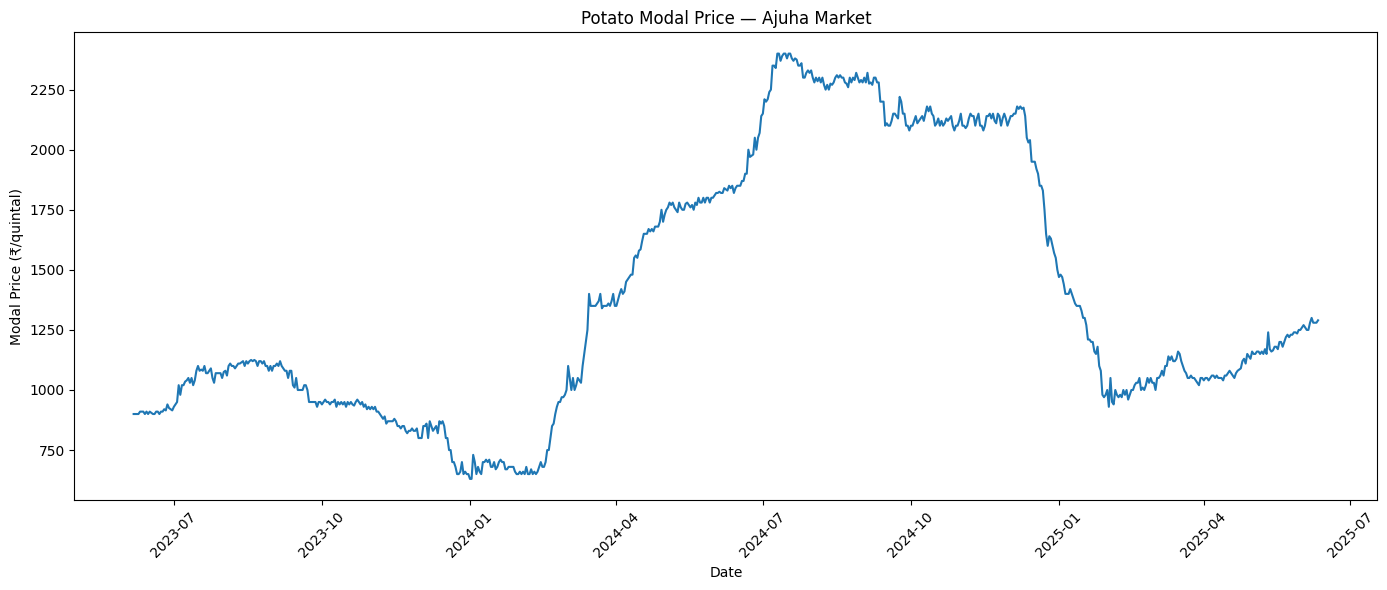

In [ ]:
# ==========================================
# SESSION 2 — PART 2.1: PRICE TREND
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    model_df["date"],
    model_df["modal_price"]
)

plt.xlabel("Date")
plt.ylabel("Modal Price (₹/quintal)")
plt.title("Potato Modal Price — Ajuha Market")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# SESSION 2 — PART 2.2
# MIN / MODAL / MAX PRICE ANALYSIS
# ==========================================

print("========== PRICE ORDER CHECK ==========")

invalid_rows = model_df[
    (model_df["min_price"] > model_df["modal_price"]) |
    (model_df["modal_price"] > model_df["max_price"])
]

print("Rows where Min > Modal or Modal > Max:",
      len(invalid_rows))

print("\n========== PRICE CORRELATION ==========")

print(
    model_df[
        ["min_price", "modal_price", "max_price"]
    ].corr()
)

print("\n========== PRICE SUMMARY ==========")

print(
    model_df[
        ["min_price", "modal_price", "max_price"]
    ].describe()
)

========== PRICE ORDER CHECK ==========
Rows where Min > Modal or Modal > Max: 0

========== PRICE CORRELATION ==========
             min_price  modal_price  max_price
min_price     1.000000     0.999815   0.999494
modal_price   0.999815     1.000000   0.999793
max_price     0.999494     0.999793   1.000000

========== PRICE SUMMARY ==========
         min_price  modal_price    max_price
count   728.000000   728.000000   728.000000
mean   1317.568681  1386.490385  1452.493132
std     540.831034   539.958106   540.592039
min     560.000000   630.000000   700.000000
25%     900.000000   960.000000  1020.000000
50%    1060.000000  1135.000000  1200.000000
75%    1800.000000  1870.000000  1940.000000
max    2350.000000  2400.000000  2480.000000


In [ ]:
# ==========================================
# SESSION 2 — PART 2.3: OUTLIER ANALYSIS
# ==========================================

Q1 = model_df["modal_price"].quantile(0.25)
Q3 = model_df["modal_price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = model_df[
    (model_df["modal_price"] < lower_bound) |
    (model_df["modal_price"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nNumber of potential outliers:", len(outliers))

print("\nPotential outlier percentage:",
      len(outliers) / len(model_df) * 100)

print("\nPotential outlier rows:")
display(
    outliers[
        ["date", "min_price", "modal_price", "max_price"]
    ].sort_values("modal_price")
)

Q1: 960.0
Q3: 1870.0
IQR: 910.0

Lower bound: -405.0
Upper bound: 3235.0

Number of potential outliers: 0

Potential outlier percentage: 0.0

Potential outlier rows:


,date,min_price,modal_price,max_price


In [ ]:
# ==========================================
# SESSION 2 — PART 2.4: MONTHLY PRICE BEHAVIOUR
# ==========================================

# Create a month column for analysis
model_df["month"] = model_df["date"].dt.month

# Calculate average modal price by month
monthly_price = (
    model_df
    .groupby("month")["modal_price"]
    .agg(["mean", "min", "max", "count"])
)

print("Monthly modal-price statistics:")
display(monthly_price)

Monthly modal-price statistics:


,mean,min,max,count
month,,,,
1,973.870968,630.0,1480.0,62
2,877.192982,650.0,1050.0,57
3,1155.241935,1000.0,1400.0,62
4,1318.135593,1040.0,1750.0,59
5,1482.016129,1150.0,1800.0,62
6,1412.063492,900.0,2140.0,63
7,1698.442623,930.0,2400.0,61
8,1695.887097,1060.0,2320.0,62
9,1610.916667,930.0,2320.0,60


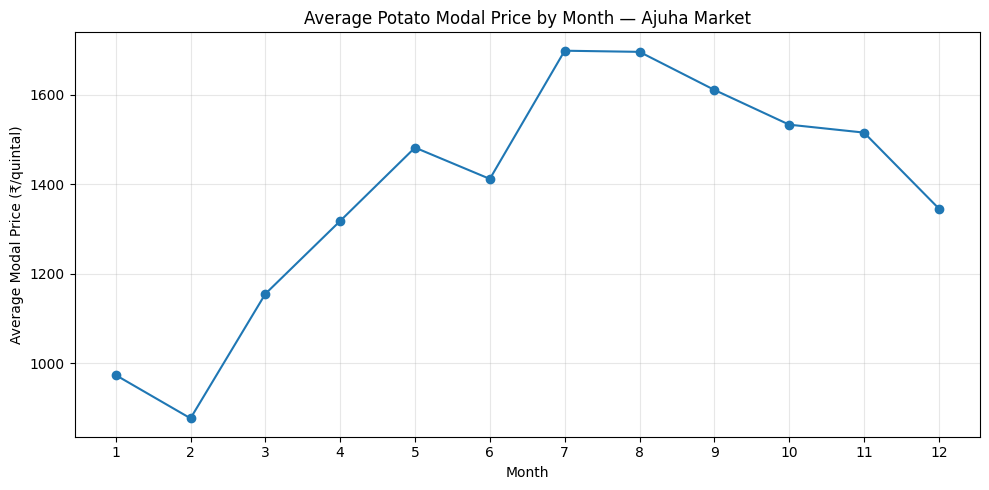

In [ ]:
# ==========================================
# MONTHLY AVERAGE PRICE
# ==========================================

monthly_average = (
    model_df
    .groupby("month")["modal_price"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Modal Price (₹/quintal)")
plt.title("Average Potato Modal Price by Month — Ajuha Market")

plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# SESSION 2 — PART 2.5: DAY-OF-WEEK ANALYSIS
# ==========================================

model_df["day_of_week"] = model_df["date"].dt.dayofweek

day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

daily_pattern = (
    model_df
    .groupby("day_of_week")["modal_price"]
    .agg(["mean", "min", "max", "count"])
)

daily_pattern.index = daily_pattern.index.map(day_names)

print("Modal price by day of week:")
display(daily_pattern)

Modal price by day of week:


,mean,min,max,count
day_of_week,,,,
Monday,1384.306931,630.0,2400.0,101
Tuesday,1382.142857,630.0,2380.0,105
Wednesday,1385.424528,650.0,2400.0,106
Thursday,1384.523810,650.0,2400.0,105
Friday,1386.952381,650.0,2380.0,105
Saturday,1390.735294,650.0,2390.0,102
Sunday,1391.442308,650.0,2400.0,104


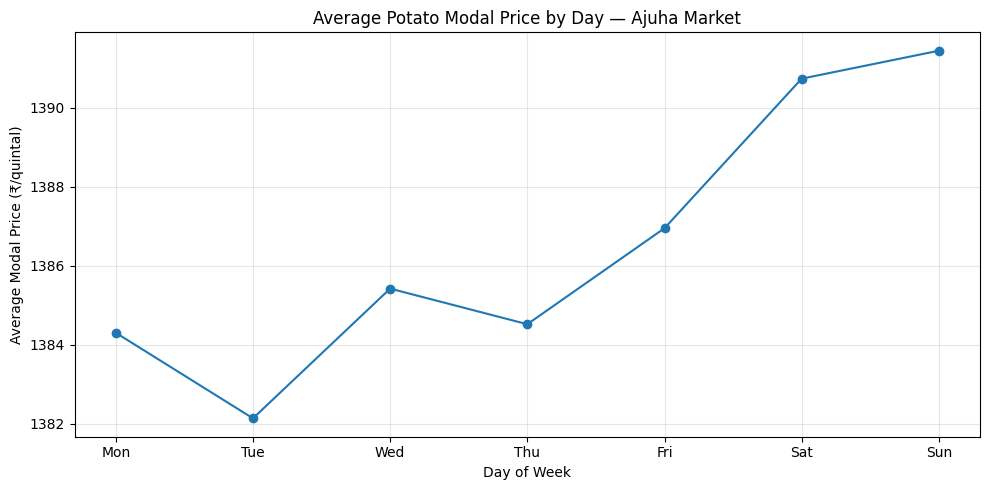

In [ ]:
# ==========================================
# DAY-OF-WEEK AVERAGE GRAPH
# ==========================================

day_average = (
    model_df
    .groupby("day_of_week")["modal_price"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    day_average.index,
    day_average.values,
    marker="o"
)

plt.xlabel("Day of Week")
plt.ylabel("Average Modal Price (₹/quintal)")
plt.title("Average Potato Modal Price by Day — Ajuha Market")

plt.xticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# SESSION 2 — PART 2.6: PRICE CHANGES
# ==========================================

model_df["price_change"] = (
    model_df["modal_price"].diff()
)

model_df["price_change_pct"] = (
    model_df["modal_price"].pct_change() * 100
)

print("========== ABSOLUTE PRICE CHANGE ==========")

print(
    model_df["price_change"].describe()
)

print("\n========== PERCENTAGE PRICE CHANGE ==========")

print(
    model_df["price_change_pct"].describe()
)

print("\n========== LARGEST PRICE MOVEMENTS ==========")

largest_changes = (
    model_df[
        ["date", "modal_price", "price_change", "price_change_pct"]
    ]
    .sort_values(
        "price_change_pct",
        key=lambda x: x.abs(),
        ascending=False
    )
    .head(10)
)

display(largest_changes)

========== ABSOLUTE PRICE CHANGE ==========
count    727.000000
mean       0.536451
std       26.874383
min     -100.000000
25%      -10.000000
50%        0.000000
75%       10.000000
max      150.000000
Name: price_change, dtype: float64

========== PERCENTAGE PRICE CHANGE ==========
count    727.000000
mean       0.075988
std        2.314321
min       -9.523810
25%       -0.952381
50%        0.000000
75%        1.063830
max       15.873016
Name: price_change_pct, dtype: float64

========== LARGEST PRICE MOVEMENTS ==========


,date,modal_price,price_change,price_change_pct
206,2024-01-03,730.0,100.0,15.873016
598,2025-02-02,1050.0,120.0,12.903226
278,2024-03-15,1400.0,150.0,12.000000
265,2024-03-02,1100.0,100.0,10.000000
599,2025-02-03,950.0,-100.0,-9.523810
593,2025-01-28,980.0,-100.0,-9.259259
179,2023-12-07,870.0,70.0,8.750000
696,2025-05-11,1240.0,90.0,7.826087
212,2024-01-09,700.0,50.0,7.692308
27,2023-07-04,1020.0,70.0,7.368421


In [ ]:
# ==========================================
# SESSION 2 — PART 2.7: ROLLING TRENDS
# ==========================================

# 7-observation and 30-observation rolling averages
model_df["rolling_mean_7"] = (
    model_df["modal_price"]
    .rolling(window=7)
    .mean()
)

model_df["rolling_mean_30"] = (
    model_df["modal_price"]
    .rolling(window=30)
    .mean()
)

print("Rolling features created.")

print("\nLast 10 rows:")
display(
    model_df[
        [
            "date",
            "modal_price",
            "rolling_mean_7",
            "rolling_mean_30"
        ]
    ].tail(10)
)

Rolling features created.

Last 10 rows:


,date,modal_price,rolling_mean_7,rolling_mean_30
718,2025-06-02,1270.0,1249.285714,1200.666667
719,2025-06-03,1260.0,1252.142857,1204.000000
720,2025-06-04,1250.0,1253.571429,1207.000000
721,2025-06-05,1250.0,1255.714286,1210.333333
722,2025-06-06,1280.0,1260.000000,1214.333333
723,2025-06-07,1300.0,1267.142857,1219.333333
724,2025-06-08,1280.0,1270.000000,1223.000000
725,2025-06-09,1280.0,1271.428571,1227.333333
726,2025-06-10,1280.0,1274.285714,1228.666667
727,2025-06-11,1290.0,1280.000000,1232.666667


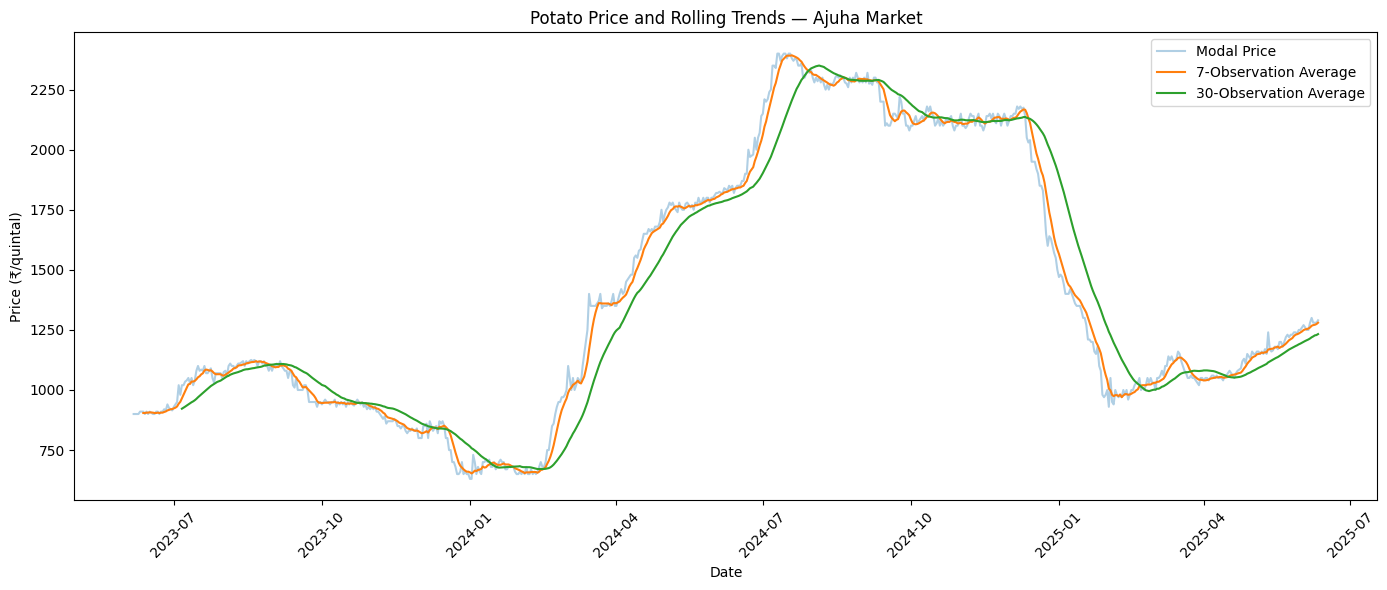

In [ ]:
# ==========================================
# ROLLING TREND GRAPH
# ==========================================

plt.figure(figsize=(14, 6))

plt.plot(
    model_df["date"],
    model_df["modal_price"],
    alpha=0.35,
    label="Modal Price"
)

plt.plot(
    model_df["date"],
    model_df["rolling_mean_7"],
    label="7-Observation Average"
)

plt.plot(
    model_df["date"],
    model_df["rolling_mean_30"],
    label="30-Observation Average"
)

plt.xlabel("Date")
plt.ylabel("Price (₹/quintal)")
plt.title("Potato Price and Rolling Trends — Ajuha Market")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# SESSION 2 — PART 2.8: LAG CORRELATION
# ==========================================

# Create temporary lag columns
model_df["lag_1_temp"] = model_df["modal_price"].shift(1)
model_df["lag_7_temp"] = model_df["modal_price"].shift(7)
model_df["lag_30_temp"] = model_df["modal_price"].shift(30)

print("Correlation with current modal price:")

print(
    model_df[
        [
            "modal_price",
            "lag_1_temp",
            "lag_7_temp",
            "lag_30_temp"
        ]
    ].corr()["modal_price"]
)

Correlation with current modal price:
modal_price    1.000000
lag_1_temp     0.998763
lag_7_temp     0.989569
lag_30_temp    0.897981
Name: modal_price, dtype: float64


In [ ]:
# ==========================================
# SESSION 2 — PART 2.9: NAIVE BASELINE
# ==========================================

# Today's price used to predict the next observed price
model_df["naive_prediction"] = model_df["modal_price"].shift(1)

# Actual next observation
model_df["actual_next_price"] = model_df["modal_price"]

# Remove the first row because it has no previous price
baseline_df = model_df.dropna(
    subset=["naive_prediction"]
).copy()

# Calculate absolute error
baseline_df["absolute_error"] = (
    baseline_df["actual_next_price"]
    - baseline_df["naive_prediction"]
).abs()

mae_baseline = baseline_df["absolute_error"].mean()

print("Naive baseline MAE:",
      round(mae_baseline, 2))

print("\nMean actual price:",
      round(baseline_df["actual_next_price"].mean(), 2))

print("\nBaseline MAE as percentage of mean price:",
      round(
          mae_baseline /
          baseline_df["actual_next_price"].mean() * 100,
          2
      ),
      "%")

Naive baseline MAE: 18.57

Mean actual price: 1387.16

Baseline MAE as percentage of mean price: 1.34 %


In [ ]:
import pandas as pd

model_df = pd.read_csv("model_df_checkpoint.csv")

# Convert date back to datetime
model_df["date"] = pd.to_datetime(model_df["date"])

print("Checkpoint loaded successfully!")
print("Shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nDate range:")
print(model_df["date"].min(), "→", model_df["date"].max())

print("\nFirst 5 rows:")
display(model_df.head())

Checkpoint loaded successfully!
Shape: (728, 15)

Columns:
['date', 'min_price', 'max_price', 'modal_price', 'month', 'day_of_week', 'price_change', 'price_change_pct', 'rolling_mean_7', 'rolling_mean_30', 'lag_1_temp', 'lag_7_temp', 'lag_30_temp', 'naive_prediction', 'actual_next_price']

Date range:
2023-06-06 00:00:00 → 2025-06-11 00:00:00

First 5 rows:


,date,min_price,max_price,modal_price,month,day_of_week,price_change,price_change_pct,rolling_mean_7,rolling_mean_30,lag_1_temp,lag_7_temp,lag_30_temp,naive_prediction,actual_next_price
0,2023-06-06,800.0,970.0,900.0,6,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,900.0
1,2023-06-07,800.0,980.0,900.0,6,2,0.0,0.000000,NaN,NaN,900.0,NaN,NaN,900.0,900.0
2,2023-06-08,800.0,970.0,900.0,6,3,0.0,0.000000,NaN,NaN,900.0,NaN,NaN,900.0,900.0
3,2023-06-09,830.0,970.0,900.0,6,4,0.0,0.000000,NaN,NaN,900.0,NaN,NaN,900.0,900.0
4,2023-06-10,830.0,980.0,910.0,6,5,10.0,1.111111,NaN,NaN,900.0,NaN,NaN,900.0,910.0


In [ ]:
# ==========================================
# SESSION 3 — PART 3.2
# CREATE CLEAN DATA + NEXT-DAY TARGET
# ==========================================

# Keep only original/raw price information

import numpy as np

features_df = model_df[
    ["date", "min_price", "max_price", "modal_price"]
].copy()

# Sort chronologically
features_df = (
    features_df
    .sort_values("date")
    .reset_index(drop=True)
)

# Date of the next observation
features_df["next_date"] = features_df["date"].shift(-1)

# Price of the next observation
features_df["target_price"] = features_df["modal_price"].shift(-1)

# Keep target only when the next observation is exactly
# one calendar day later
valid_next_day = (
    features_df["next_date"]
    == features_df["date"] + pd.Timedelta(days=1)
)

features_df.loc[~valid_next_day, "target_price"] = np.nan

print("Shape:", features_df.shape)

print("\nFirst 10 rows:")
display(features_df.head(10))

print("\nTarget availability:")
print("Valid next-day targets:",
      features_df["target_price"].notna().sum())

print("Invalid/missing next-day targets:",
      features_df["target_price"].isna().sum())

Shape: (728, 6)

First 10 rows:


,date,min_price,max_price,modal_price,next_date,target_price
0,2023-06-06,800.0,970.0,900.0,2023-06-07,900.0
1,2023-06-07,800.0,980.0,900.0,2023-06-08,900.0
2,2023-06-08,800.0,970.0,900.0,2023-06-09,900.0
3,2023-06-09,830.0,970.0,900.0,2023-06-10,910.0
4,2023-06-10,830.0,980.0,910.0,2023-06-11,910.0
5,2023-06-11,840.0,1000.0,910.0,2023-06-12,910.0
6,2023-06-12,840.0,1000.0,910.0,2023-06-13,900.0
7,2023-06-13,810.0,980.0,900.0,2023-06-14,910.0
8,2023-06-14,850.0,1000.0,910.0,2023-06-15,900.0
9,2023-06-15,810.0,980.0,900.0,2023-06-16,910.0



Target availability:
Valid next-day targets: 719
Invalid/missing next-day targets: 9


In [ ]:
# ==========================================
# SESSION 3 — PART 3.3
# CREATE CALENDAR-BASED LAG FEATURES
# ==========================================

# Start from our clean forecasting dataset
feature_df = features_df[
    [
        "date",
        "min_price",
        "max_price",
        "modal_price",
        "target_price"
    ]
].copy()

# Create calendar-based lag features
lag_days = [1, 3, 7, 14, 30]

for lag in lag_days:
    lag_data = feature_df[
        ["date", "modal_price"]
    ].copy()

    lag_data = lag_data.rename(
        columns={"modal_price": f"lag_{lag}"}
    )

    # Move historical date forward so it matches
    # the date on which we want to use that old price
    lag_data["date"] = (
        lag_data["date"]
        + pd.Timedelta(days=lag)
    )

    feature_df = feature_df.merge(
        lag_data,
        on="date",
        how="left"
    )

print("Lag features created successfully!")

print("\nColumns:")
print(feature_df.columns.tolist())

print("\nFirst 10 rows:")
display(
    feature_df[
        [
            "date",
            "modal_price",
            "lag_1",
            "lag_3",
            "lag_7",
            "lag_14",
            "lag_30",
            "target_price"
        ]
    ].head(10)
)

print("\nMissing values in lag features:")

print(
    feature_df[
        [
            "lag_1",
            "lag_3",
            "lag_7",
            "lag_14",
            "lag_30"
        ]
    ].isna().sum()
)

Lag features created successfully!

Columns:
['date', 'min_price', 'max_price', 'modal_price', 'target_price', 'lag_1', 'lag_3', 'lag_7', 'lag_14', 'lag_30']

First 10 rows:


,date,modal_price,lag_1,lag_3,lag_7,lag_14,lag_30,target_price
0,2023-06-06,900.0,NaN,NaN,NaN,NaN,NaN,900.0
1,2023-06-07,900.0,900.0,NaN,NaN,NaN,NaN,900.0
2,2023-06-08,900.0,900.0,NaN,NaN,NaN,NaN,900.0
3,2023-06-09,900.0,900.0,900.0,NaN,NaN,NaN,910.0
4,2023-06-10,910.0,900.0,900.0,NaN,NaN,NaN,910.0
5,2023-06-11,910.0,910.0,900.0,NaN,NaN,NaN,910.0
6,2023-06-12,910.0,910.0,900.0,NaN,NaN,NaN,900.0
7,2023-06-13,900.0,910.0,910.0,900.0,NaN,NaN,910.0
8,2023-06-14,910.0,900.0,910.0,900.0,NaN,NaN,900.0
9,2023-06-15,900.0,910.0,910.0,900.0,NaN,NaN,910.0



Missing values in lag features:
lag_1      9
lag_3     12
lag_7     16
lag_14    22
lag_30    38
dtype: int64


In [ ]:
# ==========================================
# SESSION 3 — PART 3.4
# CALENDAR-BASED ROLLING FEATURES
# ==========================================

# Create a complete daily calendar
daily_prices = (
    feature_df[["date", "modal_price"]]
    .set_index("date")
    .sort_index()
)

full_calendar = pd.date_range(
    start=daily_prices.index.min(),
    end=daily_prices.index.max(),
    freq="D"
)

daily_prices = daily_prices.reindex(full_calendar)

# Calculate rolling averages using calendar days
daily_prices["rolling_mean_7"] = (
    daily_prices["modal_price"]
    .rolling("7D")
    .mean()
)

daily_prices["rolling_mean_14"] = (
    daily_prices["modal_price"]
    .rolling("14D")
    .mean()
)

daily_prices["rolling_mean_30"] = (
    daily_prices["modal_price"]
    .rolling("30D")
    .mean()
)

# Bring the rolling features back to our observed dates
rolling_features = daily_prices[
    [
        "rolling_mean_7",
        "rolling_mean_14",
        "rolling_mean_30"
    ]
].reindex(feature_df["date"])

rolling_features.index = feature_df.index

feature_df = pd.concat(
    [feature_df, rolling_features],
    axis=1
)

print("Rolling features created!")

print("\nColumns:")
print(feature_df.columns.tolist())

print("\nLast 10 observations:")
display(
    feature_df[
        [
            "date",
            "modal_price",
            "rolling_mean_7",
            "rolling_mean_14",
            "rolling_mean_30",
            "target_price"
        ]
    ].tail(10)
)

Rolling features created!

Columns:
['date', 'min_price', 'max_price', 'modal_price', 'target_price', 'lag_1', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30']

Last 10 observations:


,date,modal_price,rolling_mean_7,rolling_mean_14,rolling_mean_30,target_price
718,2025-06-02,1270.0,1249.285714,1232.500000,1200.666667,1260.0
719,2025-06-03,1260.0,1252.142857,1238.214286,1204.000000,1250.0
720,2025-06-04,1250.0,1253.571429,1241.785714,1207.000000,1250.0
721,2025-06-05,1250.0,1255.714286,1243.928571,1210.333333,1280.0
722,2025-06-06,1280.0,1260.000000,1247.500000,1214.333333,1300.0
723,2025-06-07,1300.0,1267.142857,1253.214286,1219.333333,1280.0
724,2025-06-08,1280.0,1270.000000,1256.785714,1223.000000,1280.0
725,2025-06-09,1280.0,1271.428571,1260.357143,1227.333333,1280.0
726,2025-06-10,1280.0,1274.285714,1263.214286,1228.666667,1290.0
727,2025-06-11,1290.0,1280.000000,1266.785714,1232.666667,NaN


In [ ]:
# ==========================================
# SESSION 3 — PART 3.5
# PRICE TREND FEATURES
# ==========================================

# 1-day absolute change
feature_df["price_change_1d"] = (
    feature_df["modal_price"] -
    feature_df["lag_1"]
)

# 7-day absolute change
feature_df["price_change_7d"] = (
    feature_df["modal_price"] -
    feature_df["lag_7"]
)

# 1-day percentage change
feature_df["price_change_pct_1d"] = (
    (
        feature_df["modal_price"] -
        feature_df["lag_1"]
    )
    / feature_df["lag_1"]
) * 100

print("Trend features created!")

print("\nLast 10 observations:")
display(
    feature_df[
        [
            "date",
            "modal_price",
            "lag_1",
            "lag_7",
            "price_change_1d",
            "price_change_7d",
            "price_change_pct_1d"
        ]
    ].tail(10)
)

print("\nMissing values:")
print(
    feature_df[
        [
            "price_change_1d",
            "price_change_7d",
            "price_change_pct_1d"
        ]
    ].isna().sum()
)

Trend features created!

Last 10 observations:


,date,modal_price,lag_1,lag_7,price_change_1d,price_change_7d,price_change_pct_1d
718,2025-06-02,1270.0,1260.0,1230.0,10.0,40.0,0.793651
719,2025-06-03,1260.0,1270.0,1240.0,-10.0,20.0,-0.787402
720,2025-06-04,1250.0,1260.0,1240.0,-10.0,10.0,-0.793651
721,2025-06-05,1250.0,1250.0,1235.0,0.0,15.0,0.000000
722,2025-06-06,1280.0,1250.0,1250.0,30.0,30.0,2.400000
723,2025-06-07,1300.0,1280.0,1250.0,20.0,50.0,1.562500
724,2025-06-08,1280.0,1300.0,1260.0,-20.0,20.0,-1.538462
725,2025-06-09,1280.0,1280.0,1270.0,0.0,10.0,0.000000
726,2025-06-10,1280.0,1280.0,1260.0,0.0,20.0,0.000000
727,2025-06-11,1290.0,1280.0,1250.0,10.0,40.0,0.781250



Missing values:
price_change_1d         9
price_change_7d        16
price_change_pct_1d     9
dtype: int64


In [ ]:
# ==========================================
# SESSION 3 — PART 3.6
# CALENDAR / SEASONAL FEATURES
# ==========================================

feature_df["month"] = feature_df["date"].dt.month

feature_df["quarter"] = feature_df["date"].dt.quarter

feature_df["day_of_year"] = feature_df["date"].dt.dayofyear

print("Calendar features created!")

print("\nLast 10 observations:")
display(
    feature_df[
        [
            "date",
            "month",
            "quarter",
            "day_of_year",
            "modal_price",
            "target_price"
        ]
    ].tail(10)
)

Calendar features created!

Last 10 observations:


,date,month,quarter,day_of_year,modal_price,target_price
718,2025-06-02,6,2,153,1270.0,1260.0
719,2025-06-03,6,2,154,1260.0,1250.0
720,2025-06-04,6,2,155,1250.0,1250.0
721,2025-06-05,6,2,156,1250.0,1280.0
722,2025-06-06,6,2,157,1280.0,1300.0
723,2025-06-07,6,2,158,1300.0,1280.0
724,2025-06-08,6,2,159,1280.0,1280.0
725,2025-06-09,6,2,160,1280.0,1280.0
726,2025-06-10,6,2,161,1280.0,1290.0
727,2025-06-11,6,2,162,1290.0,NaN


In [ ]:
# ==========================================
# SESSION 3 — PART 3.7
# PREPARE FINAL ML DATASET
# ==========================================

feature_columns = [
    "min_price",
    "max_price",
    "modal_price",
    "lag_1",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "price_change_1d",
    "price_change_7d",
    "price_change_pct_1d",
    "month",
    "quarter",
    "day_of_year"
]

target_column = "target_price"

ml_df = feature_df[
    ["date"] + feature_columns + [target_column]
].copy()

print("Before removing missing values:")
print("Rows:", len(ml_df))

print("\nMissing values:")
print(ml_df.isnull().sum())

# Remove rows where any model feature or target is missing
ml_df = ml_df.dropna(
    subset=feature_columns + [target_column]
).reset_index(drop=True)

print("\nAfter removing incomplete rows:")
print("Rows:", len(ml_df))

print("\nRemaining missing values:")
print(
    ml_df[
        feature_columns + [target_column]
    ].isnull().sum().sum()
)

print("\nDate range:")
print(ml_df["date"].min(), "→", ml_df["date"].max())

print("\nFinal columns:")
print(ml_df.columns.tolist())

Before removing missing values:
Rows: 728

Missing values:
date                    0
min_price               0
max_price               0
modal_price             0
lag_1                   9
lag_3                  12
lag_7                  16
lag_14                 22
lag_30                 38
rolling_mean_7          0
rolling_mean_14         0
rolling_mean_30         0
price_change_1d         9
price_change_7d        16
price_change_pct_1d     9
month                   0
quarter                 0
day_of_year             0
target_price            9
dtype: int64

After removing incomplete rows:
Rows: 652

Remaining missing values:
0

Date range:
2023-07-06 00:00:00 → 2025-06-10 00:00:00

Final columns:
['date', 'min_price', 'max_price', 'modal_price', 'lag_1', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'price_change_1d', 'price_change_7d', 'price_change_pct_1d', 'month', 'quarter', 'day_of_year', 'target_price']


In [ ]:
# ==========================================
# SESSION 3 — PART 3.8
# DATA-LEAKAGE CHECK
# ==========================================

print("========== FEATURE / TARGET CHECK ==========")

print("Target:", target_column)

print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

print("\n========== TARGET RELATIONSHIP CHECK ==========")

# Check whether target and current modal price are shifted correctly
print(
    ml_df[
        ["date", "modal_price", "target_price"]
    ].head(10)
)

print("\nLast 10 rows:")
display(
    ml_df[
        ["date", "modal_price", "target_price"]
    ].tail(10)
)

print("\n========== FUTURE-DATE CHECK ==========")

future_target_count = (
    (ml_df["target_price"].notna()) &
    (ml_df["date"] >= ml_df["date"].max())
).sum()

print(
    "Rows where target exists on/after final modeling date:",
    future_target_count
)

print("\n========== FEATURE CORRELATIONS ==========")

correlations = (
    ml_df[
        feature_columns + [target_column]
    ]
    .corr(numeric_only=True)["target_price"]
    .sort_values(ascending=False)
)

display(correlations)

========== FEATURE / TARGET CHECK ==========
Target: target_price

Features:
- min_price
- max_price
- modal_price
- lag_1
- lag_3
- lag_7
- lag_14
- lag_30
- rolling_mean_7
- rolling_mean_14
- rolling_mean_30
- price_change_1d
- price_change_7d
- price_change_pct_1d
- month
- quarter
- day_of_year

========== TARGET RELATIONSHIP CHECK ==========
        date  modal_price  target_price
0 2023-07-06       1020.0        1020.0
1 2023-07-07       1020.0        1035.0
2 2023-07-08       1035.0        1040.0
3 2023-07-09       1040.0        1050.0
4 2023-07-10       1050.0        1030.0
5 2023-07-11       1030.0        1050.0
6 2023-07-12       1050.0        1020.0
7 2023-07-13       1020.0        1040.0
8 2023-07-14       1040.0        1080.0
9 2023-07-15       1080.0        1100.0

Last 10 rows:


,date,modal_price,target_price
642,2025-06-01,1260.0,1270.0
643,2025-06-02,1270.0,1260.0
644,2025-06-03,1260.0,1250.0
645,2025-06-04,1250.0,1250.0
646,2025-06-05,1250.0,1280.0
647,2025-06-06,1280.0,1300.0
648,2025-06-07,1300.0,1280.0
649,2025-06-08,1280.0,1280.0
650,2025-06-09,1280.0,1280.0
651,2025-06-10,1280.0,1290.0



========== FUTURE-DATE CHECK ==========
Rows where target exists on/after final modeling date: 1

========== FEATURE CORRELATIONS ==========


,target_price
target_price,1.000000
modal_price,0.998731
min_price,0.998574
max_price,0.998572
lag_1,0.997774
rolling_mean_7,0.996042
lag_3,0.995127
rolling_mean_14,0.989994
lag_7,0.986879
rolling_mean_30,0.968886


In [ ]:
# ==========================================
# SESSION 3 — PART 3.9
# TIME-BASED TRAIN / TEST SPLIT
# ==========================================

# Features and target
X = ml_df[feature_columns].copy()
y = ml_df[target_column].copy()

# Use chronological order — NO SHUFFLING
split_index = int(len(ml_df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

# Corresponding dates
train_dates = ml_df["date"].iloc[:split_index].copy()
test_dates = ml_df["date"].iloc[split_index:].copy()

print("========== TRAIN / TEST SPLIT ==========")

print("Total observations:", len(ml_df))

print("\nTraining observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(train_dates.min(), "→", train_dates.max())

print("\nTesting period:")
print(test_dates.min(), "→", test_dates.max())

print("\nTraining percentage:",
      round(len(X_train) / len(ml_df) * 100, 2), "%")

print("Testing percentage:",
      round(len(X_test) / len(ml_df) * 100, 2), "%")

========== TRAIN / TEST SPLIT ==========
Total observations: 652

Training observations: 521
Testing observations: 131

Training period:
2023-07-06 00:00:00 → 2025-01-30 00:00:00

Testing period:
2025-01-31 00:00:00 → 2025-06-10 00:00:00

Training percentage: 79.91 %
Testing percentage: 20.09 %


In [ ]:
# ==========================================
# SESSION 4 — PART 4.1
# LINEAR REGRESSION
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the model pipeline
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Train
linear_model.fit(X_train, y_train)

# Predict
linear_predictions = linear_model.predict(X_test)

# Evaluate
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("========== LINEAR REGRESSION ==========")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

========== LINEAR REGRESSION ==========
MAE : 16.13
RMSE: 23.36
R²  : 0.9324


In [ ]:
# ==========================================
# SESSION 4 — PART 4.2
# RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("========== RANDOM FOREST ==========")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

========== RANDOM FOREST ==========
MAE : 21.23
RMSE: 29.53
R²  : 0.8919


In [ ]:
# ==========================================
# SESSION 4 — PART 4.3
# XGBOOST SETUP
# ==========================================

!pip -q install xgboost

from xgboost import XGBRegressor

print("XGBoost ready!")

XGBoost ready!


In [ ]:
# ==========================================
# XGBOOST MODEL
# ==========================================

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
xgb_predictions = xgb_model.predict(X_test)

# Evaluate
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("========== XGBOOST ==========")
print("MAE :", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))
print("R²  :", round(xgb_r2, 4))

========== XGBOOST ==========
MAE : 19.98
RMSE: 26.9
R²  : 0.9103


In [ ]:
# Recreate naive baseline MAE

naive_predictions = X_test["modal_price"].values

mae_baseline = mean_absolute_error(
    y_test,
    naive_predictions
)

print("Naive baseline MAE:", round(mae_baseline, 2))

Naive baseline MAE: 16.72


In [ ]:
# ==========================================
# SESSION 4 — PART 4.4
# MODEL COMPARISON
# ==========================================

results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_baseline,
        linear_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        np.nan,
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        np.nan,
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

results = results.sort_values(
    "MAE",
    ascending=True
).reset_index(drop=True)

print("========== MODEL COMPARISON ==========")
display(results)

========== MODEL COMPARISON ==========


,Model,MAE,RMSE,R2
0,Linear Regression,16.128259,23.357109,0.932354
1,Naive Baseline,16.717557,NaN,NaN
2,XGBoost,19.978955,26.902455,0.910259
3,Random Forest,21.233106,29.525876,0.891904


In [ ]:
print("Correct test-set baseline MAE:", round(mae_baseline, 2))
print("Linear Regression MAE:", round(linear_mae, 2))
print("Random Forest MAE:", round(rf_mae, 2))
print("XGBoost MAE:", round(xgb_mae, 2))

Correct test-set baseline MAE: 16.72
Linear Regression MAE: 16.13
Random Forest MAE: 21.23
XGBoost MAE: 19.98


In [ ]:
# ==========================================
# SESSION 4 — PART 4.5
# ACTUAL VS PREDICTED PRICE
# ==========================================

prediction_df = pd.DataFrame({
    "date": test_dates.values,
    "actual_price": y_test.values,
    "linear_prediction": linear_predictions,
    "naive_prediction": naive_predictions
})

print("Prediction dataframe:")
display(prediction_df.head(10))

Prediction dataframe:


,date,actual_price,linear_prediction,naive_prediction
0,2025-01-31,930.0,987.418963,1000.0
1,2025-02-01,1050.0,926.981836,930.0
2,2025-02-02,950.0,1012.450330,1050.0
3,2025-02-03,940.0,956.331711,950.0
4,2025-02-04,1000.0,938.572620,940.0
5,2025-02-05,980.0,982.476866,1000.0
6,2025-02-06,970.0,979.042775,980.0
7,2025-02-07,980.0,967.673563,970.0
8,2025-02-08,970.0,974.385801,980.0
9,2025-02-09,1000.0,963.895282,970.0


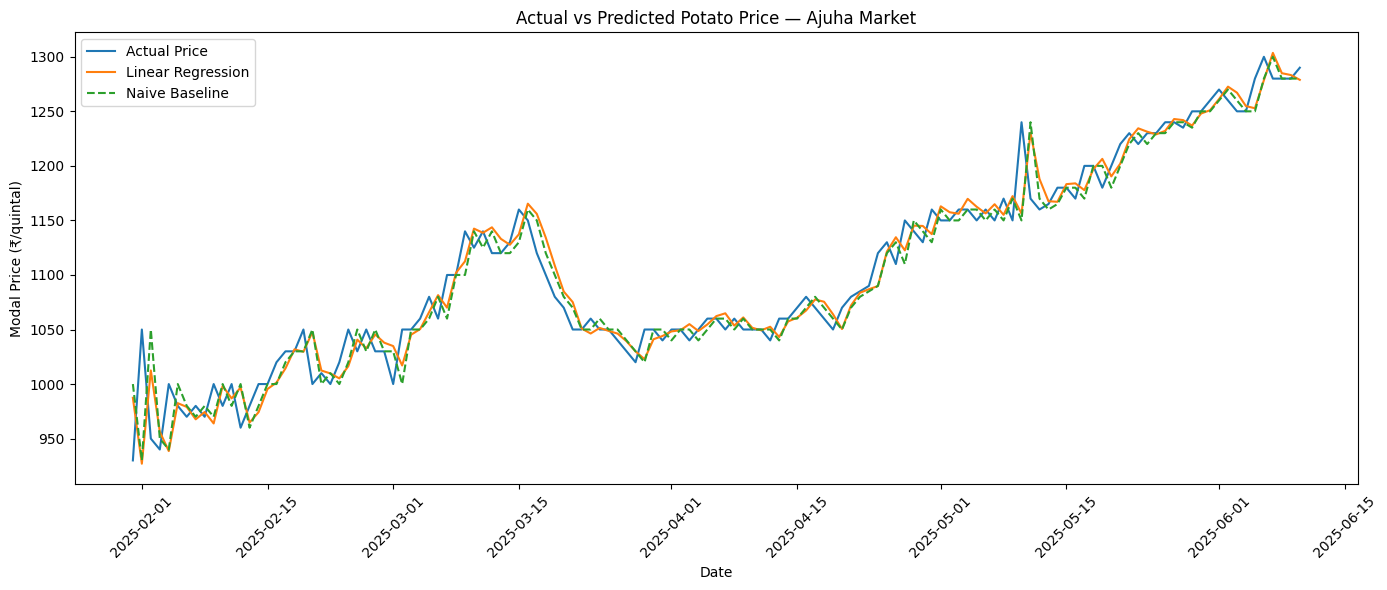

In [ ]:
# ==========================================
# ACTUAL VS PREDICTED GRAPH
# ==========================================
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))

plt.plot(
    prediction_df["date"],
    prediction_df["actual_price"],
    label="Actual Price"
)

plt.plot(
    prediction_df["date"],
    prediction_df["linear_prediction"],
    label="Linear Regression"
)

plt.plot(
    prediction_df["date"],
    prediction_df["naive_prediction"],
    label="Naive Baseline",
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Modal Price (₹/quintal)")
plt.title("Actual vs Predicted Potato Price — Ajuha Market")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# SESSION 4 — PART 4.6
# PREDICTION ERROR ANALYSIS
# ==========================================

prediction_df["linear_error"] = (
    prediction_df["actual_price"]
    - prediction_df["linear_prediction"]
)

prediction_df["linear_absolute_error"] = (
    prediction_df["linear_error"].abs()
)

prediction_df["naive_error"] = (
    prediction_df["actual_price"]
    - prediction_df["naive_prediction"]
)

prediction_df["naive_absolute_error"] = (
    prediction_df["naive_error"].abs()
)

print("Linear Regression error statistics:")
print(
    prediction_df["linear_absolute_error"].describe()
)

print("\nNaive baseline error statistics:")
print(
    prediction_df["naive_absolute_error"].describe()
)

print("\nTop 10 Linear Regression errors:")

display(
    prediction_df[
        [
            "date",
            "actual_price",
            "linear_prediction",
            "naive_prediction",
            "linear_error",
            "linear_absolute_error"
        ]
    ]
    .sort_values(
        "linear_absolute_error",
        ascending=False
    )
    .head(10)
)

Linear Regression error statistics:
count    131.000000
mean      16.128259
std       16.959641
min        0.632710
25%        4.873267
50%       12.919072
75%       21.482833
max      123.018164
Name: linear_absolute_error, dtype: float64

Naive baseline error statistics:
count    131.000000
mean      16.717557
std       18.910426
min        0.000000
25%       10.000000
50%       10.000000
75%       20.000000
max      120.000000
Name: naive_absolute_error, dtype: float64

Top 10 Linear Regression errors:


,date,actual_price,linear_prediction,naive_prediction,linear_error,linear_absolute_error
1,2025-02-01,1050.0,926.981836,930.0,123.018164,123.018164
99,2025-05-10,1240.0,1156.207395,1150.0,83.792605,83.792605
2,2025-02-02,950.0,1012.450330,1050.0,-62.450330,62.450330
4,2025-02-04,1000.0,938.572620,940.0,61.427380,61.427380
100,2025-05-11,1170.0,1230.452489,1240.0,-60.452489,60.452489
0,2025-01-31,930.0,987.418963,1000.0,-57.418963,57.418963
20,2025-02-20,1000.0,1047.700673,1050.0,-47.700673,47.700673
12,2025-02-12,960.0,996.855891,1000.0,-36.855891,36.855891
9,2025-02-09,1000.0,963.895282,970.0,36.104718,36.104718
45,2025-03-17,1120.0,1155.996574,1150.0,-35.996574,35.996574


In [ ]:
# ==========================================
# SESSION 4 — PART 4.7
# LINEAR REGRESSION FEATURE IMPORTANCE
# ==========================================

# Extract the trained Linear Regression model
lr = linear_model.named_steps["model"]

# Create coefficient table
coefficient_df = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": lr.coef_
})

# Add absolute magnitude for ranking
coefficient_df["absolute_coefficient"] = (
    coefficient_df["coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "absolute_coefficient",
    ascending=False
).reset_index(drop=True)

print("Linear Regression coefficients:")
display(coefficient_df)

Linear Regression coefficients:


,feature,coefficient,absolute_coefficient
0,max_price,134.472399,134.472399
1,modal_price,119.406791,119.406791
2,lag_1,119.260832,119.260832
3,lag_7,115.367912,115.367912
4,min_price,68.233717,68.233717
5,rolling_mean_7,44.343938,44.343938
6,rolling_mean_30,39.371566,39.371566
7,lag_14,-24.491731,24.491731
8,price_change_7d,22.615480,22.615480
9,lag_30,-19.727296,19.727296


In [ ]:
# ==========================================
# SESSION 4 — PART 4.8
# FEATURE MULTICOLLINEARITY CHECK
# ==========================================

feature_corr = (
    ml_df[feature_columns]
    .corr()
)

# Find the strongest feature-to-feature relationships
pairs = []

for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        feature_a = feature_corr.columns[i]
        feature_b = feature_corr.columns[j]
        correlation = feature_corr.iloc[i, j]

        pairs.append({
            "feature_1": feature_a,
            "feature_2": feature_b,
            "correlation": correlation,
            "absolute_correlation": abs(correlation)
        })

strong_pairs = (
    pd.DataFrame(pairs)
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
)

print("Top 20 strongest feature-to-feature correlations:")
display(strong_pairs.head(20))

Top 20 strongest feature-to-feature correlations:


,feature_1,feature_2,correlation,absolute_correlation
1,min_price,modal_price,0.999823,0.999823
16,max_price,modal_price,0.999805,0.999805
0,min_price,max_price,0.999525,0.999525
61,lag_3,rolling_mean_7,0.999448,0.999448
73,lag_7,rolling_mean_14,0.998978,0.998978
31,modal_price,lag_1,0.998734,0.998734
49,lag_1,rolling_mean_7,0.998629,0.998629
2,min_price,lag_1,0.998627,0.998627
17,max_price,lag_1,0.998599,0.998599
45,lag_1,lag_3,0.997842,0.997842


In [ ]:
# ==========================================
# SESSION 4 — PART 4.9
# REDUCED FEATURE SET
# ==========================================

reduced_features = [
    "modal_price",
    "lag_1",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "price_change_7d",
    "price_change_pct_1d",
    "month",
    "day_of_year"
]

X_reduced = ml_df[reduced_features].copy()
y_reduced = ml_df["target_price"].copy()

print("Number of features:", len(reduced_features))
print("\nFeatures:")
for feature in reduced_features:
    print("-", feature)

print("\nShape:", X_reduced.shape)

Number of features: 13

Features:
- modal_price
- lag_1
- lag_3
- lag_7
- lag_14
- lag_30
- rolling_mean_7
- rolling_mean_14
- rolling_mean_30
- price_change_7d
- price_change_pct_1d
- month
- day_of_year

Shape: (652, 13)


In [ ]:
# ==========================================
# PART 4.10
# REDUCED FEATURE TRAIN / TEST SPLIT
# ==========================================

X_reduced_train = X_reduced.iloc[:split_index].copy()
X_reduced_test = X_reduced.iloc[split_index:].copy()

y_reduced_train = y_reduced.iloc[:split_index].copy()
y_reduced_test = y_reduced.iloc[split_index:].copy()

print("Training:", X_reduced_train.shape)
print("Testing :", X_reduced_test.shape)

print("\nTraining period:")
print(train_dates.min(), "→", train_dates.max())

print("\nTesting period:")
print(test_dates.min(), "→", test_dates.max())

Training: (521, 13)
Testing : (131, 13)

Training period:
2023-07-06 00:00:00 → 2025-01-30 00:00:00

Testing period:
2025-01-31 00:00:00 → 2025-06-10 00:00:00


In [ ]:
# ==========================================
# PART 4.11
# REDUCED LINEAR REGRESSION
# ==========================================

reduced_linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

reduced_linear_model.fit(
    X_reduced_train,
    y_reduced_train
)

reduced_linear_predictions = (
    reduced_linear_model.predict(X_reduced_test)
)

reduced_linear_mae = mean_absolute_error(
    y_reduced_test,
    reduced_linear_predictions
)

reduced_linear_rmse = np.sqrt(
    mean_squared_error(
        y_reduced_test,
        reduced_linear_predictions
    )
)

reduced_linear_r2 = r2_score(
    y_reduced_test,
    reduced_linear_predictions
)

print("========== REDUCED LINEAR REGRESSION ==========")
print("MAE :", round(reduced_linear_mae, 2))
print("RMSE:", round(reduced_linear_rmse, 2))
print("R²  :", round(reduced_linear_r2, 4))

========== REDUCED LINEAR REGRESSION ==========
MAE : 16.52
RMSE: 23.6
R²  : 0.9309


In [ ]:
# ==========================================
# SESSION 4 — PART 4.12
# RIDGE REGRESSION
# ==========================================

from sklearn.linear_model import Ridge

# Ridge with standardization
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

# Train
ridge_model.fit(
    X_train,
    y_train
)

# Predict
ridge_predictions = ridge_model.predict(X_test)

# Evaluate
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_predictions
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("========== RIDGE REGRESSION ==========")
print("MAE :", round(ridge_mae, 2))
print("RMSE:", round(ridge_rmse, 2))
print("R²  :", round(ridge_r2, 4))

========== RIDGE REGRESSION ==========
MAE : 16.22
RMSE: 23.65
R²  : 0.9306


In [ ]:
# ==========================================
# SESSION 4 — PART 4.13
# SAVE CURRENT MODEL RESULTS
# ==========================================

final_results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_baseline,
        linear_mae,
        ridge_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        np.nan,
        linear_rmse,
        ridge_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        np.nan,
        linear_r2,
        ridge_r2,
        rf_r2,
        xgb_r2
    ]
})

final_results = final_results.sort_values(
    "MAE"
).reset_index(drop=True)

display(final_results)

,Model,MAE,RMSE,R2
0,Linear Regression,16.128259,23.357109,0.932354
1,Ridge Regression,16.216530,23.649505,0.930650
2,Naive Baseline,16.717557,NaN,NaN
3,XGBoost,19.978955,26.902455,0.910259
4,Random Forest,21.233106,29.525876,0.891904


In [ ]:
# Save the results locally

final_results.to_csv(
    "model_results_checkpoint.csv",
    index=False
)

print("Model results checkpoint saved.")

Model results checkpoint saved.


In [ ]:
# ==========================================
# SESSION 4 — PART 4.14
# WALK-FORWARD VALIDATION
# ==========================================

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

walk_forward_results = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X), start=1
):

    X_fold_train = X.iloc[train_idx]
    X_fold_test = X.iloc[test_idx]

    y_fold_train = y.iloc[train_idx]
    y_fold_test = y.iloc[test_idx]

    # Fresh model for each fold
    fold_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    fold_predictions = fold_model.predict(
        X_fold_test
    )

    fold_mae = mean_absolute_error(
        y_fold_test,
        fold_predictions
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_fold_test,
            fold_predictions
        )
    )

    fold_r2 = r2_score(
        y_fold_test,
        fold_predictions
    )

    walk_forward_results.append({
        "fold": fold,
        "train_start": ml_df["date"].iloc[train_idx].min(),
        "train_end": ml_df["date"].iloc[train_idx].max(),
        "test_start": ml_df["date"].iloc[test_idx].min(),
        "test_end": ml_df["date"].iloc[test_idx].max(),
        "MAE": fold_mae,
        "RMSE": fold_rmse,
        "R2": fold_r2
    })

walk_forward_results = pd.DataFrame(
    walk_forward_results
)

print("========== WALK-FORWARD VALIDATION ==========")

display(walk_forward_results)

print("\nAverage MAE:",
      round(walk_forward_results["MAE"].mean(), 2))

print("Average RMSE:",
      round(walk_forward_results["RMSE"].mean(), 2))

print("Average R²:",
      round(walk_forward_results["R2"].mean(), 4))

========== WALK-FORWARD VALIDATION ==========


,fold,train_start,train_end,test_start,test_end,MAE,RMSE,R2
0,1,2023-07-06,2023-11-09,2023-11-10,2024-03-08,46.093917,56.507040,0.781798
1,2,2023-07-06,2024-03-08,2024-03-09,2024-07-13,22.820848,33.828544,0.987104
2,3,2023-07-06,2024-07-13,2024-07-14,2024-11-05,20.376748,26.871820,0.921663
3,4,2023-07-06,2024-11-05,2024-11-07,2025-02-22,26.282924,35.272789,0.994340
4,5,2023-07-06,2025-02-22,2025-02-23,2025-06-10,13.992051,18.681971,0.945326



Average MAE: 25.91
Average RMSE: 34.23
Average R²: 0.926


In [ ]:
# ==========================================
# SESSION 4 — PART 4.15
# WALK-FORWARD MODEL VS NAIVE BASELINE
# ==========================================

comparison_folds = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X), start=1
):

    # -----------------------------
    # Data for this fold
    # -----------------------------
    X_fold_train = X.iloc[train_idx]
    X_fold_test = X.iloc[test_idx]

    y_fold_train = y.iloc[train_idx]
    y_fold_test = y.iloc[test_idx]

    # -----------------------------
    # Train Linear Regression
    # -----------------------------
    fold_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    lr_predictions = fold_model.predict(
        X_fold_test
    )

    # -----------------------------
    # Linear Regression MAE
    # -----------------------------
    lr_mae = mean_absolute_error(
        y_fold_test,
        lr_predictions
    )

    # -----------------------------
    # Naive baseline
    # Today's modal price
    # predicts next day's price
    # -----------------------------
    naive_fold_predictions = (
        X_fold_test["modal_price"].values
    )

    naive_fold_mae = mean_absolute_error(
        y_fold_test,
        naive_fold_predictions
    )

    # -----------------------------
    # Improvement
    # -----------------------------
    improvement = (
        naive_fold_mae - lr_mae
    )

    improvement_pct = (
        improvement /
        naive_fold_mae * 100
    )

    comparison_folds.append({
        "fold": fold,
        "LR_MAE": lr_mae,
        "Naive_MAE": naive_fold_mae,
        "Improvement": improvement,
        "Improvement_%": improvement_pct
    })

comparison_folds = pd.DataFrame(
    comparison_folds
)

print("========== WALK-FORWARD COMPARISON ==========")

display(comparison_folds)

print("\nAverage Linear Regression MAE:",
      round(comparison_folds["LR_MAE"].mean(), 2))

print("Average Naive MAE:",
      round(comparison_folds["Naive_MAE"].mean(), 2))

print("Average improvement:",
      round(comparison_folds["Improvement"].mean(), 2))

print("Average improvement %:",
      round(comparison_folds["Improvement_%"].mean(), 2), "%")

========== WALK-FORWARD COMPARISON ==========


,fold,LR_MAE,Naive_MAE,Improvement,Improvement_%
0,1,46.093917,20.370370,-25.723547,-126.279230
1,2,22.820848,20.972222,-1.848626,-8.814641
2,3,20.376748,19.259259,-1.117488,-5.802343
3,4,26.282924,25.555556,-0.727368,-2.846224
4,5,13.992051,13.981481,-0.010569,-0.075594



Average Linear Regression MAE: 25.91
Average Naive MAE: 20.03
Average improvement: -5.89
Average improvement %: -28.76 %


In [ ]:
# ==========================================
# SESSION 4 — PART 4.16
# FEATURE GROUP COMPARISON
# ==========================================

feature_groups = {
    "Naive": [
        "modal_price"
    ],

    "Recent History": [
        "modal_price",
        "lag_1",
        "lag_3",
        "lag_7"
    ],

    "Full Features": feature_columns
}

feature_group_results = []

for group_name, group_features in feature_groups.items():

    X_group = ml_df[group_features].copy()

    fold_maes = []

    for fold, (train_idx, test_idx) in enumerate(
        tscv.split(X_group),
        start=1
    ):

        X_train_fold = X_group.iloc[train_idx]
        X_test_fold = X_group.iloc[test_idx]

        y_train_fold = y.iloc[train_idx]
        y_test_fold = y.iloc[test_idx]

        if group_name == "Naive":

            predictions = (
                X_test_fold["modal_price"].values
            )

        else:

            group_model = Pipeline([
                ("scaler", StandardScaler()),
                ("model", LinearRegression())
            ])

            group_model.fit(
                X_train_fold,
                y_train_fold
            )

            predictions = group_model.predict(
                X_test_fold
            )

        fold_mae = mean_absolute_error(
            y_test_fold,
            predictions
        )

        fold_maes.append(fold_mae)

    feature_group_results.append({
        "Feature Group": group_name,
        "Fold 1 MAE": fold_maes[0],
        "Fold 2 MAE": fold_maes[1],
        "Fold 3 MAE": fold_maes[2],
        "Fold 4 MAE": fold_maes[3],
        "Fold 5 MAE": fold_maes[4],
        "Average MAE": np.mean(fold_maes)
    })

feature_group_results = pd.DataFrame(
    feature_group_results
)

print("========== FEATURE GROUP COMPARISON ==========")

display(
    feature_group_results
)

========== FEATURE GROUP COMPARISON ==========


,Feature Group,Fold 1 MAE,Fold 2 MAE,Fold 3 MAE,Fold 4 MAE,Fold 5 MAE,Average MAE
0,Naive,20.370370,20.972222,19.259259,25.555556,13.981481,20.027778
1,Recent History,21.608072,24.757229,20.524975,25.235606,14.112374,21.247651
2,Full Features,46.093917,22.820848,20.376748,26.282924,13.992051,25.913298


In [ ]:
# ==========================================
# SESSION 4 — PART 4.17
# VERIFY TARGET ALIGNMENT
# ==========================================

alignment_check = ml_df[
    ["date", "modal_price", "target_price"]
].copy()

alignment_check["next_calendar_date"] = (
    alignment_check["date"]
    + pd.Timedelta(days=1)
)

alignment_check["target_date_exists"] = (
    alignment_check["next_calendar_date"]
    <= ml_df["date"].max()
)

print("========== TARGET ALIGNMENT CHECK ==========")

print("Total ML rows:", len(alignment_check))

print(
    "Rows with target:",
    alignment_check["target_price"].notna().sum()
)

print("\nFirst 10 rows:")
display(alignment_check.head(10))

print("\nLast 10 rows:")
display(alignment_check.tail(10))

print("\nCheck whether target represents next calendar day's price:")

valid_alignment = (
    alignment_check["target_price"].notna() &
    alignment_check["target_date_exists"]
)

print(
    "Rows that should have next-day target:",
    valid_alignment.sum()
)

# Check the actual next calendar date is present
date_set = set(ml_df["date"])

alignment_check["next_date_present"] = (
    alignment_check["next_calendar_date"]
    .isin(date_set)
)

print(
    "Rows where next calendar date is present:",
    alignment_check["next_date_present"].sum()
)

========== TARGET ALIGNMENT CHECK ==========
Total ML rows: 652
Rows with target: 652

First 10 rows:


,date,modal_price,target_price,next_calendar_date,target_date_exists
0,2023-07-06,1020.0,1020.0,2023-07-07,True
1,2023-07-07,1020.0,1035.0,2023-07-08,True
2,2023-07-08,1035.0,1040.0,2023-07-09,True
3,2023-07-09,1040.0,1050.0,2023-07-10,True
4,2023-07-10,1050.0,1030.0,2023-07-11,True
5,2023-07-11,1030.0,1050.0,2023-07-12,True
6,2023-07-12,1050.0,1020.0,2023-07-13,True
7,2023-07-13,1020.0,1040.0,2023-07-14,True
8,2023-07-14,1040.0,1080.0,2023-07-15,True
9,2023-07-15,1080.0,1100.0,2023-07-16,True



Last 10 rows:


,date,modal_price,target_price,next_calendar_date,target_date_exists
642,2025-06-01,1260.0,1270.0,2025-06-02,True
643,2025-06-02,1270.0,1260.0,2025-06-03,True
644,2025-06-03,1260.0,1250.0,2025-06-04,True
645,2025-06-04,1250.0,1250.0,2025-06-05,True
646,2025-06-05,1250.0,1280.0,2025-06-06,True
647,2025-06-06,1280.0,1300.0,2025-06-07,True
648,2025-06-07,1300.0,1280.0,2025-06-08,True
649,2025-06-08,1280.0,1280.0,2025-06-09,True
650,2025-06-09,1280.0,1280.0,2025-06-10,True
651,2025-06-10,1280.0,1290.0,2025-06-11,False



Check whether target represents next calendar day's price:
Rows that should have next-day target: 651
Rows where next calendar date is present: 618


In [ ]:
# ==========================================
# SESSION 4 — PART 4.17
# CORRECT TARGET ALIGNMENT CHECK
# ==========================================

# Original clean observed series
original_prices = (
    model_df[["date", "modal_price"]]
    .sort_values("date")
    .drop_duplicates("date")
    .set_index("date")
)

# Create expected next-calendar-day date
alignment_check = ml_df[
    ["date", "modal_price", "target_price"]
].copy()

alignment_check["expected_target_date"] = (
    alignment_check["date"] +
    pd.Timedelta(days=1)
)

# Look up the actual observed price on the next calendar day
alignment_check["expected_target_price"] = (
    alignment_check["expected_target_date"]
    .map(original_prices["modal_price"])
)

# Compare our target with the independently looked-up price
alignment_check["target_matches"] = (
    alignment_check["target_price"]
    == alignment_check["expected_target_price"]
)

print("========== CORRECT TARGET ALIGNMENT ==========")

print("Total ML rows:",
      len(alignment_check))

print("Rows with a next-day observation:",
      alignment_check["expected_target_price"].notna().sum())

print("Rows where target matches next-day price:",
      alignment_check["target_matches"].sum())

print("Rows with target mismatch:",
      (~alignment_check["target_matches"]).sum())

print("\nFirst 10 rows:")
display(
    alignment_check.head(10)
)

print("\nLast 10 rows:")
display(
    alignment_check.tail(10)
)

========== CORRECT TARGET ALIGNMENT ==========
Total ML rows: 652
Rows with a next-day observation: 652
Rows where target matches next-day price: 652
Rows with target mismatch: 0

First 10 rows:


,date,modal_price,target_price,expected_target_date,expected_target_price,target_matches
0,2023-07-06,1020.0,1020.0,2023-07-07,1020.0,True
1,2023-07-07,1020.0,1035.0,2023-07-08,1035.0,True
2,2023-07-08,1035.0,1040.0,2023-07-09,1040.0,True
3,2023-07-09,1040.0,1050.0,2023-07-10,1050.0,True
4,2023-07-10,1050.0,1030.0,2023-07-11,1030.0,True
5,2023-07-11,1030.0,1050.0,2023-07-12,1050.0,True
6,2023-07-12,1050.0,1020.0,2023-07-13,1020.0,True
7,2023-07-13,1020.0,1040.0,2023-07-14,1040.0,True
8,2023-07-14,1040.0,1080.0,2023-07-15,1080.0,True
9,2023-07-15,1080.0,1100.0,2023-07-16,1100.0,True



Last 10 rows:


,date,modal_price,target_price,expected_target_date,expected_target_price,target_matches
642,2025-06-01,1260.0,1270.0,2025-06-02,1270.0,True
643,2025-06-02,1270.0,1260.0,2025-06-03,1260.0,True
644,2025-06-03,1260.0,1250.0,2025-06-04,1250.0,True
645,2025-06-04,1250.0,1250.0,2025-06-05,1250.0,True
646,2025-06-05,1250.0,1280.0,2025-06-06,1280.0,True
647,2025-06-06,1280.0,1300.0,2025-06-07,1300.0,True
648,2025-06-07,1300.0,1280.0,2025-06-08,1280.0,True
649,2025-06-08,1280.0,1280.0,2025-06-09,1280.0,True
650,2025-06-09,1280.0,1280.0,2025-06-10,1280.0,True
651,2025-06-10,1280.0,1290.0,2025-06-11,1290.0,True


In [ ]:
# ==========================================
# SESSION 4 — PART 4.18
# TREND-RELATIVE FEATURES
# ==========================================

feature_df["price_vs_ma7"] = (
    feature_df["modal_price"]
    - feature_df["rolling_mean_7"]
)

feature_df["price_vs_ma30"] = (
    feature_df["modal_price"]
    - feature_df["rolling_mean_30"]
)

feature_df["momentum_3d"] = (
    feature_df["modal_price"]
    - feature_df["lag_3"]
)

feature_df["momentum_7d"] = (
    feature_df["modal_price"]
    - feature_df["lag_7"]
)

print("Trend-relative features created!")

print("\nLast 10 observations:")
display(
    feature_df[
        [
            "date",
            "modal_price",
            "rolling_mean_7",
            "rolling_mean_30",
            "price_vs_ma7",
            "price_vs_ma30",
            "momentum_3d",
            "momentum_7d",
            "target_price"
        ]
    ].tail(10)
)

print("\nMissing values:")
print(
    feature_df[
        [
            "price_vs_ma7",
            "price_vs_ma30",
            "momentum_3d",
            "momentum_7d"
        ]
    ].isna().sum()
)

Trend-relative features created!

Last 10 observations:


,date,modal_price,rolling_mean_7,rolling_mean_30,price_vs_ma7,price_vs_ma30,momentum_3d,momentum_7d,target_price
718,2025-06-02,1270.0,1249.285714,1200.666667,20.714286,69.333333,20.0,40.0,1260.0
719,2025-06-03,1260.0,1252.142857,1204.000000,7.857143,56.000000,10.0,20.0,1250.0
720,2025-06-04,1250.0,1253.571429,1207.000000,-3.571429,43.000000,-10.0,10.0,1250.0
721,2025-06-05,1250.0,1255.714286,1210.333333,-5.714286,39.666667,-20.0,15.0,1280.0
722,2025-06-06,1280.0,1260.000000,1214.333333,20.000000,65.666667,20.0,30.0,1300.0
723,2025-06-07,1300.0,1267.142857,1219.333333,32.857143,80.666667,50.0,50.0,1280.0
724,2025-06-08,1280.0,1270.000000,1223.000000,10.000000,57.000000,30.0,20.0,1280.0
725,2025-06-09,1280.0,1271.428571,1227.333333,8.571429,52.666667,0.0,10.0,1280.0
726,2025-06-10,1280.0,1274.285714,1228.666667,5.714286,51.333333,-20.0,20.0,1290.0
727,2025-06-11,1290.0,1280.000000,1232.666667,10.000000,57.333333,10.0,40.0,NaN



Missing values:
price_vs_ma7      0
price_vs_ma30     0
momentum_3d      12
momentum_7d      16
dtype: int64


In [ ]:
# ==========================================
# SESSION 4 — PART 4.19
# IMPROVED FEATURE SET
# ==========================================

improved_features = [
    "modal_price",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_vs_ma7",
    "price_vs_ma30",
    "momentum_3d",
    "momentum_7d",
    "month"
]

improved_df = feature_df[
    ["date"] + improved_features + ["target_price"]
].copy()

# Remove rows where any required feature/target is missing
improved_df = improved_df.dropna(
    subset=improved_features + ["target_price"]
).reset_index(drop=True)

print("Improved dataset shape:", improved_df.shape)

print("\nDate range:")
print(
    improved_df["date"].min(),
    "→",
    improved_df["date"].max()
)

print("\nMissing values:")
print(
    improved_df[
        improved_features + ["target_price"]
    ].isna().sum()
)

Improved dataset shape: (686, 12)

Date range:
2023-06-13 00:00:00 → 2025-06-10 00:00:00

Missing values:
modal_price        0
lag_1              0
lag_7              0
rolling_mean_7     0
rolling_mean_30    0
price_vs_ma7       0
price_vs_ma30      0
momentum_3d        0
momentum_7d        0
month              0
target_price       0
dtype: int64


In [ ]:
# ==========================================
# PART 4.19B
# IMPROVED FEATURE TRAIN / TEST SPLIT
# ==========================================

X_improved = improved_df[improved_features]
y_improved = improved_df["target_price"]

split_improved = int(
    len(improved_df) * 0.80
)

X_improved_train = X_improved.iloc[:split_improved]
X_improved_test = X_improved.iloc[split_improved:]

y_improved_train = y_improved.iloc[:split_improved]
y_improved_test = y_improved.iloc[split_improved:]

print("Training observations:",
      len(X_improved_train))

print("Testing observations:",
      len(X_improved_test))

print("\nTraining period:")
print(
    improved_df["date"].iloc[:split_improved].min(),
    "→",
    improved_df["date"].iloc[:split_improved].max()
)

print("\nTesting period:")
print(
    improved_df["date"].iloc[split_improved:].min(),
    "→",
    improved_df["date"].iloc[split_improved:].max()
)

Training observations: 548
Testing observations: 138

Training period:
2023-06-13 00:00:00 → 2025-01-23 00:00:00

Testing period:
2025-01-24 00:00:00 → 2025-06-10 00:00:00


In [ ]:
# ==========================================
# PART 4.19C
# IMPROVED LINEAR REGRESSION
# ==========================================

improved_linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

improved_linear_model.fit(
    X_improved_train,
    y_improved_train
)

improved_predictions = (
    improved_linear_model.predict(
        X_improved_test
    )
)

improved_mae = mean_absolute_error(
    y_improved_test,
    improved_predictions
)

improved_rmse = np.sqrt(
    mean_squared_error(
        y_improved_test,
        improved_predictions
    )
)

improved_r2 = r2_score(
    y_improved_test,
    improved_predictions
)

print("========== IMPROVED LINEAR REGRESSION ==========")
print("MAE :", round(improved_mae, 2))
print("RMSE:", round(improved_rmse, 2))
print("R²  :", round(improved_r2, 4))

========== IMPROVED LINEAR REGRESSION ==========
MAE : 17.72
RMSE: 25.61
R²  : 0.9192


In [ ]:
# ==========================================
# SESSION 4 — PART 4.20
# FAIR BASELINE COMPARISON
# ==========================================

# Naive prediction:
# today's modal price -> tomorrow's price
improved_naive_predictions = (
    X_improved_test["modal_price"].values
)

improved_naive_mae = mean_absolute_error(
    y_improved_test,
    improved_naive_predictions
)

print("========== SAME TEST SET COMPARISON ==========")

print("Naive Baseline MAE:",
      round(improved_naive_mae, 2))

print("Improved Linear Regression MAE:",
      round(improved_mae, 2))

print("\nDifference:")
print(
    "Improved model - Naive:",
    round(
        improved_mae - improved_naive_mae,
        2
    )
)

print("\nRelative improvement of model over naive:")

improvement_percent = (
    (improved_naive_mae - improved_mae)
    / improved_naive_mae
) * 100

print(
    round(improvement_percent, 2),
    "%"
)

========== SAME TEST SET COMPARISON ==========
Naive Baseline MAE: 17.83
Improved Linear Regression MAE: 17.72

Difference:
Improved model - Naive: -0.1

Relative improvement of model over naive:
0.59 %


In [ ]:
# ==========================================
# SESSION 4 — PART 4.21
# WALK-FORWARD TEST OF IMPROVED FEATURES
# ==========================================

X_imp = improved_df[improved_features].copy()
y_imp = improved_df["target_price"].copy()

tscv_imp = TimeSeriesSplit(n_splits=5)

improved_walk_results = []

for fold, (train_idx, test_idx) in enumerate(
    tscv_imp.split(X_imp), start=1
):

    X_train_fold = X_imp.iloc[train_idx]
    X_test_fold = X_imp.iloc[test_idx]

    y_train_fold = y_imp.iloc[train_idx]
    y_test_fold = y_imp.iloc[test_idx]

    # -----------------------------
    # Improved Linear Regression
    # -----------------------------
    fold_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    fold_model.fit(
        X_train_fold,
        y_train_fold
    )

    lr_predictions = fold_model.predict(
        X_test_fold
    )

    lr_mae = mean_absolute_error(
        y_test_fold,
        lr_predictions
    )

    # -----------------------------
    # Naive baseline
    # -----------------------------
    naive_predictions = (
        X_test_fold["modal_price"].values
    )

    naive_mae = mean_absolute_error(
        y_test_fold,
        naive_predictions
    )

    improvement = naive_mae - lr_mae

    improvement_pct = (
        improvement / naive_mae * 100
    )

    improved_walk_results.append({
        "fold": fold,
        "LR_MAE": lr_mae,
        "Naive_MAE": naive_mae,
        "Improvement": improvement,
        "Improvement_%": improvement_pct
    })

improved_walk_results = pd.DataFrame(
    improved_walk_results
)

print("========== IMPROVED WALK-FORWARD VALIDATION ==========")

display(improved_walk_results)

print("\nAverage Linear Regression MAE:",
      round(improved_walk_results["LR_MAE"].mean(), 2))

print("Average Naive MAE:",
      round(improved_walk_results["Naive_MAE"].mean(), 2))

print("Average improvement:",
      round(improved_walk_results["Improvement"].mean(), 2))

print(
    "Average improvement %:",
    round(
        improved_walk_results["Improvement_%"].mean(),
        2
    ),
    "%"
)

========== IMPROVED WALK-FORWARD VALIDATION ==========


,fold,LR_MAE,Naive_MAE,Improvement,Improvement_%
0,1,23.268739,17.456140,-5.812598,-33.298301
1,2,20.757865,21.666667,0.908802,4.194469
2,3,19.526738,19.824561,0.297823,1.502293
3,4,26.288351,25.526316,-0.762035,-2.985293
4,5,14.333301,14.122807,-0.210494,-1.490457



Average Linear Regression MAE: 20.83
Average Naive MAE: 19.72
Average improvement: -1.12
Average improvement %: -6.42 %


In [ ]:
# ==========================================
# SESSION 4 — PART 4.22
# NEXT-DAY PRICE CHANGE ANALYSIS
# ==========================================

change_df = ml_df[
    ["date", "modal_price", "target_price"]
].copy()

# Next-day change
change_df["next_day_change"] = (
    change_df["target_price"]
    - change_df["modal_price"]
)

# Next-day percentage change
change_df["next_day_change_pct"] = (
    change_df["next_day_change"]
    / change_df["modal_price"]
) * 100

print("========== NEXT-DAY CHANGE ==========")

print(
    change_df["next_day_change"].describe()
)

print("\n========== NEXT-DAY CHANGE (%) ==========")

print(
    change_df["next_day_change_pct"].describe()
)

print("\n========== CHANGE DISTRIBUTION ==========")

print(
    "No change:",
    (change_df["next_day_change"] == 0).sum()
)

print(
    "Increase:",
    (change_df["next_day_change"] > 0).sum()
)

print(
    "Decrease:",
    (change_df["next_day_change"] < 0).sum()
)

========== NEXT-DAY CHANGE ==========
count    652.000000
mean      -0.092025
std       27.384571
min     -100.000000
25%      -10.000000
50%        0.000000
75%       10.000000
max      150.000000
Name: next_day_change, dtype: float64

========== NEXT-DAY CHANGE (%) ==========
count    652.000000
mean       0.037035
std        2.364452
min       -9.523810
25%       -0.961538
50%        0.000000
75%        1.036354
max       15.873016
Name: next_day_change_pct, dtype: float64

========== CHANGE DISTRIBUTION ==========
No change: 123
Increase: 270
Decrease: 259


In [ ]:
# ==========================================
# SESSION 4 — PART 4.23
# PREPARE PRICE-CHANGE TARGET
# ==========================================

change_ml_df = feature_df[
    [
        "date",
        "modal_price",
        "lag_1",
        "lag_3",
        "lag_7",
        "lag_14",
        "lag_30",
        "rolling_mean_7",
        "rolling_mean_14",
        "rolling_mean_30",
        "price_change_1d",
        "price_change_7d",
        "price_change_pct_1d",
        "month",
        "quarter",
        "day_of_year",
        "target_price"
    ]
].copy()

# Target = next day's price minus today's price
change_ml_df["target_change"] = (
    change_ml_df["target_price"]
    - change_ml_df["modal_price"]
)

print("Shape before removing missing values:",
      change_ml_df.shape)

print("\nTarget-change summary:")
print(
    change_ml_df["target_change"].describe()
)

print("\nMissing target_change:",
      change_ml_df["target_change"].isna().sum())

Shape before removing missing values: (728, 18)

Target-change summary:
count    719.000000
mean       0.431154
std       26.932712
min     -100.000000
25%      -10.000000
50%        0.000000
75%       10.000000
max      150.000000
Name: target_change, dtype: float64

Missing target_change: 9


In [ ]:
# ==========================================
# SESSION 4 — PART 4.24
# CHANGE-MODEL DATASET
# ==========================================

change_features = [
    "modal_price",
    "lag_1",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "price_change_1d",
    "price_change_7d",
    "price_change_pct_1d",
    "month",
    "quarter",
    "day_of_year"
]

change_ml_df = change_ml_df.dropna(
    subset=change_features + ["target_change"]
).reset_index(drop=True)

X_change = change_ml_df[change_features].copy()
y_change = change_ml_df["target_change"].copy()

print("========== CHANGE MODEL DATASET ==========")

print("Rows:", len(change_ml_df))
print("Features:", len(change_features))

print("\nDate range:")
print(
    change_ml_df["date"].min(),
    "→",
    change_ml_df["date"].max()
)

print("\nMissing values:")
print(
    X_change.isna().sum().sum()
    + y_change.isna().sum()
)

print("\nTarget change statistics:")
print(y_change.describe())

========== CHANGE MODEL DATASET ==========
Rows: 652
Features: 15

Date range:
2023-07-06 00:00:00 → 2025-06-10 00:00:00

Missing values:
0

Target change statistics:
count    652.000000
mean      -0.092025
std       27.384571
min     -100.000000
25%      -10.000000
50%        0.000000
75%       10.000000
max      150.000000
Name: target_change, dtype: float64


In [ ]:
# ==========================================
# SESSION 4 — PART 4.25
# CHANGE-PREDICTION LINEAR REGRESSION
# ==========================================

# Chronological 80/20 split
split_change = int(len(change_ml_df) * 0.80)

X_change_train = X_change.iloc[:split_change].copy()
X_change_test = X_change.iloc[split_change:].copy()

y_change_train = y_change.iloc[:split_change].copy()
y_change_test = y_change.iloc[split_change:].copy()

# Corresponding test dates
change_test_dates = (
    change_ml_df["date"]
    .iloc[split_change:]
    .copy()
)

# Today's price for the test observations
today_test_prices = (
    change_ml_df["modal_price"]
    .iloc[split_change:]
    .copy()
)

print("Training observations:", len(X_change_train))
print("Testing observations:", len(X_change_test))

print("\nTraining period:")
print(
    change_ml_df["date"].iloc[:split_change].min(),
    "→",
    change_ml_df["date"].iloc[:split_change].max()
)

print("\nTesting period:")
print(
    change_test_dates.min(),
    "→",
    change_test_dates.max()
)


# ==========================================
# TRAIN CHANGE MODEL
# ==========================================

change_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

change_model.fit(
    X_change_train,
    y_change_train
)

# Predict the next-day CHANGE
predicted_changes = change_model.predict(
    X_change_test
)

# Convert predicted change back to predicted price
predicted_prices_from_change = (
    today_test_prices.values
    + predicted_changes
)

# Actual next-day prices
actual_prices = (
    change_ml_df["target_price"]
    .iloc[split_change:]
    .values
)

# ==========================================
# EVALUATE CHANGE PREDICTION
# ==========================================

change_mae = mean_absolute_error(
    y_change_test,
    predicted_changes
)

change_rmse = np.sqrt(
    mean_squared_error(
        y_change_test,
        predicted_changes
    )
)

change_r2 = r2_score(
    y_change_test,
    predicted_changes
)

# Evaluate the final reconstructed price
change_price_mae = mean_absolute_error(
    actual_prices,
    predicted_prices_from_change
)

change_price_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predicted_prices_from_change
    )
)

print("\n========== CHANGE MODEL ==========")

print("Change MAE :", round(change_mae, 2))
print("Change RMSE:", round(change_rmse, 2))
print("Change R²  :", round(change_r2, 4))

print("\n========== RECONSTRUCTED PRICE ==========")

print("Price MAE :", round(change_price_mae, 2))
print("Price RMSE:", round(change_price_rmse, 2))

print("\nNaive price baseline on same test set:",
      round(improved_naive_mae, 2))

Training observations: 521
Testing observations: 131

Training period:
2023-07-06 00:00:00 → 2025-01-30 00:00:00

Testing period:
2025-01-31 00:00:00 → 2025-06-10 00:00:00

========== CHANGE MODEL ==========
Change MAE : 16.47
Change RMSE: 23.59
Change R²  : 0.116

========== RECONSTRUCTED PRICE ==========
Price MAE : 16.47
Price RMSE: 23.59

Naive price baseline on same test set: 17.83


In [ ]:
# ==========================================
# SESSION 4 — PART 4.26
# WALK-FORWARD VALIDATION — CHANGE MODEL
# ==========================================

change_walk_results = []

tscv_change = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(
    tscv_change.split(X_change),
    start=1
):

    X_train_fold = X_change.iloc[train_idx]
    X_test_fold = X_change.iloc[test_idx]

    y_train_fold = y_change.iloc[train_idx]
    y_test_fold = y_change.iloc[test_idx]

    # -----------------------------
    # Train change model
    # -----------------------------
    fold_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    fold_model.fit(
        X_train_fold,
        y_train_fold
    )

    predicted_changes_fold = (
        fold_model.predict(X_test_fold)
    )

    # -----------------------------
    # Convert to price prediction
    # -----------------------------
    today_prices_fold = (
        X_test_fold["modal_price"].values
    )

    predicted_prices_fold = (
        today_prices_fold
        + predicted_changes_fold
    )

    actual_prices_fold = (
        change_ml_df["target_price"]
        .iloc[test_idx]
        .values
    )

    # -----------------------------
    # Model price MAE
    # -----------------------------
    model_mae = mean_absolute_error(
        actual_prices_fold,
        predicted_prices_fold
    )

    # -----------------------------
    # Naive price baseline
    # -----------------------------
    naive_prices_fold = today_prices_fold

    naive_mae = mean_absolute_error(
        actual_prices_fold,
        naive_prices_fold
    )

    improvement = naive_mae - model_mae

    improvement_pct = (
        improvement / naive_mae
    ) * 100

    change_walk_results.append({
        "fold": fold,
        "Model_MAE": model_mae,
        "Naive_MAE": naive_mae,
        "Improvement": improvement,
        "Improvement_%": improvement_pct
    })

change_walk_results = pd.DataFrame(
    change_walk_results
)

print("========== CHANGE MODEL WALK-FORWARD ==========")

display(change_walk_results)

print("\nAverage Model MAE:",
      round(
          change_walk_results["Model_MAE"].mean(),
          2
      ))

print("Average Naive MAE:",
      round(
          change_walk_results["Naive_MAE"].mean(),
          2
      ))

print("Average improvement:",
      round(
          change_walk_results["Improvement"].mean(),
          2
      ))

print(
    "Average improvement %:",
    round(
        change_walk_results["Improvement_%"].mean(),
        2
    ),
    "%"
)

========== CHANGE MODEL WALK-FORWARD ==========


,fold,Model_MAE,Naive_MAE,Improvement,Improvement_%
0,1,44.747756,20.370370,-24.377386,-119.670803
1,2,22.700995,20.972222,-1.728773,-8.243157
2,3,20.069486,19.259259,-0.810227,-4.206947
3,4,26.379062,25.555556,-0.823506,-3.222416
4,5,14.360080,13.981481,-0.378599,-2.707859



Average Model MAE: 25.65
Average Naive MAE: 20.03
Average improvement: -5.62
Average improvement %: -27.61 %


In [1]:
# ==========================================
# TODAY — LOAD SAVED CHECKPOINT
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model_df = pd.read_csv(
    "model_df_checkpoint.csv"
)

model_df["date"] = pd.to_datetime(
    model_df["date"]
)

print("Checkpoint loaded successfully!")

print("\nShape:")
print(model_df.shape)

print("\nDate range:")
print(
    model_df["date"].min(),
    "→",
    model_df["date"].max()
)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 5 rows:")
display(model_df.head())

Checkpoint loaded successfully!

Shape:
(728, 15)

Date range:
2023-06-06 00:00:00 → 2025-06-11 00:00:00

Columns:
['date', 'min_price', 'max_price', 'modal_price', 'month', 'day_of_week', 'price_change', 'price_change_pct', 'rolling_mean_7', 'rolling_mean_30', 'lag_1_temp', 'lag_7_temp', 'lag_30_temp', 'naive_prediction', 'actual_next_price']

First 5 rows:


,date,min_price,max_price,modal_price,month,day_of_week,price_change,price_change_pct,rolling_mean_7,rolling_mean_30,lag_1_temp,lag_7_temp,lag_30_temp,naive_prediction,actual_next_price
0,2023-06-06,800.0,970.0,900.0,6,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,900.0
1,2023-06-07,800.0,980.0,900.0,6,2,0.0,0.000000,NaN,NaN,900.0,NaN,NaN,900.0,900.0
2,2023-06-08,800.0,970.0,900.0,6,3,0.0,0.000000,NaN,NaN,900.0,NaN,NaN,900.0,900.0
3,2023-06-09,830.0,970.0,900.0,6,4,0.0,0.000000,NaN,NaN,900.0,NaN,NaN,900.0,900.0
4,2023-06-10,830.0,980.0,910.0,6,5,10.0,1.111111,NaN,NaN,900.0,NaN,NaN,900.0,910.0


In [2]:
# ==========================================
# SESSION — 7-DAY AVERAGE TARGET
# ==========================================

# Create a clean date-price lookup
price_lookup = (
    model_df[["date", "modal_price"]]
    .drop_duplicates("date")
    .set_index("date")["modal_price"]
)

# Start a new dataframe from the observed dates
weekly_df = model_df[
    ["date", "modal_price"]
].copy()

# Calculate the average modal price for the
# next 7 CALENDAR days
future_prices = []

for day_offset in range(1, 8):

    future_date = (
        weekly_df["date"]
        + pd.Timedelta(days=day_offset)
    )

    future_price = future_date.map(price_lookup)

    future_prices.append(future_price)

# Combine the seven future prices
future_price_table = pd.concat(
    future_prices,
    axis=1
)

future_price_table.columns = [
    f"future_day_{i}"
    for i in range(1, 8)
]

# Add them to our dataframe
weekly_df = pd.concat(
    [weekly_df, future_price_table],
    axis=1
)

# Count how many of the next 7 calendar days
# actually have observations
weekly_df["available_future_days"] = (
    future_price_table.notna().sum(axis=1)
)

# Calculate the 7-day average ONLY when
# all seven future calendar days are available
weekly_df["target_7day_avg"] = (
    future_price_table.mean(axis=1)
)

weekly_df.loc[
    weekly_df["available_future_days"] < 7,
    "target_7day_avg"
] = np.nan

print("========== 7-DAY TARGET ==========")

print("Total observations:", len(weekly_df))

print(
    "Valid 7-day targets:",
    weekly_df["target_7day_avg"].notna().sum()
)

print(
    "Invalid/missing 7-day targets:",
    weekly_df["target_7day_avg"].isna().sum()
)

print("\nFirst 10 rows:")
display(
    weekly_df[
        [
            "date",
            "modal_price",
            "future_day_1",
            "future_day_2",
            "future_day_3",
            "future_day_4",
            "future_day_5",
            "future_day_6",
            "future_day_7",
            "available_future_days",
            "target_7day_avg"
        ]
    ].head(10)
)

========== 7-DAY TARGET ==========
Total observations: 728
Valid 7-day targets: 665
Invalid/missing 7-day targets: 63

First 10 rows:


,date,modal_price,future_day_1,future_day_2,future_day_3,future_day_4,future_day_5,future_day_6,future_day_7,available_future_days,target_7day_avg
0,2023-06-06,900.0,900.0,900.0,900.0,910.0,910.0,910.0,900.0,7,904.285714
1,2023-06-07,900.0,900.0,900.0,910.0,910.0,910.0,900.0,910.0,7,905.714286
2,2023-06-08,900.0,900.0,910.0,910.0,910.0,900.0,910.0,900.0,7,905.714286
3,2023-06-09,900.0,910.0,910.0,910.0,900.0,910.0,900.0,910.0,7,907.142857
4,2023-06-10,910.0,910.0,910.0,900.0,910.0,900.0,910.0,NaN,6,NaN
5,2023-06-11,910.0,910.0,900.0,910.0,900.0,910.0,NaN,900.0,6,NaN
6,2023-06-12,910.0,900.0,910.0,900.0,910.0,NaN,900.0,900.0,6,NaN
7,2023-06-13,900.0,910.0,900.0,910.0,NaN,900.0,900.0,910.0,6,NaN
8,2023-06-14,910.0,900.0,910.0,NaN,900.0,900.0,910.0,910.0,6,NaN
9,2023-06-15,900.0,910.0,NaN,900.0,900.0,910.0,910.0,900.0,6,NaN


In [3]:
# ==========================================
# PART 3 — VERIFY 7-DAY TARGET
# ==========================================

# Create a complete calendar-indexed price series
calendar_prices = (
    model_df[["date", "modal_price"]]
    .set_index("date")
    .sort_index()
)

# Calculate the next 7 calendar-day average independently
verified_targets = []

for current_date in weekly_df["date"]:

    future_dates = pd.date_range(
        start=current_date + pd.Timedelta(days=1),
        periods=7,
        freq="D"
    )

    future_values = calendar_prices.reindex(
        future_dates
    )["modal_price"]

    if future_values.notna().all():
        verified_targets.append(
            future_values.mean()
        )
    else:
        verified_targets.append(np.nan)

weekly_df["verified_target_7day_avg"] = verified_targets

# Compare the two target calculations
weekly_df["target_difference"] = (
    weekly_df["target_7day_avg"]
    - weekly_df["verified_target_7day_avg"]
)

print("========== TARGET VERIFICATION ==========")

print(
    "Matching targets:",
    (
        weekly_df["target_difference"]
        .abs()
        .fillna(0)
        < 1e-10
    ).sum()
)

print(
    "Maximum absolute difference:",
    weekly_df["target_difference"]
    .abs()
    .max()
)

print(
    "Valid verified targets:",
    weekly_df["verified_target_7day_avg"]
    .notna()
    .sum()
)

print("\nSample verification:")
display(
    weekly_df[
        [
            "date",
            "target_7day_avg",
            "verified_target_7day_avg",
            "target_difference"
        ]
    ].head(10)
)

========== TARGET VERIFICATION ==========
Matching targets: 728
Maximum absolute difference: 0.0
Valid verified targets: 665

Sample verification:


,date,target_7day_avg,verified_target_7day_avg,target_difference
0,2023-06-06,904.285714,904.285714,0.0
1,2023-06-07,905.714286,905.714286,0.0
2,2023-06-08,905.714286,905.714286,0.0
3,2023-06-09,907.142857,907.142857,0.0
4,2023-06-10,NaN,NaN,NaN
5,2023-06-11,NaN,NaN,NaN
6,2023-06-12,NaN,NaN,NaN
7,2023-06-13,NaN,NaN,NaN
8,2023-06-14,NaN,NaN,NaN
9,2023-06-15,NaN,NaN,NaN


In [4]:
# ==========================================
# PART 4 — BUILD WEEKLY FORECAST DATASET
# ==========================================

weekly_features = [
    "modal_price",
    "lag_1_temp",
    "lag_7_temp",
    "lag_30_temp",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month"
]

# Check which columns are actually available
missing_features = [
    col for col in weekly_features
    if col not in weekly_df.columns
]

print("Missing required feature columns:")
print(missing_features)

# We will use the verified 7-day target
weekly_ml_df = weekly_df[
    ["date"] + weekly_features + ["target_7day_avg"]
].copy()

# Remove rows where the target or required features
# are not available
weekly_ml_df = weekly_ml_df.dropna(
    subset=weekly_features + ["target_7day_avg"]
).reset_index(drop=True)

print("\n========== WEEKLY ML DATASET ==========")

print("Rows:", len(weekly_ml_df))
print("Features:", len(weekly_features))

print("\nDate range:")
print(
    weekly_ml_df["date"].min(),
    "→",
    weekly_ml_df["date"].max()
)

print("\nMissing values:")
print(
    weekly_ml_df[
        weekly_features + ["target_7day_avg"]
    ].isna().sum()
)

print("\nFirst 5 rows:")
display(weekly_ml_df.head())

Missing required feature columns:
['lag_1_temp', 'lag_7_temp', 'lag_30_temp', 'rolling_mean_7', 'rolling_mean_30', 'price_change_7d', 'month']


KeyError: "['lag_1_temp', 'lag_7_temp', 'lag_30_temp', 'rolling_mean_7', 'rolling_mean_30', 'price_change_7d', 'month'] not in index"

In [5]:
# ==========================================
# WEEKLY FORECASTING — REBUILD FEATURES
# ==========================================

# Start from the clean observed price series
weekly_base = (
    model_df[
        ["date", "modal_price"]
    ]
    .sort_values("date")
    .drop_duplicates("date")
    .reset_index(drop=True)
)

# ------------------------------------------
# Create calendar-based lag features
# ------------------------------------------

price_lookup = (
    weekly_base
    .set_index("date")["modal_price"]
)

for lag in [1, 7, 14, 30]:

    target_dates = (
        weekly_base["date"]
        - pd.Timedelta(days=lag)
    )

    weekly_base[f"lag_{lag}"] = (
        target_dates.map(price_lookup)
    )

# ------------------------------------------
# Create calendar-based rolling averages
# ------------------------------------------

calendar_prices = (
    weekly_base[
        ["date", "modal_price"]
    ]
    .set_index("date")
    .sort_index()
)

full_calendar = pd.date_range(
    start=calendar_prices.index.min(),
    end=calendar_prices.index.max(),
    freq="D"
)

calendar_prices = calendar_prices.reindex(
    full_calendar
)

calendar_prices["rolling_mean_7"] = (
    calendar_prices["modal_price"]
    .rolling("7D")
    .mean()
)

calendar_prices["rolling_mean_30"] = (
    calendar_prices["modal_price"]
    .rolling("30D")
    .mean()
)

weekly_base["rolling_mean_7"] = (
    weekly_base["date"]
    .map(calendar_prices["rolling_mean_7"])
)

weekly_base["rolling_mean_30"] = (
    weekly_base["date"]
    .map(calendar_prices["rolling_mean_30"])
)

# ------------------------------------------
# Price change features
# ------------------------------------------

weekly_base["price_change_7d"] = (
    weekly_base["modal_price"]
    - weekly_base["lag_7"]
)

# ------------------------------------------
# Calendar feature
# ------------------------------------------

weekly_base["month"] = (
    weekly_base["date"].dt.month
)

print("Weekly forecasting features rebuilt!")

print("\nShape:")
print(weekly_base.shape)

print("\nColumns:")
print(weekly_base.columns.tolist())

print("\nFirst 10 rows:")
display(weekly_base.head(10))

print("\nMissing values:")
print(
    weekly_base.isna().sum()
)


Weekly forecasting features rebuilt!

Shape:
(728, 10)

Columns:
['date', 'modal_price', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'price_change_7d', 'month']

First 10 rows:


,date,modal_price,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,price_change_7d,month
0,2023-06-06,900.0,NaN,NaN,NaN,NaN,900.000000,900.000000,NaN,6
1,2023-06-07,900.0,900.0,NaN,NaN,NaN,900.000000,900.000000,NaN,6
2,2023-06-08,900.0,900.0,NaN,NaN,NaN,900.000000,900.000000,NaN,6
3,2023-06-09,900.0,900.0,NaN,NaN,NaN,900.000000,900.000000,NaN,6
4,2023-06-10,910.0,900.0,NaN,NaN,NaN,902.000000,902.000000,NaN,6
5,2023-06-11,910.0,910.0,NaN,NaN,NaN,903.333333,903.333333,NaN,6
6,2023-06-12,910.0,910.0,NaN,NaN,NaN,904.285714,904.285714,NaN,6
7,2023-06-13,900.0,910.0,900.0,NaN,NaN,904.285714,903.750000,0.0,6
8,2023-06-14,910.0,900.0,900.0,NaN,NaN,905.714286,904.444444,10.0,6
9,2023-06-15,900.0,910.0,900.0,NaN,NaN,905.714286,904.000000,0.0,6



Missing values:
date                0
modal_price         0
lag_1               9
lag_7              16
lag_14             22
lag_30             38
rolling_mean_7      0
rolling_mean_30     0
price_change_7d    16
month               0
dtype: int64


In [6]:
# ==========================================
# PART 4B — ATTACH VERIFIED 7-DAY TARGET
# ==========================================

# Keep only the date and verified target
target_data = weekly_df[
    ["date", "target_7day_avg"]
].copy()

# Merge target onto our feature dataframe
weekly_ml_df = weekly_base.merge(
    target_data,
    on="date",
    how="left"
)

print("========== WEEKLY TARGET ATTACHED ==========")

print("Rows:", len(weekly_ml_df))

print("\nColumns:")
print(weekly_ml_df.columns.tolist())

print("\nValid 7-day targets:",
      weekly_ml_df["target_7day_avg"].notna().sum())

print("\nMissing 7-day targets:",
      weekly_ml_df["target_7day_avg"].isna().sum())

print("\nFirst 10 rows:")
display(
    weekly_ml_df.head(10)
)

print("\nLast 10 rows:")
display(
    weekly_ml_df.tail(10)
)

========== WEEKLY TARGET ATTACHED ==========
Rows: 728

Columns:
['date', 'modal_price', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'price_change_7d', 'month', 'target_7day_avg']

Valid 7-day targets: 665

Missing 7-day targets: 63

First 10 rows:


,date,modal_price,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,price_change_7d,month,target_7day_avg
0,2023-06-06,900.0,NaN,NaN,NaN,NaN,900.000000,900.000000,NaN,6,904.285714
1,2023-06-07,900.0,900.0,NaN,NaN,NaN,900.000000,900.000000,NaN,6,905.714286
2,2023-06-08,900.0,900.0,NaN,NaN,NaN,900.000000,900.000000,NaN,6,905.714286
3,2023-06-09,900.0,900.0,NaN,NaN,NaN,900.000000,900.000000,NaN,6,907.142857
4,2023-06-10,910.0,900.0,NaN,NaN,NaN,902.000000,902.000000,NaN,6,NaN
5,2023-06-11,910.0,910.0,NaN,NaN,NaN,903.333333,903.333333,NaN,6,NaN
6,2023-06-12,910.0,910.0,NaN,NaN,NaN,904.285714,904.285714,NaN,6,NaN
7,2023-06-13,900.0,910.0,900.0,NaN,NaN,904.285714,903.750000,0.0,6,NaN
8,2023-06-14,910.0,900.0,900.0,NaN,NaN,905.714286,904.444444,10.0,6,NaN
9,2023-06-15,900.0,910.0,900.0,NaN,NaN,905.714286,904.000000,0.0,6,NaN



Last 10 rows:


,date,modal_price,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,price_change_7d,month,target_7day_avg
718,2025-06-02,1270.0,1260.0,1230.0,1200.0,1150.0,1249.285714,1200.666667,40.0,6,1271.428571
719,2025-06-03,1260.0,1270.0,1240.0,1180.0,1160.0,1252.142857,1204.000000,20.0,6,1274.285714
720,2025-06-04,1250.0,1260.0,1240.0,1200.0,1160.0,1253.571429,1207.000000,10.0,6,1280.000000
721,2025-06-05,1250.0,1250.0,1235.0,1220.0,1150.0,1255.714286,1210.333333,15.0,6,NaN
722,2025-06-06,1280.0,1250.0,1250.0,1230.0,1160.0,1260.000000,1214.333333,30.0,6,NaN
723,2025-06-07,1300.0,1280.0,1250.0,1220.0,1150.0,1267.142857,1219.333333,50.0,6,NaN
724,2025-06-08,1280.0,1300.0,1260.0,1230.0,1170.0,1270.000000,1223.000000,20.0,6,NaN
725,2025-06-09,1280.0,1280.0,1270.0,1230.0,1150.0,1271.428571,1227.333333,10.0,6,NaN
726,2025-06-10,1280.0,1280.0,1260.0,1240.0,1240.0,1274.285714,1228.666667,20.0,6,NaN
727,2025-06-11,1290.0,1280.0,1250.0,1240.0,1170.0,1280.000000,1232.666667,40.0,6,NaN


In [7]:
# ============================================================
# PART: FINAL WEEKLY DATASET + BASELINES
# ============================================================

# Features we will use initially
weekly_features = [
    "modal_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month"
]

# Keep only rows where all features AND target are available
weekly_ml_df = weekly_ml_df.dropna(
    subset=weekly_features + ["target_7day_avg"]
).copy()

# Sort chronologically
weekly_ml_df = weekly_ml_df.sort_values("date").reset_index(drop=True)

print("========== FINAL WEEKLY ML DATASET ==========")
print("Rows:", len(weekly_ml_df))
print("Date range:", weekly_ml_df["date"].min().date(),
      "→", weekly_ml_df["date"].max().date())

print("\nMissing values:")
print(weekly_ml_df[weekly_features + ["target_7day_avg"]].isna().sum())

# ------------------------------------------------------------
# Chronological 80/20 split
# ------------------------------------------------------------

split_idx = int(len(weekly_ml_df) * 0.80)

train_df = weekly_ml_df.iloc[:split_idx].copy()
test_df = weekly_ml_df.iloc[split_idx:].copy()

print("\n========== CHRONOLOGICAL SPLIT ==========")
print("Train rows:", len(train_df))
print("Train dates:",
      train_df["date"].min().date(),
      "→",
      train_df["date"].max().date())

print("Test rows:", len(test_df))
print("Test dates:",
      test_df["date"].min().date(),
      "→",
      test_df["date"].max().date())

# ------------------------------------------------------------
# BASELINE 1
# Predict next 7-day average = today's modal price
# ------------------------------------------------------------

test_df["baseline_current_price"] = test_df["modal_price"]

# ------------------------------------------------------------
# BASELINE 2
# Predict next 7-day average = recent 7-day average
# ------------------------------------------------------------

test_df["baseline_7day_mean"] = test_df["rolling_mean_7"]

# ------------------------------------------------------------
# MAE / RMSE helper
# ------------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = test_df["target_7day_avg"]

mae_current = mean_absolute_error(
    actual,
    test_df["baseline_current_price"]
)

rmse_current = np.sqrt(
    mean_squared_error(
        actual,
        test_df["baseline_current_price"]
    )
)

mae_7day = mean_absolute_error(
    actual,
    test_df["baseline_7day_mean"]
)

rmse_7day = np.sqrt(
    mean_squared_error(
        actual,
        test_df["baseline_7day_mean"]
    )
)

print("\n========== WEEKLY BASELINES ==========")

print("\nBaseline 1: Today's Modal Price")
print("MAE :", round(mae_current, 2))
print("RMSE:", round(rmse_current, 2))

print("\nBaseline 2: Recent 7-Day Average")
print("MAE :", round(mae_7day, 2))
print("RMSE:", round(rmse_7day, 2))

# ------------------------------------------------------------
# Show a few predictions
# ------------------------------------------------------------

comparison = test_df[
    ["date", "modal_price", "rolling_mean_7",
     "target_7day_avg",
     "baseline_current_price",
     "baseline_7day_mean"]
].head(10)

print("\n========== SAMPLE PREDICTIONS ==========")
display(comparison)

========== FINAL WEEKLY ML DATASET ==========
Rows: 613
Date range: 2023-07-06 → 2025-06-04

Missing values:
modal_price        0
lag_1              0
lag_7              0
lag_14             0
lag_30             0
rolling_mean_7     0
rolling_mean_30    0
price_change_7d    0
month              0
target_7day_avg    0
dtype: int64

========== CHRONOLOGICAL SPLIT ==========
Train rows: 490
Train dates: 2023-07-06 → 2025-02-01
Test rows: 123
Test dates: 2025-02-02 → 2025-06-04

========== WEEKLY BASELINES ==========

Baseline 1: Today's Modal Price
MAE : 20.23
RMSE: 26.55

Baseline 2: Recent 7-Day Average
MAE : 26.77
RMSE: 32.78

========== SAMPLE PREDICTIONS ==========


,date,modal_price,rolling_mean_7,target_7day_avg,baseline_current_price,baseline_7day_mean
490,2025-02-02,1050.0,998.571429,970.000000,1050.0,998.571429
491,2025-02-03,950.0,980.000000,977.142857,950.0,980.000000
492,2025-02-04,940.0,974.285714,982.857143,940.0,974.285714
493,2025-02-05,1000.0,978.571429,982.857143,1000.0,978.571429
494,2025-02-06,980.0,978.571429,980.000000,980.0,978.571429
495,2025-02-07,970.0,974.285714,981.428571,970.0,974.285714
496,2025-02-08,980.0,981.428571,984.285714,980.0,981.428571
497,2025-02-09,970.0,970.000000,988.571429,970.0,970.000000
498,2025-02-10,1000.0,977.142857,991.428571,1000.0,977.142857
499,2025-02-11,980.0,982.857143,998.571429,980.0,982.857143


In [8]:
# ============================================================
# PART: FIRST WEEKLY ML MODEL — LINEAR REGRESSION
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features and target
X_train = train_df[weekly_features]
y_train = train_df["target_7day_avg"]

X_test = test_df[weekly_features]
y_test = test_df["target_7day_avg"]

# Train model
weekly_lr = LinearRegression()
weekly_lr.fit(X_train, y_train)

# Predict
lr_predictions = weekly_lr.predict(X_test)

# Metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("========== WEEKLY LINEAR REGRESSION ==========")
print("MAE :", round(lr_mae, 2))
print("RMSE:", round(lr_rmse, 2))
print("R²  :", round(lr_r2, 4))

# Compare with baseline
print("\n========== COMPARISON ==========")
print("Today's price baseline MAE :", round(mae_current, 2))
print("Linear Regression MAE      :", round(lr_mae, 2))

improvement = ((mae_current - lr_mae) / mae_current) * 100

print("Improvement over baseline  :", round(improvement, 2), "%")

# Sample predictions
weekly_comparison = test_df[
    ["date", "modal_price", "rolling_mean_7", "target_7day_avg"]
].copy()

weekly_comparison["lr_prediction"] = lr_predictions
weekly_comparison["lr_error"] = (
    weekly_comparison["lr_prediction"]
    - weekly_comparison["target_7day_avg"]
)

print("\n========== SAMPLE ML PREDICTIONS ==========")
display(weekly_comparison.head(10))

========== WEEKLY LINEAR REGRESSION ==========
MAE : 18.71
RMSE: 26.55
R²  : 0.8954

========== COMPARISON ==========
Today's price baseline MAE : 20.23
Linear Regression MAE      : 18.71
Improvement over baseline  : 7.51 %

========== SAMPLE ML PREDICTIONS ==========


,date,modal_price,rolling_mean_7,target_7day_avg,lr_prediction,lr_error
490,2025-02-02,1050.0,998.571429,970.000000,1009.768192,39.768192
491,2025-02-03,950.0,980.000000,977.142857,938.290093,-38.852764
492,2025-02-04,940.0,974.285714,982.857143,916.961838,-65.895305
493,2025-02-05,1000.0,978.571429,982.857143,978.658069,-4.199074
494,2025-02-06,980.0,978.571429,980.000000,970.391987,-9.608013
495,2025-02-07,970.0,974.285714,981.428571,954.065202,-27.363369
496,2025-02-08,980.0,981.428571,984.285714,969.827804,-14.457910
497,2025-02-09,970.0,970.000000,988.571429,953.055002,-35.516427
498,2025-02-10,1000.0,977.142857,991.428571,990.901865,-0.526706
499,2025-02-11,980.0,982.857143,998.571429,975.963153,-22.608275


In [9]:
# ============================================================
# PART: WEEKLY WALK-FORWARD VALIDATION
# ============================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

X = weekly_ml_df[weekly_features]
y = weekly_ml_df["target_7day_avg"]

lr_fold_mae = []
baseline_fold_mae = []

print("========== WEEKLY WALK-FORWARD VALIDATION ==========\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Train Linear Regression
    model = LinearRegression()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    # Linear Regression MAE
    lr_mae = mean_absolute_error(y_test, predictions)

    # Fair baseline:
    # predict next 7-day average using today's modal price
    baseline_predictions = X_test["modal_price"]

    baseline_mae = mean_absolute_error(
        y_test,
        baseline_predictions
    )

    lr_fold_mae.append(lr_mae)
    baseline_fold_mae.append(baseline_mae)

    print(
        f"Fold {fold}: "
        f"LR MAE = {lr_mae:.2f}, "
        f"Baseline MAE = {baseline_mae:.2f}"
    )

# ------------------------------------------------------------
# Average performance
# ------------------------------------------------------------

avg_lr_mae = np.mean(lr_fold_mae)
avg_baseline_mae = np.mean(baseline_fold_mae)

improvement = (
    (avg_baseline_mae - avg_lr_mae)
    / avg_baseline_mae
) * 100

print("\n========== AVERAGE PERFORMANCE ==========")
print("Average Linear Regression MAE :", round(avg_lr_mae, 2))
print("Average Baseline MAE          :", round(avg_baseline_mae, 2))
print("Average improvement           :", round(improvement, 2), "%")

print("\n========== FOLD DETAILS ==========")

for i in range(5):
    print(
        f"Fold {i+1}: "
        f"LR = {lr_fold_mae[i]:.2f}, "
        f"Baseline = {baseline_fold_mae[i]:.2f}, "
        f"Difference = {lr_fold_mae[i] - baseline_fold_mae[i]:.2f}"
    )

========== WEEKLY WALK-FORWARD VALIDATION ==========

Fold 1: LR MAE = 80.84, Baseline MAE = 35.94
Fold 2: LR MAE = 50.33, Baseline MAE = 43.38
Fold 3: LR MAE = 31.50, Baseline MAE = 27.04
Fold 4: LR MAE = 50.05, Baseline MAE = 56.65
Fold 5: LR MAE = 17.37, Baseline MAE = 19.94

========== AVERAGE PERFORMANCE ==========
Average Linear Regression MAE : 46.02
Average Baseline MAE          : 36.59
Average improvement           : -25.77 %

========== FOLD DETAILS ==========
Fold 1: LR = 80.84, Baseline = 35.94, Difference = 44.91
Fold 2: LR = 50.33, Baseline = 43.38, Difference = 6.96
Fold 3: LR = 31.50, Baseline = 27.04, Difference = 4.45
Fold 4: LR = 50.05, Baseline = 56.65, Difference = -6.61
Fold 5: LR = 17.37, Baseline = 19.94, Difference = -2.57


In [10]:
# ============================================================
# PART: MOVEMENT-AWARE ERROR ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

analysis_df = test_df[
    ["date", "modal_price", "target_7day_avg"]
].copy()

# Linear Regression predictions from the previous experiment
analysis_df["lr_prediction"] = lr_predictions

# ------------------------------------------------------------
# 1. Future 7-day average change relative to today's price
# ------------------------------------------------------------

analysis_df["future_change"] = (
    analysis_df["target_7day_avg"]
    - analysis_df["modal_price"]
)

analysis_df["abs_future_change"] = (
    analysis_df["future_change"].abs()
)

# ------------------------------------------------------------
# 2. Prediction error
# ------------------------------------------------------------

analysis_df["lr_error"] = (
    analysis_df["lr_prediction"]
    - analysis_df["target_7day_avg"]
)

analysis_df["abs_lr_error"] = (
    analysis_df["lr_error"].abs()
)

# Baseline error
analysis_df["baseline_error"] = (
    analysis_df["modal_price"]
    - analysis_df["target_7day_avg"]
)

analysis_df["abs_baseline_error"] = (
    analysis_df["baseline_error"].abs()
)

# ------------------------------------------------------------
# 3. Correlation between movement size and model error
# ------------------------------------------------------------

correlation = analysis_df[
    ["abs_future_change", "abs_lr_error"]
].corr().iloc[0, 1]

print("========== MOVEMENT vs MODEL ERROR ==========")
print(
    "Correlation between future movement size "
    "and LR absolute error:",
    round(correlation, 4)
)

# ------------------------------------------------------------
# 4. Categorize future movement
# ------------------------------------------------------------

analysis_df["movement_category"] = pd.cut(
    analysis_df["abs_future_change"],
    bins=[-np.inf, 20, 50, 100, np.inf],
    labels=[
        "Stable (≤ ₹20)",
        "Small (₹21–₹50)",
        "Medium (₹51–₹100)",
        "Large (> ₹100)"
    ]
)

# ------------------------------------------------------------
# 5. Error by movement category
# ------------------------------------------------------------

movement_summary = (
    analysis_df
    .groupby("movement_category", observed=True)
    .agg(
        observations=("date", "count"),
        avg_future_change=("abs_future_change", "mean"),
        lr_mae=("abs_lr_error", "mean"),
        baseline_mae=("abs_baseline_error", "mean")
    )
    .reset_index()
)

print("\n========== ERROR BY FUTURE MOVEMENT ==========")
display(movement_summary)

# ------------------------------------------------------------
# 6. Largest movements
# ------------------------------------------------------------

largest_movements = analysis_df.sort_values(
    "abs_future_change",
    ascending=False
)[
    [
        "date",
        "modal_price",
        "target_7day_avg",
        "future_change",
        "lr_prediction",
        "abs_lr_error"
    ]
].head(15)

print("\n========== 15 LARGEST FUTURE MOVEMENTS ==========")
display(largest_movements)

# ------------------------------------------------------------
# 7. Overall statistics
# ------------------------------------------------------------

print("\n========== OVERALL MOVEMENT STATISTICS ==========")
print(
    "Mean absolute future movement:",
    round(analysis_df["abs_future_change"].mean(), 2)
)

print(
    "Median absolute future movement:",
    round(analysis_df["abs_future_change"].median(), 2)
)

print(
    "Maximum absolute future movement:",
    round(analysis_df["abs_future_change"].max(), 2)
)

========== MOVEMENT vs MODEL ERROR ==========
Correlation between future movement size and LR absolute error: 0.7275

========== ERROR BY FUTURE MOVEMENT ==========


,movement_category,observations,avg_future_change,lr_mae,baseline_mae
0,Stable (≤ ₹20),78,9.789377,11.151230,9.789377
1,Small (₹21–₹50),37,32.220077,24.007145,32.220077
2,Medium (₹51–₹100),8,66.607143,67.959128,66.607143



========== 15 LARGEST FUTURE MOVEMENTS ==========


,date,modal_price,target_7day_avg,future_change,lr_prediction,abs_lr_error
490,2025-02-02,1050.0,970.000000,-80.000000,1009.768192,39.768192
533,2025-03-17,1150.0,1075.714286,-74.285714,1175.524444,99.810159
518,2025-03-02,1000.0,1071.428571,71.428571,1015.238356,56.190215
532,2025-03-16,1160.0,1088.571429,-71.428571,1182.844389,94.272960
588,2025-05-11,1240.0,1175.000000,-65.000000,1252.575735,77.575735
523,2025-03-07,1060.0,1120.714286,60.714286,1083.920914,36.793372
501,2025-02-13,960.0,1015.714286,55.714286,953.716304,61.997982
534,2025-03-18,1120.0,1065.714286,-54.285714,1142.978696,77.264411
567,2025-04-20,1050.0,1097.857143,47.857143,1059.360602,38.496541
521,2025-03-05,1060.0,1106.428571,46.428571,1081.661073,24.767498



========== OVERALL MOVEMENT STATISTICS ==========
Mean absolute future movement: 20.23
Median absolute future movement: 14.29
Maximum absolute future movement: 80.0


In [11]:
# ============================================================
# PART: WEEKLY CHANGE-TARGET MODEL
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ------------------------------------------------------------
# Create weekly change target
# ------------------------------------------------------------

weekly_change_df = weekly_ml_df.copy()

weekly_change_df["target_7day_change"] = (
    weekly_change_df["target_7day_avg"]
    - weekly_change_df["modal_price"]
)

print("========== WEEKLY CHANGE TARGET ==========")

print(
    "Mean change:",
    round(weekly_change_df["target_7day_change"].mean(), 2)
)

print(
    "Median change:",
    round(weekly_change_df["target_7day_change"].median(), 2)
)

print(
    "Minimum change:",
    round(weekly_change_df["target_7day_change"].min(), 2)
)

print(
    "Maximum change:",
    round(weekly_change_df["target_7day_change"].max(), 2)
)

# ------------------------------------------------------------
# Same chronological 80/20 split
# ------------------------------------------------------------

split_idx = int(len(weekly_change_df) * 0.80)

change_train = weekly_change_df.iloc[:split_idx].copy()
change_test = weekly_change_df.iloc[split_idx:].copy()

X_train = change_train[weekly_features]
X_test = change_test[weekly_features]

y_train = change_train["target_7day_change"]
y_test = change_test["target_7day_change"]

# ------------------------------------------------------------
# Train Linear Regression
# ------------------------------------------------------------

weekly_change_lr = LinearRegression()
weekly_change_lr.fit(X_train, y_train)

predicted_change = weekly_change_lr.predict(X_test)

# ------------------------------------------------------------
# Reconstruct future 7-day average price
# ------------------------------------------------------------

predicted_price = (
    change_test["modal_price"].values
    + predicted_change
)

actual_price = change_test["target_7day_avg"].values

# ------------------------------------------------------------
# Metrics on predicted change
# ------------------------------------------------------------

change_mae = mean_absolute_error(
    y_test,
    predicted_change
)

change_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predicted_change
    )
)

change_r2 = r2_score(
    y_test,
    predicted_change
)

# ------------------------------------------------------------
# Metrics on reconstructed price
# ------------------------------------------------------------

price_mae = mean_absolute_error(
    actual_price,
    predicted_price
)

price_rmse = np.sqrt(
    mean_squared_error(
        actual_price,
        predicted_price
    )
)

price_r2 = r2_score(
    actual_price,
    predicted_price
)

# ------------------------------------------------------------
# Compare against current-price baseline
# ------------------------------------------------------------

baseline_price = change_test["modal_price"].values

baseline_mae = mean_absolute_error(
    actual_price,
    baseline_price
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        actual_price,
        baseline_price
    )
)

print("\n========== WEEKLY CHANGE MODEL ==========")

print("\nChange Prediction:")
print("MAE :", round(change_mae, 2))
print("RMSE:", round(change_rmse, 2))
print("R²  :", round(change_r2, 4))

print("\nReconstructed Price Prediction:")
print("MAE :", round(price_mae, 2))
print("RMSE:", round(price_rmse, 2))
print("R²  :", round(price_r2, 4))

print("\n========== BASELINE COMPARISON ==========")

print(
    "Current-price baseline MAE:",
    round(baseline_mae, 2)
)

print(
    "Change-model price MAE:",
    round(price_mae, 2)
)

improvement = (
    (baseline_mae - price_mae)
    / baseline_mae
) * 100

print(
    "Improvement:",
    round(improvement, 2),
    "%"
)

# ------------------------------------------------------------
# Sample predictions
# ------------------------------------------------------------

change_comparison = change_test[
    [
        "date",
        "modal_price",
        "target_7day_avg",
        "target_7day_change"
    ]
].copy()

change_comparison["predicted_change"] = predicted_change
change_comparison["predicted_price"] = predicted_price

change_comparison["price_error"] = (
    change_comparison["predicted_price"]
    - change_comparison["target_7day_avg"]
)

print("\n========== SAMPLE CHANGE PREDICTIONS ==========")

display(
    change_comparison.head(10)
)

========== WEEKLY CHANGE TARGET ==========
Mean change: -0.57
Median change: 2.86
Minimum change: -195.71
Maximum change: 227.14

========== WEEKLY CHANGE MODEL ==========

Change Prediction:
MAE : 18.71
RMSE: 26.55
R²  : -0.1442

Reconstructed Price Prediction:
MAE : 18.71
RMSE: 26.55
R²  : 0.8954

========== BASELINE COMPARISON ==========
Current-price baseline MAE: 20.23
Change-model price MAE: 18.71
Improvement: 7.51 %

========== SAMPLE CHANGE PREDICTIONS ==========


,date,modal_price,target_7day_avg,target_7day_change,predicted_change,predicted_price,price_error
490,2025-02-02,1050.0,970.000000,-80.000000,-40.231808,1009.768192,39.768192
491,2025-02-03,950.0,977.142857,27.142857,-11.709907,938.290093,-38.852764
492,2025-02-04,940.0,982.857143,42.857143,-23.038162,916.961838,-65.895305
493,2025-02-05,1000.0,982.857143,-17.142857,-21.341931,978.658069,-4.199074
494,2025-02-06,980.0,980.000000,0.000000,-9.608013,970.391987,-9.608013
495,2025-02-07,970.0,981.428571,11.428571,-15.934798,954.065202,-27.363369
496,2025-02-08,980.0,984.285714,4.285714,-10.172196,969.827804,-14.457910
497,2025-02-09,970.0,988.571429,18.571429,-16.944998,953.055002,-35.516427
498,2025-02-10,1000.0,991.428571,-8.571429,-9.098135,990.901865,-0.526706
499,2025-02-11,980.0,998.571429,18.571429,-4.036847,975.963153,-22.608275


In [12]:
# ============================================================
# PART: ADD TREND / MOMENTUM FEATURES
# ============================================================

weekly_enhanced = weekly_ml_df.copy()

# ------------------------------------------------------------
# Trend-relative features
# ------------------------------------------------------------

weekly_enhanced["price_vs_ma7"] = (
    weekly_enhanced["modal_price"]
    / weekly_enhanced["rolling_mean_7"]
)

weekly_enhanced["price_vs_ma30"] = (
    weekly_enhanced["modal_price"]
    / weekly_enhanced["rolling_mean_30"]
)

# ------------------------------------------------------------
# Momentum features
# ------------------------------------------------------------

weekly_enhanced["momentum_3d"] = (
    weekly_enhanced["modal_price"]
    - weekly_enhanced["modal_price"].shift(3)
)

weekly_enhanced["momentum_7d"] = (
    weekly_enhanced["modal_price"]
    - weekly_enhanced["modal_price"].shift(7)
)

weekly_enhanced["momentum_7d_pct"] = (
    weekly_enhanced["momentum_7d"]
    / weekly_enhanced["modal_price"].shift(7)
)

# ------------------------------------------------------------
# Moving-average trend
# ------------------------------------------------------------

weekly_enhanced["ma7_vs_ma30"] = (
    weekly_enhanced["rolling_mean_7"]
    / weekly_enhanced["rolling_mean_30"]
)

# Remove rows with newly created missing values
enhanced_features = [
    "modal_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month",
    "price_vs_ma7",
    "price_vs_ma30",
    "momentum_3d",
    "momentum_7d",
    "momentum_7d_pct",
    "ma7_vs_ma30"
]

weekly_enhanced = weekly_enhanced.dropna(
    subset=enhanced_features + ["target_7day_avg"]
).copy()

weekly_enhanced = weekly_enhanced.sort_values("date").reset_index(drop=True)

print("========== ENHANCED WEEKLY DATASET ==========")
print("Rows:", len(weekly_enhanced))
print(
    "Date range:",
    weekly_enhanced["date"].min().date(),
    "→",
    weekly_enhanced["date"].max().date()
)

print("\nMissing values:")
print(
    weekly_enhanced[
        enhanced_features + ["target_7day_avg"]
    ].isna().sum()
)

# ------------------------------------------------------------
# Chronological 80/20 split
# ------------------------------------------------------------

split_idx = int(len(weekly_enhanced) * 0.80)

enh_train = weekly_enhanced.iloc[:split_idx].copy()
enh_test = weekly_enhanced.iloc[split_idx:].copy()

X_train = enh_train[enhanced_features]
X_test = enh_test[enhanced_features]

y_train = enh_train["target_7day_avg"]
y_test = enh_test["target_7day_avg"]

# ------------------------------------------------------------
# Train Linear Regression
# ------------------------------------------------------------

enhanced_lr = LinearRegression()
enhanced_lr.fit(X_train, y_train)

enhanced_predictions = enhanced_lr.predict(X_test)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

enh_mae = mean_absolute_error(
    y_test,
    enhanced_predictions
)

enh_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        enhanced_predictions
    )
)

enh_r2 = r2_score(
    y_test,
    enhanced_predictions
)

# Current-price baseline on THIS SAME test set
enh_baseline_mae = mean_absolute_error(
    y_test,
    X_test["modal_price"]
)

print("\n========== ENHANCED LINEAR REGRESSION ==========")
print("MAE :", round(enh_mae, 2))
print("RMSE:", round(enh_rmse, 2))
print("R²  :", round(enh_r2, 4))

print("\n========== BASELINE ==========")
print(
    "Today's price MAE:",
    round(enh_baseline_mae, 2)
)

improvement = (
    (enh_baseline_mae - enh_mae)
    / enh_baseline_mae
) * 100

print(
    "Improvement over baseline:",
    round(improvement, 2),
    "%"
)

========== ENHANCED WEEKLY DATASET ==========
Rows: 606
Date range: 2023-07-13 → 2025-06-04

Missing values:
modal_price        0
lag_1              0
lag_7              0
lag_14             0
lag_30             0
rolling_mean_7     0
rolling_mean_30    0
price_change_7d    0
month              0
price_vs_ma7       0
price_vs_ma30      0
momentum_3d        0
momentum_7d        0
momentum_7d_pct    0
ma7_vs_ma30        0
target_7day_avg    0
dtype: int64

========== ENHANCED LINEAR REGRESSION ==========
MAE : 18.53
RMSE: 26.37
R²  : 0.8953

========== BASELINE ==========
Today's price MAE: 19.74
Improvement over baseline: 6.13 %


In [13]:
# ============================================================
# PART: ENHANCED WEEKLY WALK-FORWARD VALIDATION
# ============================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

X = weekly_enhanced[enhanced_features]
y = weekly_enhanced["target_7day_avg"]

lr_fold_mae = []
baseline_fold_mae = []

print("========== ENHANCED WEEKLY WALK-FORWARD ==========\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Train enhanced Linear Regression
    model = LinearRegression()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    # Model error
    model_mae = mean_absolute_error(
        y_test,
        predictions
    )

    # Fair baseline: today's modal price
    baseline_predictions = X_test["modal_price"]

    baseline_mae = mean_absolute_error(
        y_test,
        baseline_predictions
    )

    lr_fold_mae.append(model_mae)
    baseline_fold_mae.append(baseline_mae)

    print(
        f"Fold {fold}: "
        f"Enhanced LR MAE = {model_mae:.2f}, "
        f"Baseline MAE = {baseline_mae:.2f}"
    )

# ------------------------------------------------------------
# Overall performance
# ------------------------------------------------------------

avg_lr = np.mean(lr_fold_mae)
avg_baseline = np.mean(baseline_fold_mae)

improvement = (
    (avg_baseline - avg_lr)
    / avg_baseline
) * 100

print("\n========== AVERAGE PERFORMANCE ==========")
print(
    "Average Enhanced LR MAE :",
    round(avg_lr, 2)
)

print(
    "Average Baseline MAE    :",
    round(avg_baseline, 2)
)

print(
    "Average improvement     :",
    round(improvement, 2),
    "%"
)

# ------------------------------------------------------------
# Fold-by-fold comparison
# ------------------------------------------------------------

print("\n========== FOLD DETAILS ==========")

for i in range(5):

    difference = (
        lr_fold_mae[i]
        - baseline_fold_mae[i]
    )

    winner = (
        "LR"
        if lr_fold_mae[i] < baseline_fold_mae[i]
        else "Baseline"
    )

    print(
        f"Fold {i+1}: "
        f"LR = {lr_fold_mae[i]:.2f}, "
        f"Baseline = {baseline_fold_mae[i]:.2f}, "
        f"Difference = {difference:.2f}, "
        f"Winner = {winner}"
    )

========== ENHANCED WEEKLY WALK-FORWARD ==========

Fold 1: Enhanced LR MAE = 190.61, Baseline MAE = 42.89
Fold 2: Enhanced LR MAE = 92.17, Baseline MAE = 37.91
Fold 3: Enhanced LR MAE = 30.78, Baseline MAE = 26.66
Fold 4: Enhanced LR MAE = 59.07, Baseline MAE = 57.04
Fold 5: Enhanced LR MAE = 17.25, Baseline MAE = 19.84

========== AVERAGE PERFORMANCE ==========
Average Enhanced LR MAE : 77.98
Average Baseline MAE    : 36.87
Average improvement     : -111.5 %

========== FOLD DETAILS ==========
Fold 1: LR = 190.61, Baseline = 42.89, Difference = 147.72, Winner = Baseline
Fold 2: LR = 92.17, Baseline = 37.91, Difference = 54.26, Winner = Baseline
Fold 3: LR = 30.78, Baseline = 26.66, Difference = 4.12, Winner = Baseline
Fold 4: LR = 59.07, Baseline = 57.04, Difference = 2.03, Winner = Baseline
Fold 5: LR = 17.25, Baseline = 19.84, Difference = -2.60, Winner = LR


In [14]:
# ============================================================
# PART: MARKET OVERLAP ANALYSIS
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Load raw dataset
# ------------------------------------------------------------

raw = pd.read_csv("Agriculture_price_dataset.csv")

# Convert date
raw["date"] = pd.to_datetime(
    raw["Price Date"],
    format="%m/%d/%Y"
)

# Rename important columns
raw = raw.rename(columns={
    "STATE": "state",
    "District Name": "district",
    "Market Name": "market",
    "Commodity": "commodity",
    "Variety": "variety",
    "Grade": "grade",
    "Modal_Price": "modal_price"
})

# ------------------------------------------------------------
# Select Potato
# ------------------------------------------------------------

potato = raw[
    raw["commodity"].str.strip().str.lower() == "potato"
].copy()

print("========== POTATO DATA ==========")
print("Rows:", len(potato))
print("Markets:", potato["market"].nunique())
print("States:", potato["state"].nunique())

# ------------------------------------------------------------
# Target market
# ------------------------------------------------------------

target_market = "Ajuha"

ajuha = potato[
    potato["market"].str.strip().str.lower() == target_market.lower()
].copy()

ajuha_dates = set(
    ajuha["date"].dt.normalize()
)

print("\n========== TARGET MARKET ==========")
print("Ajuha rows:", len(ajuha))
print(
    "Ajuha date range:",
    ajuha["date"].min().date(),
    "→",
    ajuha["date"].max().date()
)

print("Ajuha unique dates:", len(ajuha_dates))

# ------------------------------------------------------------
# Calculate overlap for every Potato market
# ------------------------------------------------------------

market_stats = []

for market_name, group in potato.groupby("market"):

    market_dates = set(
        group["date"].dt.normalize()
    )

    overlap_dates = ajuha_dates.intersection(
        market_dates
    )

    market_stats.append({
        "market": market_name,
        "state": group["state"].mode().iloc[0]
            if not group["state"].mode().empty else "Unknown",
        "district": group["district"].mode().iloc[0]
            if not group["district"].mode().empty else "Unknown",
        "total_rows": len(group),
        "unique_dates": len(market_dates),
        "overlap_dates": len(overlap_dates),
        "overlap_pct_of_ajuha": (
            len(overlap_dates) / len(ajuha_dates) * 100
        )
    })

market_stats = pd.DataFrame(market_stats)

# Remove Ajuha itself
market_stats = market_stats[
    market_stats["market"].str.strip().str.lower()
    != "ajuha"
].copy()

# Sort by overlap
market_stats = market_stats.sort_values(
    ["overlap_dates", "unique_dates"],
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Top 20 overlapping markets
# ------------------------------------------------------------

print("\n========== TOP 20 OVERLAPPING POTATO MARKETS ==========")

display(
    market_stats.head(20)
)

# ------------------------------------------------------------
# Strong candidates: at least 80% date overlap
# ------------------------------------------------------------

strong_overlap = market_stats[
    market_stats["overlap_pct_of_ajuha"] >= 80
].copy()

print("\n========== MARKETS WITH ≥80% OVERLAP ==========")
print(
    "Number of markets:",
    len(strong_overlap)
)

display(
    strong_overlap.head(30)
)

# ------------------------------------------------------------
# Same-district candidates
# ------------------------------------------------------------

ajuha_district = (
    ajuha["district"]
    .mode()
    .iloc[0]
)

same_district = market_stats[
    market_stats["district"].str.strip().str.lower()
    == ajuha_district.strip().lower()
].copy()

print("\n========== SAME-DISTRICT MARKETS ==========")
print("Ajuha district:", ajuha_district)
print("Number:", len(same_district))

display(
    same_district.head(20)
)

FileNotFoundError: [Errno 2] No such file or directory: 'Agriculture_price_dataset.csv'

In [15]:
# ============================================================
# PART: EXTRACT RAW DATA + MARKET OVERLAP ANALYSIS
# ============================================================

import os
import glob
import zipfile
import pandas as pd

# ============================================================
# 1. FIND THE ZIP FILE
# ============================================================

# List ZIP files in Colab's working directory
zip_files = glob.glob("/content/*.zip")

print("========== ZIP FILES FOUND ==========")

for f in zip_files:
    print(f)

if len(zip_files) == 0:
    raise FileNotFoundError(
        "No ZIP file found in /content. "
        "Please make sure the dataset ZIP is uploaded to Colab."
    )

# Use the first ZIP file found
zip_path = zip_files[0]

print("\nUsing ZIP:")
print(zip_path)


# ============================================================
# 2. EXTRACT ZIP
# ============================================================

extract_dir = "/content/agri_raw_data"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("\n========== ZIP EXTRACTED ==========")
print("Extraction directory:")
print(extract_dir)


# ============================================================
# 3. FIND CSV FILES
# ============================================================

csv_files = glob.glob(
    os.path.join(extract_dir, "**", "*.csv"),
    recursive=True
)

print("\n========== CSV FILES FOUND ==========")

for f in csv_files:
    print(f)

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file was found inside the ZIP."
    )

# Find the agricultural dataset
dataset_candidates = [
    f for f in csv_files
    if "agriculture" in os.path.basename(f).lower()
]

if len(dataset_candidates) > 0:
    csv_path = dataset_candidates[0]
else:
    csv_path = csv_files[0]

print("\nUsing CSV:")
print(csv_path)


# ============================================================
# 4. COPY TO A SIMPLE TRACKABLE PATH
# ============================================================

trackable_csv = "/content/Agriculture_price_dataset.csv"

if csv_path != trackable_csv:
    import shutil
    shutil.copy2(csv_path, trackable_csv)

print("\nTrackable CSV path:")
print(trackable_csv)


# ============================================================
# 5. LOAD DATASET
# ============================================================

raw = pd.read_csv(trackable_csv)

print("\n========== RAW DATASET ==========")
print("Shape:", raw.shape)

print("\nColumns:")
print(raw.columns.tolist())

print("\nFirst 5 rows:")
display(raw.head())


# ============================================================
# 6. PREPARE COLUMNS
# ============================================================

raw["date"] = pd.to_datetime(
    raw["Price Date"],
    format="%m/%d/%Y"
)

raw = raw.rename(columns={
    "STATE": "state",
    "District Name": "district",
    "Market Name": "market",
    "Commodity": "commodity",
    "Variety": "variety",
    "Grade": "grade",
    "Modal_Price": "modal_price"
})

# Strip accidental whitespace from text fields
for col in [
    "state",
    "district",
    "market",
    "commodity",
    "variety",
    "grade"
]:
    raw[col] = raw[col].astype(str).str.strip()


# ============================================================
# 7. SELECT POTATO
# ============================================================

potato = raw[
    raw["commodity"].str.lower() == "potato"
].copy()

print("\n========== POTATO DATA ==========")
print("Rows:", len(potato))
print("Markets:", potato["market"].nunique())
print("States:", potato["state"].nunique())


# ============================================================
# 8. DEFINE AJUHA SERIES
# ============================================================

target_market = "Ajuha"
target_variety = "Desi"
target_grade = "FAQ"
target_state = "Uttar Pradesh"

ajuha = potato[
    (potato["market"].str.lower() == target_market.lower()) &
    (potato["variety"].str.lower() == target_variety.lower()) &
    (potato["grade"].str.lower() == target_grade.lower()) &
    (potato["state"].str.lower() == target_state.lower())
].copy()

ajuha_dates = set(
    ajuha["date"].dt.normalize()
)

print("\n========== TARGET SERIES ==========")
print("Market:", target_market)
print("Variety:", target_variety)
print("Grade:", target_grade)
print("State:", target_state)

print("Rows:", len(ajuha))
print(
    "Date range:",
    ajuha["date"].min().date(),
    "→",
    ajuha["date"].max().date()
)

print("Unique dates:", len(ajuha_dates))


# ============================================================
# 9. FIND OTHER MARKETS WITH SAME POTATO SERIES
# ============================================================

market_stats = []

for market_name, group in potato.groupby("market"):

    # We want comparable Potato / Desi / FAQ observations
    comparable = group[
        (group["variety"].str.lower() == target_variety.lower()) &
        (group["grade"].str.lower() == target_grade.lower())
    ]

    market_dates = set(
        comparable["date"].dt.normalize()
    )

    overlap_dates = ajuha_dates.intersection(
        market_dates
    )

    if market_name.strip().lower() == target_market.lower():
        continue

    market_stats.append({
        "market": market_name,
        "state": (
            comparable["state"].mode().iloc[0]
            if not comparable["state"].mode().empty
            else "Unknown"
        ),
        "district": (
            comparable["district"].mode().iloc[0]
            if not comparable["district"].mode().empty
            else "Unknown"
        ),
        "unique_dates": len(market_dates),
        "overlap_dates": len(overlap_dates),
        "overlap_pct_of_ajuha": (
            len(overlap_dates)
            / len(ajuha_dates)
            * 100
        )
    })

market_stats = pd.DataFrame(market_stats)

market_stats = market_stats.sort_values(
    ["overlap_dates", "unique_dates"],
    ascending=False
).reset_index(drop=True)


# ============================================================
# 10. TOP 20 MARKETS
# ============================================================

print("\n========== TOP 20 OVERLAPPING MARKETS ==========")

display(
    market_stats.head(20)
)


# ============================================================
# 11. MARKETS WITH >= 80% OVERLAP
# ============================================================

strong_overlap = market_stats[
    market_stats["overlap_pct_of_ajuha"] >= 80
].copy()

print("\n========== MARKETS WITH >=80% OVERLAP ==========")
print(
    "Number of markets:",
    len(strong_overlap)
)

display(
    strong_overlap.head(30)
)


# ============================================================
# 12. SAME-DISTRICT MARKETS
# ============================================================

ajuha_district = (
    ajuha["district"]
    .mode()
    .iloc[0]
)

same_district = market_stats[
    market_stats["district"].str.lower()
    == ajuha_district.lower()
].copy()

print("\n========== SAME-DISTRICT MARKETS ==========")
print("Ajuha district:", ajuha_district)
print("Number:", len(same_district))

display(
    same_district.head(20)
)


# ============================================================
# 13. SAVE OVERLAP RESULTS
# ============================================================

overlap_output = "/content/potato_market_overlap.csv"

market_stats.to_csv(
    overlap_output,
    index=False
)

print("\n========== SAVED ==========")
print(overlap_output)

========== ZIP FILES FOUND ==========
/content/archive (1).zip

Using ZIP:
/content/archive (1).zip

========== ZIP EXTRACTED ==========
Extraction directory:
/content/agri_raw_data

========== CSV FILES FOUND ==========
/content/agri_raw_data/Agriculture_price_dataset.csv

Using CSV:
/content/agri_raw_data/Agriculture_price_dataset.csv

Trackable CSV path:
/content/Agriculture_price_dataset.csv

========== RAW DATASET ==========
Shape: (737392, 10)

Columns:
['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Price Date']

First 5 rows:


,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/6/2023



========== POTATO DATA ==========
Rows: 327332
Markets: 971
States: 27

========== TARGET SERIES ==========
Market: Ajuha
Variety: Desi
Grade: FAQ
State: Uttar Pradesh
Rows: 728
Date range: 2023-06-06 → 2025-06-11
Unique dates: 728

========== TOP 20 OVERLAPPING MARKETS ==========


,market,state,district,unique_dates,overlap_dates,overlap_pct_of_ajuha
0,Tulsipur,Uttar Pradesh,balrampur,728,720,98.901099
1,Sambhal,Uttar Pradesh,sambhal,728,719,98.763736
2,Puwaha,Uttar Pradesh,shahjahanpur,727,719,98.763736
3,Nawabganj,Uttar Pradesh,gonda,712,704,96.703297
4,Muradabad,Uttar Pradesh,sambhal,700,693,95.192308
5,Rampur,Uttar Pradesh,rampur,698,690,94.780220
6,Muzzafarnagar,Uttar Pradesh,muzaffarnagar,695,687,94.368132
7,Aligarh,Uttar Pradesh,aligarh,695,686,94.230769
8,Achnera,Uttar Pradesh,agra,691,684,93.956044
9,Pratapgarh,Rajasthan,pratapgarh,688,682,93.681319



========== MARKETS WITH >=80% OVERLAP ==========
Number of markets: 45


,market,state,district,unique_dates,overlap_dates,overlap_pct_of_ajuha
0,Tulsipur,Uttar Pradesh,balrampur,728,720,98.901099
1,Sambhal,Uttar Pradesh,sambhal,728,719,98.763736
2,Puwaha,Uttar Pradesh,shahjahanpur,727,719,98.763736
3,Nawabganj,Uttar Pradesh,gonda,712,704,96.703297
4,Muradabad,Uttar Pradesh,sambhal,700,693,95.192308
5,Rampur,Uttar Pradesh,rampur,698,690,94.780220
6,Muzzafarnagar,Uttar Pradesh,muzaffarnagar,695,687,94.368132
7,Aligarh,Uttar Pradesh,aligarh,695,686,94.230769
8,Achnera,Uttar Pradesh,agra,691,684,93.956044
9,Pratapgarh,Rajasthan,pratapgarh,688,682,93.681319



========== SAME-DISTRICT MARKETS ==========
Ajuha district: prayagraj
Number: 4


,market,state,district,unique_dates,overlap_dates,overlap_pct_of_ajuha
76,Jasra,Uttar Pradesh,prayagraj,343,338,46.428571
89,Allahabad,Uttar Pradesh,prayagraj,271,267,36.675824
101,Sirsa,Uttar Pradesh,prayagraj,157,155,21.291209
143,Lediyari,Uttar Pradesh,prayagraj,1,1,0.137363



========== SAVED ==========
/content/potato_market_overlap.csv


In [16]:
# ============================================================
# PART 2: CROSS-MARKET CORRELATION + LEAD ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. TARGET SERIES: AJUHA
# ------------------------------------------------------------

ajuha_series = potato[
    (potato["market"].str.lower() == "ajuha") &
    (potato["variety"].str.lower() == "desi") &
    (potato["grade"].str.lower() == "faq") &
    (potato["state"].str.lower() == "uttar pradesh")
].copy()

# One price per market/date
ajuha_series = (
    ajuha_series
    .groupby("date", as_index=False)["modal_price"]
    .mean()
    .sort_values("date")
)

ajuha_series = ajuha_series.rename(
    columns={"modal_price": "ajuha_price"}
)

# ------------------------------------------------------------
# 2. CREATE AJUHA 7-DAY FUTURE TARGET
# ------------------------------------------------------------

ajuha_target = ajuha_series[["date", "ajuha_price"]].copy()

date_to_price = (
    ajuha_target
    .set_index("date")["ajuha_price"]
)

future_values = []

for current_date in ajuha_target["date"]:

    future_dates = pd.date_range(
        current_date + pd.Timedelta(days=1),
        current_date + pd.Timedelta(days=7),
        freq="D"
    )

    if all(d in date_to_price.index for d in future_dates):

        future_avg = date_to_price.loc[
            future_dates
        ].mean()

    else:
        future_avg = np.nan

    future_values.append(future_avg)

ajuha_target["target_7day_avg"] = future_values

ajuha_target["future_7day_change"] = (
    ajuha_target["target_7day_avg"]
    - ajuha_target["ajuha_price"]
)

# ------------------------------------------------------------
# 3. DAILY CHANGE FOR AJUHA
# ------------------------------------------------------------

ajuha_target["ajuha_change_1d"] = (
    ajuha_target["ajuha_price"].diff()
)

# ------------------------------------------------------------
# 4. MARKETS TO TEST
# ------------------------------------------------------------

candidate_markets = [
    "Tulsipur",
    "Sambhal",
    "Puwaha",
    "Nawabganj",
    "Muradabad"
]

results = []

# ------------------------------------------------------------
# 5. TEST EACH MARKET
# ------------------------------------------------------------

for market_name in candidate_markets:

    market_series = potato[
        (potato["market"].str.lower() == market_name.lower()) &
        (potato["variety"].str.lower() == "desi") &
        (potato["grade"].str.lower() == "faq") &
        (potato["state"].str.lower() == "uttar pradesh")
    ].copy()

    # One price per date
    market_series = (
        market_series
        .groupby("date", as_index=False)["modal_price"]
        .mean()
        .sort_values("date")
    )

    market_series = market_series.rename(
        columns={"modal_price": "market_price"}
    )

    # Daily market movement
    market_series["market_change_1d"] = (
        market_series["market_price"].diff()
    )

    # Merge with Ajuha
    merged = pd.merge(
        ajuha_target,
        market_series,
        on="date",
        how="inner"
    )

    # ------------------------------------------
    # Same-day price correlation
    # ------------------------------------------

    price_corr = merged[
        ["ajuha_price", "market_price"]
    ].corr().iloc[0, 1]

    # ------------------------------------------
    # Daily movement correlation
    # ------------------------------------------

    change_corr = merged[
        ["ajuha_change_1d", "market_change_1d"]
    ].corr().iloc[0, 1]

    # ------------------------------------------
    # Market price vs future Ajuha movement
    # ------------------------------------------

    future_corr = merged[
        ["market_price", "future_7day_change"]
    ].corr().iloc[0, 1]

    # ------------------------------------------
    # Market daily movement vs future Ajuha movement
    # ------------------------------------------

    future_change_corr = merged[
        ["market_change_1d", "future_7day_change"]
    ].corr().iloc[0, 1]

    # ------------------------------------------
    # Number of valid observations
    # ------------------------------------------

    valid_future = merged[
        ["market_price", "future_7day_change"]
    ].dropna()

    results.append({
        "market": market_name,
        "overlap_rows": len(merged),
        "valid_future_rows": len(valid_future),
        "same_day_price_corr": price_corr,
        "daily_change_corr": change_corr,
        "market_price_vs_future_change": future_corr,
        "market_change_vs_future_change": future_change_corr
    })

# ------------------------------------------------------------
# 6. DISPLAY RESULTS
# ------------------------------------------------------------

correlation_results = pd.DataFrame(results)

print("========== CROSS-MARKET CORRELATION RESULTS ==========")

display(
    correlation_results.sort_values(
        "market_change_vs_future_change",
        ascending=False
    )
)

# ------------------------------------------------------------
# 7. INTERPRETATION-FRIENDLY TABLE
# ------------------------------------------------------------

print("\n========== INTERPRETATION ==========")

for _, row in correlation_results.iterrows():

    print(
        f"\n{row['market']}"
    )

    print(
        f"  Overlap rows: {int(row['overlap_rows'])}"
    )

    print(
        f"  Same-day price correlation: "
        f"{row['same_day_price_corr']:.4f}"
    )

    print(
        f"  Daily movement correlation: "
        f"{row['daily_change_corr']:.4f}"
    )

    print(
        f"  Market price → future Ajuha movement: "
        f"{row['market_price_vs_future_change']:.4f}"
    )

    print(
        f"  Market movement → future Ajuha movement: "
        f"{row['market_change_vs_future_change']:.4f}"
    )

# ------------------------------------------------------------
# 8. SAVE RESULTS
# ------------------------------------------------------------

correlation_output = (
    "/content/cross_market_correlation.csv"
)

correlation_results.to_csv(
    correlation_output,
    index=False
)

print(
    "\nResults saved to:",
    correlation_output
)

========== CROSS-MARKET CORRELATION RESULTS ==========


,market,overlap_rows,valid_future_rows,same_day_price_corr,daily_change_corr,market_price_vs_future_change,market_change_vs_future_change
2,Puwaha,719,656,0.979443,0.129580,-0.142306,0.370559
3,Nawabganj,704,643,0.992264,0.181925,-0.098314,0.308493
4,Muradabad,693,635,0.987312,0.127266,-0.140323,0.258535
1,Sambhal,719,656,0.895437,-0.011026,-0.225756,0.057788
0,Tulsipur,720,657,0.975736,0.057718,-0.171333,0.039648



========== INTERPRETATION ==========

Tulsipur
  Overlap rows: 720
  Same-day price correlation: 0.9757
  Daily movement correlation: 0.0577
  Market price → future Ajuha movement: -0.1713
  Market movement → future Ajuha movement: 0.0396

Sambhal
  Overlap rows: 719
  Same-day price correlation: 0.8954
  Daily movement correlation: -0.0110
  Market price → future Ajuha movement: -0.2258
  Market movement → future Ajuha movement: 0.0578

Puwaha
  Overlap rows: 719
  Same-day price correlation: 0.9794
  Daily movement correlation: 0.1296
  Market price → future Ajuha movement: -0.1423
  Market movement → future Ajuha movement: 0.3706

Nawabganj
  Overlap rows: 704
  Same-day price correlation: 0.9923
  Daily movement correlation: 0.1819
  Market price → future Ajuha movement: -0.0983
  Market movement → future Ajuha movement: 0.3085

Muradabad
  Overlap rows: 693
  Same-day price correlation: 0.9873
  Daily movement correlation: 0.1273
  Market price → future Ajuha movement: -0.1403
  

In [17]:
# ============================================================
# PART 3: MULTI-MARKET FEATURES FOR WEEKLY FORECASTING
# ============================================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. Candidate markets selected from correlation analysis
# ------------------------------------------------------------

candidate_markets = [
    "Puwaha",
    "Nawabganj",
    "Muradabad"
]

print("Candidate markets:", candidate_markets)


# ------------------------------------------------------------
# 2. Start from our existing weekly ML dataset
# ------------------------------------------------------------

multi_market_df = weekly_ml_df[
    [
        "date",
        "modal_price",
        "lag_1",
        "lag_7",
        "lag_14",
        "lag_30",
        "rolling_mean_7",
        "rolling_mean_30",
        "price_change_7d",
        "month",
        "target_7day_avg"
    ]
].copy()

multi_market_df = multi_market_df.sort_values("date")


# ------------------------------------------------------------
# 3. Build features for each candidate market
# ------------------------------------------------------------

for market_name in candidate_markets:

    market_data = potato[
        (potato["market"].str.lower() == market_name.lower()) &
        (potato["variety"].str.lower() == "desi") &
        (potato["grade"].str.lower() == "faq") &
        (potato["state"].str.lower() == "uttar pradesh")
    ].copy()

    # One modal price per date
    market_data = (
        market_data
        .groupby("date", as_index=False)["modal_price"]
        .mean()
        .sort_values("date")
    )

    # Rename
    prefix = market_name.lower()

    market_data = market_data.rename(
        columns={
            "modal_price": f"{prefix}_price"
        }
    )

    # 1-day change
    market_data[f"{prefix}_change_1d"] = (
        market_data[f"{prefix}_price"].diff()
    )

    # 7-day change using calendar dates
    price_lookup = (
        market_data
        .set_index("date")[f"{prefix}_price"]
    )

    change_7d = []

    for current_date in market_data["date"]:

        past_date = (
            current_date
            - pd.Timedelta(days=7)
        )

        if past_date in price_lookup.index:
            change = (
                price_lookup.loc[current_date]
                - price_lookup.loc[past_date]
            )
        else:
            change = np.nan

        change_7d.append(change)

    market_data[f"{prefix}_change_7d"] = change_7d

    # Keep relevant columns
    market_data = market_data[
        [
            "date",
            f"{prefix}_price",
            f"{prefix}_change_1d",
            f"{prefix}_change_7d"
        ]
    ]

    # Merge into Ajuha dataframe
    multi_market_df = multi_market_df.merge(
        market_data,
        on="date",
        how="left"
    )


# ------------------------------------------------------------
# 4. Define multi-market features
# ------------------------------------------------------------

base_features = [
    "modal_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month"
]

market_features = []

for market_name in candidate_markets:

    prefix = market_name.lower()

    market_features.extend([
        f"{prefix}_price",
        f"{prefix}_change_1d",
        f"{prefix}_change_7d"
    ])

multi_features = (
    base_features
    + market_features
)


# ------------------------------------------------------------
# 5. Remove rows without complete information
# ------------------------------------------------------------

multi_market_df = multi_market_df.dropna(
    subset=multi_features + ["target_7day_avg"]
).copy()

multi_market_df = (
    multi_market_df
    .sort_values("date")
    .reset_index(drop=True)
)

print("\n========== MULTI-MARKET DATASET ==========")
print("Rows:", len(multi_market_df))

print(
    "Date range:",
    multi_market_df["date"].min().date(),
    "→",
    multi_market_df["date"].max().date()
)

print("\nMissing values:")
print(
    multi_market_df[
        multi_features + ["target_7day_avg"]
    ].isna().sum()
)


# ------------------------------------------------------------
# 6. Chronological 80/20 split
# ------------------------------------------------------------

split_idx = int(
    len(multi_market_df) * 0.80
)

multi_train = multi_market_df.iloc[
    :split_idx
].copy()

multi_test = multi_market_df.iloc[
    split_idx:
].copy()

print("\n========== SPLIT ==========")

print("Train rows:", len(multi_train))
print(
    "Train dates:",
    multi_train["date"].min().date(),
    "→",
    multi_train["date"].max().date()
)

print("Test rows:", len(multi_test))
print(
    "Test dates:",
    multi_test["date"].min().date(),
    "→",
    multi_test["date"].max().date()
)


# ------------------------------------------------------------
# 7. Train multi-market Linear Regression
# ------------------------------------------------------------

X_train = multi_train[multi_features]
X_test = multi_test[multi_features]

y_train = multi_train["target_7day_avg"]
y_test = multi_test["target_7day_avg"]

multi_lr = LinearRegression()

multi_lr.fit(
    X_train,
    y_train
)

multi_predictions = multi_lr.predict(
    X_test
)


# ------------------------------------------------------------
# 8. Evaluate model
# ------------------------------------------------------------

multi_mae = mean_absolute_error(
    y_test,
    multi_predictions
)

multi_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        multi_predictions
    )
)

multi_r2 = r2_score(
    y_test,
    multi_predictions
)

# Same-test baseline
baseline_predictions = (
    multi_test["modal_price"]
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

improvement = (
    (baseline_mae - multi_mae)
    / baseline_mae
) * 100


# ------------------------------------------------------------
# 9. Results
# ------------------------------------------------------------

print("\n========== MULTI-MARKET MODEL ==========")

print("MAE :", round(multi_mae, 2))
print("RMSE:", round(multi_rmse, 2))
print("R²  :", round(multi_r2, 4))

print("\n========== BASELINE ==========")

print("MAE :", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))

print(
    "\nImprovement over baseline:",
    round(improvement, 2),
    "%"
)


# ------------------------------------------------------------
# 10. Sample predictions
# ------------------------------------------------------------

comparison = multi_test[
    [
        "date",
        "modal_price",
        "target_7day_avg",
        "puwaha_price",
        "nawabganj_price",
        "muradabad_price"
    ]
].copy()

comparison["multi_market_prediction"] = (
    multi_predictions
)

comparison["error"] = (
    comparison["multi_market_prediction"]
    - comparison["target_7day_avg"]
)

print("\n========== SAMPLE PREDICTIONS ==========")

display(
    comparison.head(10)
)


# ------------------------------------------------------------
# 11. Save experiment
# ------------------------------------------------------------

multi_market_df.to_csv(
    "/content/multi_market_weekly_dataset.csv",
    index=False
)

print(
    "\nDataset saved to:",
    "/content/multi_market_weekly_dataset.csv"
)

Candidate markets: ['Puwaha', 'Nawabganj', 'Muradabad']

========== MULTI-MARKET DATASET ==========
Rows: 519
Date range: 2023-07-07 → 2025-06-04

Missing values:
modal_price            0
lag_1                  0
lag_7                  0
lag_14                 0
lag_30                 0
rolling_mean_7         0
rolling_mean_30        0
price_change_7d        0
month                  0
puwaha_price           0
puwaha_change_1d       0
puwaha_change_7d       0
nawabganj_price        0
nawabganj_change_1d    0
nawabganj_change_7d    0
muradabad_price        0
muradabad_change_1d    0
muradabad_change_7d    0
target_7day_avg        0
dtype: int64

========== SPLIT ==========
Train rows: 415
Train dates: 2023-07-07 → 2025-02-04
Test rows: 104
Test dates: 2025-02-05 → 2025-06-04

========== MULTI-MARKET MODEL ==========
MAE : 34.27
RMSE: 38.2
R²  : 0.7808

========== BASELINE ==========
MAE : 18.51
RMSE: 23.83

Improvement over baseline: -85.14 %

========== SAMPLE PREDICTIONS ==========


,date,modal_price,target_7day_avg,puwaha_price,nawabganj_price,muradabad_price,multi_market_prediction,error
415,2025-02-05,1000.0,982.857143,1080.0,1150.0,1000.0,999.693523,16.836380
416,2025-02-06,980.0,980.000000,1085.0,1130.0,1000.0,989.177482,9.177482
417,2025-02-07,970.0,981.428571,1085.0,1130.0,980.0,979.811862,-1.616709
418,2025-02-08,980.0,984.285714,1080.0,1130.0,980.0,972.459373,-11.826342
419,2025-02-10,1000.0,991.428571,1075.0,1125.0,980.0,988.916381,-2.512190
420,2025-02-11,980.0,998.571429,1050.0,1110.0,970.0,961.132658,-37.438770
421,2025-02-12,1000.0,1002.857143,1020.0,1110.0,980.0,977.001713,-25.855430
422,2025-02-13,960.0,1015.714286,1025.0,1080.0,970.0,947.977651,-67.736634
423,2025-02-14,980.0,1018.571429,1025.0,1050.0,960.0,945.736919,-72.834510
424,2025-02-15,1000.0,1020.000000,1025.0,1050.0,950.0,962.558072,-57.441928



Dataset saved to: /content/multi_market_weekly_dataset.csv


In [18]:
# ============================================================
# PART 4: RIDGE REGRESSION FOR MULTI-MARKET FEATURES
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# ------------------------------------------------------------
# Use the SAME chronological split
# ------------------------------------------------------------

X_train = multi_train[multi_features]
X_test = multi_test[multi_features]

y_train = multi_train["target_7day_avg"]
y_test = multi_test["target_7day_avg"]

# ------------------------------------------------------------
# Ridge pipeline
# ------------------------------------------------------------

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

ridge_model.fit(
    X_train,
    y_train
)

# Predict
ridge_predictions = ridge_model.predict(
    X_test
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_predictions
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------

baseline_predictions = multi_test["modal_price"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

improvement = (
    (baseline_mae - ridge_mae)
    / baseline_mae
) * 100

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("========== MULTI-MARKET RIDGE ==========")

print("MAE :", round(ridge_mae, 2))
print("RMSE:", round(ridge_rmse, 2))
print("R²  :", round(ridge_r2, 4))

print("\n========== BASELINE ==========")

print("MAE :", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))

print(
    "\nImprovement over baseline:",
    round(improvement, 2),
    "%"
)

# ------------------------------------------------------------
# Sample predictions
# ------------------------------------------------------------

ridge_comparison = multi_test[
    [
        "date",
        "modal_price",
        "target_7day_avg",
        "puwaha_price",
        "nawabganj_price",
        "muradabad_price"
    ]
].copy()

ridge_comparison["ridge_prediction"] = ridge_predictions

ridge_comparison["error"] = (
    ridge_comparison["ridge_prediction"]
    - ridge_comparison["target_7day_avg"]
)

print("\n========== SAMPLE RIDGE PREDICTIONS ==========")

display(
    ridge_comparison.head(10)
)

========== MULTI-MARKET RIDGE ==========
MAE : 28.81
RMSE: 33.96
R²  : 0.8267

========== BASELINE ==========
MAE : 18.51
RMSE: 23.83

Improvement over baseline: -55.64 %

========== SAMPLE RIDGE PREDICTIONS ==========


,date,modal_price,target_7day_avg,puwaha_price,nawabganj_price,muradabad_price,ridge_prediction,error
415,2025-02-05,1000.0,982.857143,1080.0,1150.0,1000.0,1026.171182,43.314039
416,2025-02-06,980.0,980.000000,1085.0,1130.0,1000.0,1022.703854,42.703854
417,2025-02-07,970.0,981.428571,1085.0,1130.0,980.0,1011.000291,29.571719
418,2025-02-08,980.0,984.285714,1080.0,1130.0,980.0,1021.261270,36.975555
419,2025-02-10,1000.0,991.428571,1075.0,1125.0,980.0,1016.008837,24.580266
420,2025-02-11,980.0,998.571429,1050.0,1110.0,970.0,987.392408,-11.179021
421,2025-02-12,1000.0,1002.857143,1020.0,1110.0,980.0,978.805492,-24.051651
422,2025-02-13,960.0,1015.714286,1025.0,1080.0,970.0,968.803567,-46.910718
423,2025-02-14,980.0,1018.571429,1025.0,1050.0,960.0,964.393986,-54.177442
424,2025-02-15,1000.0,1020.000000,1025.0,1050.0,950.0,970.340374,-49.659626


In [19]:
# ============================================================
# PART 5: MULTI-MARKET MOVEMENT-ONLY FEATURES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Start with Ajuha weekly dataset
# ------------------------------------------------------------

movement_df = weekly_ml_df[
    [
        "date",
        "modal_price",
        "lag_1",
        "lag_7",
        "lag_14",
        "lag_30",
        "rolling_mean_7",
        "rolling_mean_30",
        "price_change_7d",
        "month",
        "target_7day_avg"
    ]
].copy()

movement_df = movement_df.sort_values("date")


# ------------------------------------------------------------
# 2. Candidate markets
# ------------------------------------------------------------

candidate_markets = [
    "Puwaha",
    "Nawabganj",
    "Muradabad"
]


# ------------------------------------------------------------
# 3. Create movement features for each market
# ------------------------------------------------------------

for market_name in candidate_markets:

    prefix = market_name.lower()

    market_data = potato[
        (potato["market"].str.lower() == market_name.lower()) &
        (potato["variety"].str.lower() == "desi") &
        (potato["grade"].str.lower() == "faq") &
        (potato["state"].str.lower() == "uttar pradesh")
    ].copy()

    # One price per market/date
    market_data = (
        market_data
        .groupby("date", as_index=False)["modal_price"]
        .mean()
        .sort_values("date")
    )

    market_data = market_data.rename(
        columns={"modal_price": "price"}
    )

    # --------------------------------------------------------
    # 1-day movement
    # --------------------------------------------------------

    market_data[f"{prefix}_change_1d"] = (
        market_data["price"]
        - market_data["price"].shift(1)
    )

    # --------------------------------------------------------
    # 3-day movement using calendar dates
    # --------------------------------------------------------

    price_lookup = (
        market_data
        .set_index("date")["price"]
    )

    change_3d = []
    change_7d = []

    for current_date in market_data["date"]:

        # 3-day
        date_3d = (
            current_date
            - pd.Timedelta(days=3)
        )

        if date_3d in price_lookup.index:
            change3 = (
                price_lookup.loc[current_date]
                - price_lookup.loc[date_3d]
            )
        else:
            change3 = np.nan

        change_3d.append(change3)

        # 7-day
        date_7d = (
            current_date
            - pd.Timedelta(days=7)
        )

        if date_7d in price_lookup.index:
            change7 = (
                price_lookup.loc[current_date]
                - price_lookup.loc[date_7d]
            )
        else:
            change7 = np.nan

        change_7d.append(change7)

    market_data[f"{prefix}_change_3d"] = change_3d
    market_data[f"{prefix}_change_7d"] = change_7d

    # --------------------------------------------------------
    # Keep ONLY movement features
    # --------------------------------------------------------

    market_data = market_data[
        [
            "date",
            f"{prefix}_change_1d",
            f"{prefix}_change_3d",
            f"{prefix}_change_7d"
        ]
    ]

    # Merge
    movement_df = movement_df.merge(
        market_data,
        on="date",
        how="left"
    )


# ============================================================
# 4. Feature groups
# ============================================================

ajuha_features = [
    "modal_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month"
]

regional_movement_features = []

for market_name in candidate_markets:

    prefix = market_name.lower()

    regional_movement_features.extend([
        f"{prefix}_change_1d",
        f"{prefix}_change_3d",
        f"{prefix}_change_7d"
    ])

movement_features = (
    ajuha_features
    + regional_movement_features
)


# ============================================================
# 5. Remove incomplete rows
# ============================================================

movement_df = movement_df.dropna(
    subset=movement_features + ["target_7day_avg"]
).copy()

movement_df = (
    movement_df
    .sort_values("date")
    .reset_index(drop=True)
)

print("========== MOVEMENT-ONLY DATASET ==========")

print("Rows:", len(movement_df))

print(
    "Date range:",
    movement_df["date"].min().date(),
    "→",
    movement_df["date"].max().date()
)

print("\nMissing values:")

print(
    movement_df[
        movement_features + ["target_7day_avg"]
    ].isna().sum()
)


# ============================================================
# 6. Chronological 80/20 split
# ============================================================

split_idx = int(
    len(movement_df) * 0.80
)

movement_train = movement_df.iloc[
    :split_idx
].copy()

movement_test = movement_df.iloc[
    split_idx:
].copy()

print("\n========== SPLIT ==========")

print(
    "Train rows:",
    len(movement_train)
)

print(
    "Train dates:",
    movement_train["date"].min().date(),
    "→",
    movement_train["date"].max().date()
)

print(
    "Test rows:",
    len(movement_test)
)

print(
    "Test dates:",
    movement_test["date"].min().date(),
    "→",
    movement_test["date"].max().date()
)


# ============================================================
# 7. Train Linear Regression
# ============================================================

X_train = movement_train[movement_features]
X_test = movement_test[movement_features]

y_train = movement_train["target_7day_avg"]
y_test = movement_test["target_7day_avg"]

movement_lr = LinearRegression()

movement_lr.fit(
    X_train,
    y_train
)

movement_predictions = movement_lr.predict(
    X_test
)


# ============================================================
# 8. Evaluate
# ============================================================

movement_mae = mean_absolute_error(
    y_test,
    movement_predictions
)

movement_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        movement_predictions
    )
)

movement_r2 = r2_score(
    y_test,
    movement_predictions
)


# ============================================================
# 9. Same-test baseline
# ============================================================

baseline_predictions = (
    movement_test["modal_price"]
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

improvement = (
    (baseline_mae - movement_mae)
    / baseline_mae
) * 100


# ============================================================
# 10. Results
# ============================================================

print("\n========== MOVEMENT-ONLY MODEL ==========")

print(
    "MAE :",
    round(movement_mae, 2)
)

print(
    "RMSE:",
    round(movement_rmse, 2)
)

print(
    "R²  :",
    round(movement_r2, 4)
)

print("\n========== BASELINE ==========")

print(
    "MAE :",
    round(baseline_mae, 2)
)

print(
    "RMSE:",
    round(baseline_rmse, 2)
)

print(
    "\nImprovement over baseline:",
    round(improvement, 2),
    "%"
)


# ============================================================
# 11. Sample predictions
# ============================================================

movement_comparison = movement_test[
    [
        "date",
        "modal_price",
        "target_7day_avg",
        "puwaha_change_1d",
        "puwaha_change_7d",
        "nawabganj_change_1d",
        "nawabganj_change_7d",
        "muradabad_change_1d",
        "muradabad_change_7d"
    ]
].copy()

movement_comparison[
    "movement_model_prediction"
] = movement_predictions

movement_comparison["error"] = (
    movement_comparison[
        "movement_model_prediction"
    ]
    - movement_comparison[
        "target_7day_avg"
    ]
)

print("\n========== SAMPLE PREDICTIONS ==========")

display(
    movement_comparison.head(10)
)


# ============================================================
# 12. Save experiment
# ============================================================

movement_df.to_csv(
    "/content/multi_market_movement_weekly_dataset.csv",
    index=False
)

print(
    "\nDataset saved to:",
    "/content/multi_market_movement_weekly_dataset.csv"
)

========== MOVEMENT-ONLY DATASET ==========
Rows: 476
Date range: 2023-07-07 → 2025-06-04

Missing values:
modal_price            0
lag_1                  0
lag_7                  0
lag_14                 0
lag_30                 0
rolling_mean_7         0
rolling_mean_30        0
price_change_7d        0
month                  0
puwaha_change_1d       0
puwaha_change_3d       0
puwaha_change_7d       0
nawabganj_change_1d    0
nawabganj_change_3d    0
nawabganj_change_7d    0
muradabad_change_1d    0
muradabad_change_3d    0
muradabad_change_7d    0
target_7day_avg        0
dtype: int64

========== SPLIT ==========
Train rows: 380
Train dates: 2023-07-07 → 2025-02-11
Test rows: 96
Test dates: 2025-02-12 → 2025-06-04

========== MOVEMENT-ONLY MODEL ==========
MAE : 19.99
RMSE: 27.24
R²  : 0.8779

========== BASELINE ==========
MAE : 19.13
RMSE: 24.51

Improvement over baseline: -4.48 %

========== SAMPLE PREDICTIONS ==========


,date,modal_price,target_7day_avg,puwaha_change_1d,puwaha_change_7d,nawabganj_change_1d,nawabganj_change_7d,muradabad_change_1d,muradabad_change_7d,movement_model_prediction,error
380,2025-02-12,1000.0,1002.857143,-30.0,-60.0,0.0,-40.0,10.0,-20.0,973.781000,-29.076143
381,2025-02-13,960.0,1015.714286,5.0,-60.0,-30.0,-50.0,-10.0,-30.0,944.869982,-70.844303
382,2025-02-14,980.0,1018.571429,0.0,-60.0,-30.0,-80.0,-10.0,-20.0,955.161571,-63.409858
383,2025-02-15,1000.0,1020.000000,0.0,-55.0,0.0,-80.0,-10.0,-30.0,982.555832,-37.444168
384,2025-02-16,1000.0,1020.000000,-25.0,-80.0,0.0,-75.0,10.0,-10.0,965.516068,-54.483932
385,2025-02-17,1020.0,1020.000000,-20.0,-95.0,30.0,-45.0,10.0,-10.0,995.046583,-24.953417
386,2025-02-18,1030.0,1022.857143,-20.0,-90.0,-30.0,-60.0,-10.0,-10.0,997.541195,-25.315948
387,2025-02-19,1030.0,1022.857143,0.0,-60.0,0.0,-60.0,10.0,-10.0,1005.964027,-16.893116
388,2025-02-20,1050.0,1022.857143,-10.0,-75.0,-20.0,-50.0,-30.0,-30.0,1021.199367,-1.657775
389,2025-02-21,1000.0,1027.142857,0.0,-75.0,0.0,-20.0,-30.0,-50.0,990.127889,-37.014968



Dataset saved to: /content/multi_market_movement_weekly_dataset.csv


In [20]:
# ============================================================
# PART 6: WEEKLY PRICE-DIRECTION CLASSIFICATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. CREATE DIRECTION TARGET
# ============================================================

direction_df = weekly_ml_df.copy()

direction_df["target_7day_change"] = (
    direction_df["target_7day_avg"]
    - direction_df["modal_price"]
)

# ------------------------------------------------------------
# Classification rule
# ------------------------------------------------------------

def classify_direction(change):

    if change > 20:
        return "RISE"

    elif change < -20:
        return "FALL"

    else:
        return "STABLE"


direction_df["direction"] = (
    direction_df["target_7day_change"]
    .apply(classify_direction)
)


# ============================================================
# 2. CHECK CLASS DISTRIBUTION
# ============================================================

print("========== DIRECTION DISTRIBUTION ==========")

class_counts = (
    direction_df["direction"]
    .value_counts()
)

class_percent = (
    direction_df["direction"]
    .value_counts(normalize=True)
    * 100
)

distribution = pd.DataFrame({
    "observations": class_counts,
    "percentage": class_percent.round(2)
})

display(distribution)


# ============================================================
# 3. FEATURES
# ============================================================

direction_features = [
    "modal_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month"
]

# Remove incomplete rows
direction_df = direction_df.dropna(
    subset=direction_features + ["direction"]
).copy()

direction_df = (
    direction_df
    .sort_values("date")
    .reset_index(drop=True)
)


# ============================================================
# 4. CHRONOLOGICAL 80/20 SPLIT
# ============================================================

split_idx = int(
    len(direction_df) * 0.80
)

direction_train = direction_df.iloc[
    :split_idx
].copy()

direction_test = direction_df.iloc[
    split_idx:
].copy()

X_train = direction_train[direction_features]
X_test = direction_test[direction_features]

y_train = direction_train["direction"]
y_test = direction_test["direction"]

print("\n========== CHRONOLOGICAL SPLIT ==========")

print(
    "Train rows:",
    len(direction_train)
)

print(
    "Train dates:",
    direction_train["date"].min().date(),
    "→",
    direction_train["date"].max().date()
)

print(
    "Test rows:",
    len(direction_test)
)

print(
    "Test dates:",
    direction_test["date"].min().date(),
    "→",
    direction_test["date"].max().date()
)


# ============================================================
# 5. MAJORITY-CLASS BASELINE
# ============================================================

majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_balanced_accuracy = balanced_accuracy_score(
    y_test,
    baseline_predictions
)

print("\n========== MAJORITY BASELINE ==========")

print(
    "Majority class:",
    majority_class
)

print(
    "Accuracy:",
    round(baseline_accuracy, 4)
)

print(
    "Balanced accuracy:",
    round(baseline_balanced_accuracy, 4)
)


# ============================================================
# 6. LOGISTIC REGRESSION
# ============================================================

direction_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

direction_model.fit(
    X_train,
    y_train
)

direction_predictions = (
    direction_model.predict(X_test)
)


# ============================================================
# 7. CLASSIFICATION METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    direction_predictions
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    direction_predictions
)

print("\n========== LOGISTIC REGRESSION ==========")

print(
    "Accuracy:",
    round(accuracy, 4)
)

print(
    "Balanced accuracy:",
    round(balanced_accuracy, 4)
)

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        direction_predictions,
        labels=["FALL", "STABLE", "RISE"],
        zero_division=0
    )
)


# ============================================================
# 8. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    direction_predictions,
    labels=["FALL", "STABLE", "RISE"]
)

confusion_df = pd.DataFrame(
    cm,
    index=["Actual FALL", "Actual STABLE", "Actual RISE"],
    columns=["Predicted FALL", "Predicted STABLE", "Predicted RISE"]
)

print("========== CONFUSION MATRIX ==========")

display(confusion_df)


# ============================================================
# 9. SHOW SAMPLE PREDICTIONS
# ============================================================

direction_comparison = direction_test[
    [
        "date",
        "modal_price",
        "target_7day_avg",
        "target_7day_change",
        "direction"
    ]
].copy()

direction_comparison[
    "predicted_direction"
] = direction_predictions

direction_comparison["correct"] = (
    direction_comparison["direction"]
    ==
    direction_comparison["predicted_direction"]
)

print("\n========== SAMPLE PREDICTIONS ==========")

display(
    direction_comparison.head(15)
)


# ============================================================
# 10. SAVE RESULTS
# ============================================================

direction_df.to_csv(
    "/content/weekly_direction_dataset.csv",
    index=False
)

print(
    "\nDataset saved to:",
    "/content/weekly_direction_dataset.csv"
)


========== DIRECTION DISTRIBUTION ==========


,observations,percentage
direction,,
STABLE,307,50.08
RISE,154,25.12
FALL,152,24.80



========== CHRONOLOGICAL SPLIT ==========
Train rows: 490
Train dates: 2023-07-06 → 2025-02-01
Test rows: 123
Test dates: 2025-02-02 → 2025-06-04

========== MAJORITY BASELINE ==========
Majority class: STABLE
Accuracy: 0.6341
Balanced accuracy: 0.3333

========== LOGISTIC REGRESSION ==========
Accuracy: 0.2927
Balanced accuracy: 0.3404

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

        FALL       0.08      0.10      0.09        10
      STABLE       0.83      0.06      0.12        78
        RISE       0.29      0.86      0.43        35

    accuracy                           0.29       123
   macro avg       0.40      0.34      0.21       123
weighted avg       0.62      0.29      0.20       123

========== CONFUSION MATRIX ==========


,Predicted FALL,Predicted STABLE,Predicted RISE
Actual FALL,1,0,9
Actual STABLE,7,5,66
Actual RISE,4,1,30



========== SAMPLE PREDICTIONS ==========


,date,modal_price,target_7day_avg,target_7day_change,direction,predicted_direction,correct
490,2025-02-02,1050.0,970.000000,-80.000000,FALL,FALL,True
491,2025-02-03,950.0,977.142857,27.142857,RISE,FALL,False
492,2025-02-04,940.0,982.857143,42.857143,RISE,FALL,False
493,2025-02-05,1000.0,982.857143,-17.142857,STABLE,FALL,False
494,2025-02-06,980.0,980.000000,0.000000,STABLE,FALL,False
495,2025-02-07,970.0,981.428571,11.428571,STABLE,FALL,False
496,2025-02-08,980.0,984.285714,4.285714,STABLE,FALL,False
497,2025-02-09,970.0,988.571429,18.571429,STABLE,FALL,False
498,2025-02-10,1000.0,991.428571,-8.571429,STABLE,FALL,False
499,2025-02-11,980.0,998.571429,18.571429,STABLE,RISE,False



Dataset saved to: /content/weekly_direction_dataset.csv


In [21]:
# ============================================================
# PART 7: SIGNIFICANT PRICE MOVEMENT CLASSIFICATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. CREATE BINARY TARGET
# ============================================================

movement_class_df = weekly_ml_df.copy()

movement_class_df["target_7day_change"] = (
    movement_class_df["target_7day_avg"]
    - movement_class_df["modal_price"]
)

# ------------------------------------------------------------
# Significant movement rule
# ------------------------------------------------------------

movement_class_df["significant_movement"] = (
    movement_class_df["target_7day_change"].abs() > 20
).astype(int)

# 0 = stable
# 1 = significant movement


# ============================================================
# 2. CHECK CLASS DISTRIBUTION
# ============================================================

print("========== MOVEMENT CLASS DISTRIBUTION ==========")

counts = (
    movement_class_df["significant_movement"]
    .value_counts()
    .sort_index()
)

percentages = (
    movement_class_df["significant_movement"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

distribution = pd.DataFrame({
    "class": ["STABLE", "SIGNIFICANT_MOVEMENT"],
    "observations": [
        counts.get(0, 0),
        counts.get(1, 0)
    ],
    "percentage": [
        percentages.get(0, 0),
        percentages.get(1, 0)
    ]
})

distribution["percentage"] = distribution[
    "percentage"
].round(2)

display(distribution)


# ============================================================
# 3. FEATURES
# ============================================================

movement_class_features = [
    "modal_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month"
]

movement_class_df = movement_class_df.dropna(
    subset=movement_class_features +
           ["significant_movement"]
).copy()

movement_class_df = (
    movement_class_df
    .sort_values("date")
    .reset_index(drop=True)
)


# ============================================================
# 4. CHRONOLOGICAL SPLIT
# ============================================================

split_idx = int(
    len(movement_class_df) * 0.80
)

move_train = movement_class_df.iloc[
    :split_idx
].copy()

move_test = movement_class_df.iloc[
    split_idx:
].copy()

X_train = move_train[movement_class_features]
X_test = move_test[movement_class_features]

y_train = move_train["significant_movement"]
y_test = move_test["significant_movement"]

print("\n========== CHRONOLOGICAL SPLIT ==========")

print("Train rows:", len(move_train))

print(
    "Train dates:",
    move_train["date"].min().date(),
    "→",
    move_train["date"].max().date()
)

print("Test rows:", len(move_test))

print(
    "Test dates:",
    move_test["date"].min().date(),
    "→",
    move_test["date"].max().date()
)


# ============================================================
# 5. MAJORITY BASELINE
# ============================================================

majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_balanced_accuracy = balanced_accuracy_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

print("\n========== MAJORITY BASELINE ==========")

print(
    "Majority class:",
    "STABLE"
    if majority_class == 0
    else "SIGNIFICANT_MOVEMENT"
)

print(
    "Accuracy:",
    round(baseline_accuracy, 4)
)

print(
    "Balanced accuracy:",
    round(baseline_balanced_accuracy, 4)
)

print(
    "F1:",
    round(baseline_f1, 4)
)


# ============================================================
# 6. LOGISTIC REGRESSION
# ============================================================

movement_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

movement_model.fit(
    X_train,
    y_train
)

movement_predictions = (
    movement_model.predict(X_test)
)


# ============================================================
# 7. METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    movement_predictions
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    movement_predictions
)

precision = precision_score(
    y_test,
    movement_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    movement_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    movement_predictions,
    zero_division=0
)

print("\n========== LOGISTIC REGRESSION ==========")

print(
    "Accuracy:",
    round(accuracy, 4)
)

print(
    "Balanced accuracy:",
    round(balanced_accuracy, 4)
)

print(
    "Precision:",
    round(precision, 4)
)

print(
    "Recall:",
    round(recall, 4)
)

print(
    "F1:",
    round(f1, 4)
)


# ============================================================
# 8. CLASSIFICATION REPORT
# ============================================================

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        movement_predictions,
        target_names=[
            "STABLE",
            "SIGNIFICANT_MOVEMENT"
        ],
        zero_division=0
    )
)


# ============================================================
# 9. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    movement_predictions,
    labels=[0, 1]
)

confusion_df = pd.DataFrame(
    cm,
    index=[
        "Actual STABLE",
        "Actual SIGNIFICANT_MOVEMENT"
    ],
    columns=[
        "Predicted STABLE",
        "Predicted SIGNIFICANT_MOVEMENT"
    ]
)

print("========== CONFUSION MATRIX ==========")

display(confusion_df)


# ============================================================
# 10. SAVE DATASET
# ============================================================

movement_class_df.to_csv(
    "/content/significant_movement_dataset.csv",
    index=False
)

print(
    "\nDataset saved to:",
    "/content/significant_movement_dataset.csv"
)

========== MOVEMENT CLASS DISTRIBUTION ==========


,class,observations,percentage
0,STABLE,307,50.08
1,SIGNIFICANT_MOVEMENT,306,49.92



========== CHRONOLOGICAL SPLIT ==========
Train rows: 490
Train dates: 2023-07-06 → 2025-02-01
Test rows: 123
Test dates: 2025-02-02 → 2025-06-04

========== MAJORITY BASELINE ==========
Majority class: SIGNIFICANT_MOVEMENT
Accuracy: 0.3659
Balanced accuracy: 0.5
F1: 0.5357

========== LOGISTIC REGRESSION ==========
Accuracy: 0.4634
Balanced accuracy: 0.5158
Precision: 0.3765
Recall: 0.7111
F1: 0.4923

========== CLASSIFICATION REPORT ==========
                      precision    recall  f1-score   support

              STABLE       0.66      0.32      0.43        78
SIGNIFICANT_MOVEMENT       0.38      0.71      0.49        45

            accuracy                           0.46       123
           macro avg       0.52      0.52      0.46       123
        weighted avg       0.55      0.46      0.45       123

========== CONFUSION MATRIX ==========


,Predicted STABLE,Predicted SIGNIFICANT_MOVEMENT
Actual STABLE,25,53
Actual SIGNIFICANT_MOVEMENT,13,32



Dataset saved to: /content/significant_movement_dataset.csv


In [22]:
# ============================================================
# PART 8: SEASONAL BASELINE ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

# Work from the clean weekly dataset
seasonal_df = weekly_ml_df[
    [
        "date",
        "modal_price",
        "target_7day_avg"
    ]
].copy()

seasonal_df = (
    seasonal_df
    .sort_values("date")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Create calendar information
# ------------------------------------------------------------

seasonal_df["year"] = seasonal_df["date"].dt.year
seasonal_df["month"] = seasonal_df["date"].dt.month

# ------------------------------------------------------------
# Walk-forward validation
# ------------------------------------------------------------

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

current_price_mae = []
seasonal_mae = []

print("========== SEASONAL WALK-FORWARD ==========\n")

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(seasonal_df),
    start=1
):

    train = seasonal_df.iloc[train_idx].copy()
    test = seasonal_df.iloc[test_idx].copy()

    # --------------------------------------------------------
    # Baseline 1: today's price
    # --------------------------------------------------------

    baseline_pred = test["modal_price"]

    baseline_error = mean_absolute_error(
        test["target_7day_avg"],
        baseline_pred
    )

    # --------------------------------------------------------
    # Seasonal baseline:
    #
    # For each month, estimate the historical average
    # target_7day_avg using ONLY the training data.
    # --------------------------------------------------------

    monthly_target_mean = (
        train
        .groupby("month")["target_7day_avg"]
        .mean()
    )

    # Map test month to training historical monthly average
    seasonal_pred = (
        test["month"]
        .map(monthly_target_mean)
    )

    # Remove any rows where a month isn't available
    valid = seasonal_pred.notna()

    seasonal_error = mean_absolute_error(
        test.loc[valid, "target_7day_avg"],
        seasonal_pred.loc[valid]
    )

    current_price_mae.append(
        baseline_error
    )

    seasonal_mae.append(
        seasonal_error
    )

    print(
        f"Fold {fold}: "
        f"Current-price MAE = {baseline_error:.2f}, "
        f"Seasonal MAE = {seasonal_error:.2f}"
    )

# ------------------------------------------------------------
# Average
# ------------------------------------------------------------

avg_current = np.mean(
    current_price_mae
)

avg_seasonal = np.mean(
    seasonal_mae
)

improvement = (
    (avg_current - avg_seasonal)
    / avg_current
) * 100

print("\n========== AVERAGE ==========")

print(
    "Average current-price MAE:",
    round(avg_current, 2)
)

print(
    "Average seasonal MAE:",
    round(avg_seasonal, 2)
)

print(
    "Seasonal improvement:",
    round(improvement, 2),
    "%"
)

========== SEASONAL WALK-FORWARD ==========

Fold 1: Current-price MAE = 35.94, Seasonal MAE = 29.84
Fold 2: Current-price MAE = 43.38, Seasonal MAE = 785.24
Fold 3: Current-price MAE = 27.04, Seasonal MAE = 1121.89
Fold 4: Current-price MAE = 56.65, Seasonal MAE = 662.93
Fold 5: Current-price MAE = 19.94, Seasonal MAE = 425.93

========== AVERAGE ==========
Average current-price MAE: 36.59
Average seasonal MAE: 605.17
Seasonal improvement: -1553.87 %


In [23]:
# ============================================================
# PART 9: GLOBAL POTATO PANEL PROFILE
# ============================================================

# Select comparable Potato / Desi / FAQ data
global_potato = potato[
    (potato["variety"].str.lower() == "desi") &
    (potato["grade"].str.lower() == "faq")
].copy()

print("========== GLOBAL POTATO PANEL ==========")

print("Total rows:", len(global_potato))

print(
    "Unique markets:",
    global_potato["market"].nunique()
)

print(
    "Unique states:",
    global_potato["state"].nunique()
)

print(
    "Unique districts:",
    global_potato["district"].nunique()
)

print(
    "Date range:",
    global_potato["date"].min().date(),
    "→",
    global_potato["date"].max().date()
)


# ============================================================
# MARKET-LEVEL COVERAGE
# ============================================================

market_profile = (
    global_potato
    .groupby(
        ["market", "state", "district"]
    )
    .agg(
        rows=("date", "size"),
        unique_dates=("date", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max")
    )
    .reset_index()
)

market_profile["calendar_span_days"] = (
    market_profile["last_date"]
    - market_profile["first_date"]
).dt.days + 1


# ============================================================
# COVERAGE DISTRIBUTION
# ============================================================

print("\n========== MARKET COVERAGE ==========")

print(
    market_profile["unique_dates"]
    .describe()
)


# ============================================================
# MARKETS WITH ENOUGH HISTORY
# ============================================================

thresholds = [100, 200, 300, 500, 600]

print("\n========== MARKETS BY MINIMUM HISTORY ==========")

for threshold in thresholds:

    count = (
        market_profile["unique_dates"]
        >= threshold
    ).sum()

    print(
        f"Markets with >= {threshold} dates:",
        count
    )


# ============================================================
# TOP MARKETS BY HISTORY
# ============================================================

print("\n========== TOP 30 MARKETS BY HISTORY ==========")

top_markets = (
    market_profile
    .sort_values(
        "unique_dates",
        ascending=False
    )
    .head(30)
)

display(top_markets)


# ============================================================
# AJUHA POSITION
# ============================================================

print("\n========== AJUHA ==========")

ajuha_profile = market_profile[
    market_profile["market"].str.lower()
    == "ajuha"
]

display(ajuha_profile)

========== GLOBAL POTATO PANEL ==========
Total rows: 55268
Unique markets: 149
Unique states: 9
Unique districts: 73
Date range: 2023-06-06 → 2025-06-11

========== MARKET COVERAGE ==========
count    150.000000
mean     368.453333
std      260.863012
min        1.000000
25%      107.250000
50%      376.000000
75%      615.750000
max      728.000000
Name: unique_dates, dtype: float64

========== MARKETS BY MINIMUM HISTORY ==========
Markets with >= 100 dates: 114
Markets with >= 200 dates: 100
Markets with >= 300 dates: 86
Markets with >= 500 dates: 66
Markets with >= 600 dates: 43

========== TOP 30 MARKETS BY HISTORY ==========


,market,state,district,rows,unique_dates,first_date,last_date,calendar_span_days
3,Ajuha,Uttar Pradesh,prayagraj,728,728,2023-06-06,2025-06-11,737
124,Sambhal,Uttar Pradesh,sambhal,728,728,2023-06-06,2025-06-11,737
140,Tulsipur,Uttar Pradesh,balrampur,728,728,2023-06-06,2025-06-11,737
113,Puwaha,Uttar Pradesh,shahjahanpur,727,727,2023-06-06,2025-06-11,737
104,Nawabganj,Uttar Pradesh,gonda,712,712,2023-06-06,2025-06-10,736
96,Muradabad,Uttar Pradesh,sambhal,700,700,2023-06-06,2025-06-11,737
117,Rampur,Uttar Pradesh,rampur,698,698,2023-06-06,2025-06-11,737
99,Muzzafarnagar,Uttar Pradesh,muzaffarnagar,695,695,2023-06-06,2025-06-11,737
5,Aligarh,Uttar Pradesh,aligarh,695,695,2023-06-06,2025-06-10,736
0,Achnera,Uttar Pradesh,agra,691,691,2023-07-05,2025-06-11,708



========== AJUHA ==========


,market,state,district,rows,unique_dates,first_date,last_date,calendar_span_days
3,Ajuha,Uttar Pradesh,prayagraj,728,728,2023-06-06,2025-06-11,737


In [24]:
# ============================================================
# PART 9B: BUILD GLOBAL POTATO FORECASTING DATASET
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# 1. SELECT POTATO + DESI + FAQ
# ============================================================

panel_raw = raw[
    (raw["commodity"].str.lower() == "potato") &
    (raw["variety"].str.lower() == "desi") &
    (raw["grade"].str.lower() == "faq")
].copy()

print("========== GLOBAL PANEL SOURCE ==========")
print("Rows:", len(panel_raw))

# ============================================================
# 2. DEFINE A UNIQUE MARKET SERIES
# ============================================================

series_cols = [
    "state",
    "district",
    "market"
]

# Count unique reported dates for every physical market series
series_profile = (
    panel_raw
    .groupby(series_cols)
    .agg(
        unique_dates=("date", "nunique"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        rows=("date", "size")
    )
    .reset_index()
)

# Keep markets with at least 300 observations
eligible_series = series_profile[
    series_profile["unique_dates"] >= 300
].copy()

print("\n========== ELIGIBLE MARKET SERIES ==========")
print(
    "Series with >=300 dates:",
    len(eligible_series)
)

print(
    "Total observations in eligible raw data:"
)

print(
    panel_raw.merge(
        eligible_series[series_cols],
        on=series_cols,
        how="inner"
    ).shape[0]
)

display(
    eligible_series
    .sort_values("unique_dates", ascending=False)
    .head(20)
)


# ============================================================
# 3. KEEP ONLY ELIGIBLE SERIES
# ============================================================

panel_raw = panel_raw.merge(
    eligible_series[series_cols],
    on=series_cols,
    how="inner"
)

# ============================================================
# 4. ONE PRICE PER SERIES-DATE
# ============================================================
#
# If multiple rows exist for the same physical market/date,
# use the mean modal price.
# ============================================================

panel = (
    panel_raw
    .groupby(
        series_cols + ["date"],
        as_index=False
    )["modal_price"]
    .mean()
)

panel = panel.sort_values(
    series_cols + ["date"]
).reset_index(drop=True)

print("\n========== CLEAN PANEL ==========")
print("Rows:", len(panel))

print(
    "Market series:",
    panel[series_cols].drop_duplicates().shape[0]
)

print(
    "Date range:",
    panel["date"].min().date(),
    "→",
    panel["date"].max().date()
)


# ============================================================
# 5. CREATE FEATURES + TARGET FOR EACH MARKET SERIES
# ============================================================

feature_frames = []

required_columns = [
    "date",
    "modal_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month",
    "target_7day_avg"
]

for series_key, group in panel.groupby(
    series_cols,
    sort=False
):

    state, district, market_name = series_key

    group = (
        group[["date", "modal_price"]]
        .sort_values("date")
        .drop_duplicates("date")
        .copy()
    )

    # --------------------------------------------------------
    # Full calendar index
    # --------------------------------------------------------

    full_dates = pd.date_range(
        group["date"].min(),
        group["date"].max(),
        freq="D"
    )

    ts = (
        group
        .set_index("date")["modal_price"]
        .reindex(full_dates)
    )

    # --------------------------------------------------------
    # Calendar-aware past lags
    # --------------------------------------------------------

    lag_1 = ts.shift(1)
    lag_7 = ts.shift(7)
    lag_14 = ts.shift(14)
    lag_30 = ts.shift(30)

    # --------------------------------------------------------
    # COMPLETE past rolling windows
    # --------------------------------------------------------

    rolling_7 = ts.rolling(
        window=7,
        min_periods=7
    ).mean()

    rolling_30 = ts.rolling(
        window=30,
        min_periods=30
    ).mean()

    # --------------------------------------------------------
    # 7-day historical price change
    # --------------------------------------------------------

    price_change_7d = (
        ts - ts.shift(7)
    )

    # --------------------------------------------------------
    # FUTURE 7-CALENDAR-DAY TARGET
    # --------------------------------------------------------
    #
    # target at T = average of:
    # T+1, T+2, ..., T+7
    #
    # Require all seven calendar days to exist.
    # --------------------------------------------------------

    future_target = (
        ts
        .shift(-1)
        .rolling(
            window=7,
            min_periods=7
        )
        .mean()
        .shift(-6)
    )

    # --------------------------------------------------------
    # Build series dataframe
    # --------------------------------------------------------

    series_df = pd.DataFrame({
        "date": full_dates,
        "modal_price": ts.values,
        "lag_1": lag_1.values,
        "lag_7": lag_7.values,
        "lag_14": lag_14.values,
        "lag_30": lag_30.values,
        "rolling_mean_7": rolling_7.values,
        "rolling_mean_30": rolling_30.values,
        "price_change_7d": price_change_7d.values,
        "month": full_dates.month,
        "target_7day_avg": future_target.values
    })

    series_df["state"] = state
    series_df["district"] = district
    series_df["market"] = market_name

    feature_frames.append(series_df)


# ============================================================
# 6. COMBINE ALL SERIES
# ============================================================

global_ml_df = pd.concat(
    feature_frames,
    ignore_index=True
)

global_ml_df = global_ml_df[
    [
        "state",
        "district",
        "market"
    ] + required_columns
]

global_ml_df = (
    global_ml_df
    .sort_values(
        ["date", "state", "district", "market"]
    )
    .reset_index(drop=True)
)

print("\n========== GLOBAL ML DATASET ==========")
print("Rows:", len(global_ml_df))

print(
    "Market series:",
    global_ml_df[series_cols]
    .drop_duplicates()
    .shape[0]
)

print(
    "Date range:",
    global_ml_df["date"].min().date(),
    "→",
    global_ml_df["date"].max().date()
)


# ============================================================
# 7. CHECK FEATURE/TARGET AVAILABILITY
# ============================================================

numeric_features = [
    "modal_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month"
]

print("\n========== MISSING VALUES ==========")

display(
    global_ml_df[
        numeric_features + ["target_7day_avg"]
    ].isna().sum()
)


# ============================================================
# 8. FINAL USABLE DATASET
# ============================================================

global_ml_clean = global_ml_df.dropna(
    subset=numeric_features + ["target_7day_avg"]
).copy()

global_ml_clean = (
    global_ml_clean
    .sort_values("date")
    .reset_index(drop=True)
)

print("\n========== FINAL GLOBAL ML DATASET ==========")

print(
    "Usable rows:",
    len(global_ml_clean)
)

print(
    "Usable market series:",
    global_ml_clean[series_cols]
    .drop_duplicates()
    .shape[0]
)

print(
    "Date range:",
    global_ml_clean["date"].min().date(),
    "→",
    global_ml_clean["date"].max().date()
)


# ============================================================
# 9. PER-MARKET USABLE ROW COUNTS
# ============================================================

usable_profile = (
    global_ml_clean
    .groupby(series_cols)
    .agg(
        usable_rows=("date", "size"),
        first_usable_date=("date", "min"),
        last_usable_date=("date", "max")
    )
    .reset_index()
    .sort_values(
        "usable_rows",
        ascending=False
    )
)

print("\n========== USABLE ROWS PER MARKET ==========")

display(
    usable_profile.head(20)
)


# ============================================================
# 10. VERIFY FUTURE TARGET ON ONE SERIES
# ============================================================

check_market = (
    "Uttar Pradesh",
    "prayagraj",
    "Ajuha"
)

check = global_ml_df[
    (
        global_ml_df["state"].str.lower()
        == check_market[0].lower()
    ) &
    (
        global_ml_df["district"].str.lower()
        == check_market[1].lower()
    ) &
    (
        global_ml_df["market"].str.lower()
        == check_market[2].lower()
    )
].copy()

check = check.sort_values("date")

print("\n========== AJUHA TARGET CHECK ==========")

display(
    check[
        [
            "date",
            "modal_price",
            "target_7day_avg"
        ]
    ].head(10)
)


# ============================================================
# 11. SAVE GLOBAL DATASET
# ============================================================

global_output = (
    "/content/global_potato_weekly_dataset.csv"
)

global_ml_clean.to_csv(
    global_output,
    index=False
)

print(
    "\n========== SAVED =========="
)

print(global_output)

========== GLOBAL PANEL SOURCE ==========
Rows: 55268

========== ELIGIBLE MARKET SERIES ==========
Series with >=300 dates: 86
Total observations in eligible raw data:
49056


,state,district,market,unique_dates,first_date,last_date,rows
122,Uttar Pradesh,prayagraj,Ajuha,728,2023-06-06,2025-06-11,728
64,Uttar Pradesh,balrampur,Tulsipur,728,2023-06-06,2025-06-11,728
135,Uttar Pradesh,sambhal,Sambhal,728,2023-06-06,2025-06-11,728
136,Uttar Pradesh,shahjahanpur,Puwaha,727,2023-06-06,2025-06-11,727
100,Uttar Pradesh,gonda,Nawabganj,712,2023-06-06,2025-06-10,712
134,Uttar Pradesh,sambhal,Muradabad,700,2023-06-06,2025-06-11,700
127,Uttar Pradesh,rampur,Rampur,698,2023-06-06,2025-06-11,698
119,Uttar Pradesh,muzaffarnagar,Muzzafarnagar,695,2023-06-06,2025-06-11,695
43,Uttar Pradesh,aligarh,Aligarh,695,2023-06-06,2025-06-10,695
38,Uttar Pradesh,agra,Achnera,691,2023-07-05,2025-06-11,691



========== CLEAN PANEL ==========
Rows: 49056
Market series: 86
Date range: 2023-06-06 → 2025-06-11

========== GLOBAL ML DATASET ==========
Rows: 59759
Market series: 86
Date range: 2023-06-06 → 2025-06-11

========== MISSING VALUES ==========


,0
modal_price,10703
lag_1,10789
lag_7,11229
lag_14,11737
lag_30,12920
rolling_mean_7,37318
rolling_mean_30,52728
price_change_7d,16609
month,0
target_7day_avg,37360



========== FINAL GLOBAL ML DATASET ==========
Usable rows: 5398
Usable market series: 45
Date range: 2023-07-06 → 2025-06-04

========== USABLE ROWS PER MARKET ==========


,state,district,market,usable_rows,first_usable_date,last_usable_date
39,Uttar Pradesh,sambhal,Sambhal,481,2023-07-06,2025-04-29
14,Uttar Pradesh,balrampur,Tulsipur,453,2023-07-06,2025-06-04
36,Uttar Pradesh,prayagraj,Ajuha,443,2023-07-18,2025-06-04
40,Uttar Pradesh,shahjahanpur,Puwaha,434,2023-07-06,2025-06-04
2,Uttar Pradesh,agra,Achnera,237,2023-08-04,2025-06-04
19,Uttar Pradesh,bulandshahar,Gulavati,235,2024-02-28,2025-06-04
25,Uttar Pradesh,gonda,Nawabganj,233,2023-11-01,2025-05-26
7,Uttar Pradesh,auraiya,Auraiya,206,2024-06-13,2025-05-17
37,Uttar Pradesh,rampur,Rampur,184,2023-07-06,2025-06-04
44,Uttar Pradesh,unnao,Purwa,183,2023-07-06,2025-03-05



========== AJUHA TARGET CHECK ==========


,date,modal_price,target_7day_avg
59,2023-06-06,900.0,904.285714
132,2023-06-07,900.0,905.714286
205,2023-06-08,900.0,905.714286
280,2023-06-09,900.0,907.142857
355,2023-06-10,910.0,NaN
430,2023-06-11,910.0,NaN
506,2023-06-12,910.0,NaN
582,2023-06-13,900.0,NaN
658,2023-06-14,910.0,NaN
734,2023-06-15,900.0,NaN



========== SAVED ==========
/content/global_potato_weekly_dataset.csv


In [25]:
# ============================================================
# PART 10: PROPER DATE-BASED GLOBAL SPLIT
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# 1. Get unique dates
# ------------------------------------------------------------

unique_dates = (
    global_ml_clean["date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

# 80% of chronological dates for training
date_split_idx = int(len(unique_dates) * 0.80)

train_end_date = unique_dates.iloc[
    date_split_idx - 1
]

test_start_date = unique_dates.iloc[
    date_split_idx
]

print("========== GLOBAL DATE SPLIT ==========")

print(
    "Total unique dates:",
    len(unique_dates)
)

print(
    "Train end date:",
    train_end_date.date()
)

print(
    "Test start date:",
    test_start_date.date()
)

# ------------------------------------------------------------
# 2. Split ALL markets by the same date cutoff
# ------------------------------------------------------------

global_train = global_ml_clean[
    global_ml_clean["date"] <= train_end_date
].copy()

global_test = global_ml_clean[
    global_ml_clean["date"] >= test_start_date
].copy()

print("\n========== GLOBAL TRAIN / TEST ==========")

print(
    "Train rows:",
    len(global_train)
)

print(
    "Train date range:",
    global_train["date"].min().date(),
    "→",
    global_train["date"].max().date()
)

print(
    "Train market series:",
    global_train[
        ["state", "district", "market"]
    ].drop_duplicates().shape[0]
)

print(
    "Test rows:",
    len(global_test)
)

print(
    "Test date range:",
    global_test["date"].min().date(),
    "→",
    global_test["date"].max().date()
)

print(
    "Test market series:",
    global_test[
        ["state", "district", "market"]
    ].drop_duplicates().shape[0]
)

# ------------------------------------------------------------
# 3. Check that dates do not overlap
# ------------------------------------------------------------

train_dates = set(global_train["date"])
test_dates = set(global_test["date"])

overlap = train_dates.intersection(test_dates)

print(
    "\nDate overlap between train and test:",
    len(overlap)
)

# ------------------------------------------------------------
# 4. Global current-price baseline
# ------------------------------------------------------------

baseline_predictions = (
    global_test["modal_price"]
)

actual = (
    global_test["target_7day_avg"]
)

baseline_mae = mean_absolute_error(
    actual,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        actual,
        baseline_predictions
    )
)

print("\n========== GLOBAL BASELINE ==========")

print(
    "Current-price baseline MAE:",
    round(baseline_mae, 2)
)

print(
    "Current-price baseline RMSE:",
    round(baseline_rmse, 2)
)

# ------------------------------------------------------------
# 5. Check Ajuha specifically inside this global test
# ------------------------------------------------------------

ajuha_global_test = global_test[
    (global_test["state"].str.lower() == "uttar pradesh") &
    (global_test["district"].str.lower() == "prayagraj") &
    (global_test["market"].str.lower() == "ajuha")
].copy()

print("\n========== AJUHA IN GLOBAL TEST ==========")

print(
    "Ajuha test rows:",
    len(ajuha_global_test)
)

if len(ajuha_global_test) > 0:

    ajuha_baseline_mae = mean_absolute_error(
        ajuha_global_test["target_7day_avg"],
        ajuha_global_test["modal_price"]
    )

    print(
        "Ajuha baseline MAE on global test:",
        round(ajuha_baseline_mae, 2)
    )

    print(
        "Ajuha test date range:",
        ajuha_global_test["date"].min().date(),
        "→",
        ajuha_global_test["date"].max().date()
    )

# ------------------------------------------------------------
# 6. Market coverage in test set
# ------------------------------------------------------------

test_market_counts = (
    global_test
    .groupby(
        ["state", "district", "market"]
    )
    .size()
    .reset_index(name="test_rows")
    .sort_values(
        "test_rows",
        ascending=False
    )
)

print("\n========== TEST MARKET COVERAGE ==========")

display(
    test_market_counts.head(20)
)

========== GLOBAL DATE SPLIT ==========
Total unique dates: 700
Train end date: 2025-01-15
Test start date: 2025-01-16

========== GLOBAL TRAIN / TEST ==========
Train rows: 4038
Train date range: 2023-07-06 → 2025-01-15
Train market series: 44
Test rows: 1360
Test date range: 2025-01-16 → 2025-06-04
Test market series: 28

Date overlap between train and test: 0

========== GLOBAL BASELINE ==========
Current-price baseline MAE: 33.07
Current-price baseline RMSE: 47.75

========== AJUHA IN GLOBAL TEST ==========
Ajuha test rows: 140
Ajuha baseline MAE on global test: 26.5
Ajuha test date range: 2025-01-16 → 2025-06-04

========== TEST MARKET COVERAGE ==========


,state,district,market,test_rows
9,Uttar Pradesh,balrampur,Tulsipur,140
20,Uttar Pradesh,prayagraj,Ajuha,140
23,Uttar Pradesh,sambhal,Sambhal,104
24,Uttar Pradesh,shahjahanpur,Puwaha,102
5,Uttar Pradesh,amethi,Sultanpur,93
15,Uttar Pradesh,fatehpur,Fatehpur,85
21,Uttar Pradesh,rampur,Rampur,75
11,Uttar Pradesh,bulandshahar,Gulavati,74
16,Uttar Pradesh,gonda,Nawabganj,57
12,Uttar Pradesh,etah,Etah,53


In [26]:
# ============================================================
# PART 10B: FIRST GLOBAL MODEL — RIDGE REGRESSION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 1. GLOBAL FEATURES
# ============================================================

global_features = [
    "modal_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month"
]

X_train = global_train[global_features]
X_test = global_test[global_features]

y_train = global_train["target_7day_avg"]
y_test = global_test["target_7day_avg"]


# ============================================================
# 2. TRAIN RIDGE
# ============================================================

global_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

global_ridge.fit(
    X_train,
    y_train
)

global_predictions = global_ridge.predict(
    X_test
)


# ============================================================
# 3. GLOBAL MODEL METRICS
# ============================================================

ridge_mae = mean_absolute_error(
    y_test,
    global_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        global_predictions
    )
)

ridge_r2 = r2_score(
    y_test,
    global_predictions
)


# ============================================================
# 4. BASELINE METRICS
# ============================================================

baseline_predictions = global_test["modal_price"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

improvement = (
    (baseline_mae - ridge_mae)
    / baseline_mae
) * 100


# ============================================================
# 5. RESULTS
# ============================================================

print("========== GLOBAL RIDGE MODEL ==========")

print("MAE :", round(ridge_mae, 2))
print("RMSE:", round(ridge_rmse, 2))
print("R²  :", round(ridge_r2, 4))

print("\n========== GLOBAL BASELINE ==========")

print("MAE :", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))

print(
    "\nImprovement over baseline:",
    round(improvement, 2),
    "%"
)


# ============================================================
# 6. AJUHA PERFORMANCE INSIDE GLOBAL TEST
# ============================================================

ajuha_test_mask = (
    (global_test["state"].str.lower() == "uttar pradesh") &
    (global_test["district"].str.lower() == "prayagraj") &
    (global_test["market"].str.lower() == "ajuha")
)

ajuha_test = global_test[
    ajuha_test_mask
].copy()

ajuha_predictions = global_predictions[
    ajuha_test_mask.values
]

if len(ajuha_test) > 0:

    ajuha_model_mae = mean_absolute_error(
        ajuha_test["target_7day_avg"],
        ajuha_predictions
    )

    ajuha_model_rmse = np.sqrt(
        mean_squared_error(
            ajuha_test["target_7day_avg"],
            ajuha_predictions
        )
    )

    ajuha_baseline_mae = mean_absolute_error(
        ajuha_test["target_7day_avg"],
        ajuha_test["modal_price"]
    )

    print("\n========== AJUHA INSIDE GLOBAL TEST ==========")

    print(
        "Ajuha rows:",
        len(ajuha_test)
    )

    print(
        "Ajuha global-model MAE:",
        round(ajuha_model_mae, 2)
    )

    print(
        "Ajuha baseline MAE:",
        round(ajuha_baseline_mae, 2)
    )

    ajuha_improvement = (
        (ajuha_baseline_mae - ajuha_model_mae)
        / ajuha_baseline_mae
    ) * 100

    print(
        "Ajuha improvement:",
        round(ajuha_improvement, 2),
        "%"
    )


# ============================================================
# 7. SAMPLE GLOBAL PREDICTIONS
# ============================================================

prediction_df = global_test[
    [
        "date",
        "state",
        "district",
        "market",
        "modal_price",
        "target_7day_avg"
    ]
].copy()

prediction_df["ridge_prediction"] = (
    global_predictions
)

prediction_df["error"] = (
    prediction_df["ridge_prediction"]
    - prediction_df["target_7day_avg"]
)

print("\n========== SAMPLE GLOBAL PREDICTIONS ==========")

display(
    prediction_df.head(15)
)


# ============================================================
# 8. MARKET-WISE PERFORMANCE
# ============================================================

market_results = []

for (
    state,
    district,
    market
), group in prediction_df.groupby(
    ["state", "district", "market"]
):

    market_mae = mean_absolute_error(
        group["target_7day_avg"],
        group["ridge_prediction"]
    )

    baseline_market_mae = mean_absolute_error(
        group["target_7day_avg"],
        group["modal_price"]
    )

    market_results.append({
        "state": state,
        "district": district,
        "market": market,
        "test_rows": len(group),
        "ridge_mae": market_mae,
        "baseline_mae": baseline_market_mae,
        "improvement_pct": (
            (baseline_market_mae - market_mae)
            / baseline_market_mae
            * 100
        )
    })

market_results = pd.DataFrame(
    market_results
)

market_results = market_results.sort_values(
    "improvement_pct",
    ascending=False
)

print("\n========== MARKET-WISE RESULTS ==========")

display(
    market_results
)

========== GLOBAL RIDGE MODEL ==========
MAE : 30.83
RMSE: 45.27
R²  : 0.7816

========== GLOBAL BASELINE ==========
MAE : 33.07
RMSE: 47.75

Improvement over baseline: 6.77 %

========== AJUHA INSIDE GLOBAL TEST ==========
Ajuha rows: 140
Ajuha global-model MAE: 23.43
Ajuha baseline MAE: 26.5
Ajuha improvement: 11.59 %

========== SAMPLE GLOBAL PREDICTIONS ==========


,date,state,district,market,modal_price,target_7day_avg,ridge_prediction,error
4038,2025-01-16,Uttar Pradesh,sambhal,Sambhal,1450.0,1242.857143,1458.576362,215.719219
4039,2025-01-16,Uttar Pradesh,sitapur,Sitapur,1350.0,1280.714286,1350.648377,69.934091
4040,2025-01-16,Uttar Pradesh,unnao,Purwa,1325.0,1286.428571,1347.776674,61.348102
4041,2025-01-16,Uttar Pradesh,prayagraj,Ajuha,1300.0,1221.428571,1296.863373,75.434802
4042,2025-01-16,Uttar Pradesh,shahjahanpur,Puwaha,1250.0,1205.714286,1225.990913,20.276628
4043,2025-01-16,Uttar Pradesh,barabanki,Barabanki,1240.0,1207.142857,1207.286535,0.143678
4044,2025-01-16,Uttar Pradesh,balrampur,Tulsipur,1420.0,1388.571429,1366.099390,-22.472039
4045,2025-01-16,Uttar Pradesh,bahraich,Bahraich,1300.0,1270.714286,1272.628549,1.914263
4046,2025-01-16,Uttar Pradesh,agra,Agra,1270.0,1238.571429,1260.590859,22.019430
4047,2025-01-16,Uttar Pradesh,lucknow,Lucknow,1350.0,1288.571429,1332.533103,43.961674



========== MARKET-WISE RESULTS ==========


,state,district,market,test_rows,ridge_mae,baseline_mae,improvement_pct
11,Uttar Pradesh,bulandshahar,Gulavati,74,32.435595,57.142857,43.237709
25,Uttar Pradesh,shahjahanpur,Tilhar,42,22.315903,29.676871,24.803719
6,Uttar Pradesh,auraiya,Auraiya,45,16.763733,20.365079,17.683930
2,Uttar Pradesh,agra,Agra,34,20.029266,23.319328,14.108735
20,Uttar Pradesh,prayagraj,Ajuha,140,23.428903,26.500000,11.589046
26,Uttar Pradesh,sitapur,Sitapur,19,37.831245,42.142857,10.230943
17,Uttar Pradesh,lucknow,Lucknow,19,40.720619,45.338346,10.185037
23,Uttar Pradesh,sambhal,Sambhal,104,64.055248,71.140110,9.959026
16,Uttar Pradesh,gonda,Nawabganj,57,22.400636,24.812030,9.718648
8,Uttar Pradesh,balrampur,Balrampur,48,27.928231,30.520833,8.494535


In [28]:
# ============================================================
# PART 10C: GLOBAL DATE-BASED WALK-FORWARD VALIDATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_absolute_error


# ============================================================
# 1. PREPARE DATA
# ============================================================

global_features = [
    "modal_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month"
]

data = global_ml_clean[
    [
        "date",
        "state",
        "district",
        "market"
    ] + global_features + ["target_7day_avg"]
].copy()

data = (
    data
    .sort_values("date")
    .reset_index(drop=True)
)


# ============================================================
# 2. UNIQUE CHRONOLOGICAL DATES
# ============================================================

unique_dates = (
    data["date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

# We need enough history for meaningful walk-forward folds.
# First 20% is initial training period.
# Remaining dates are divided into 5 sequential test windows.

initial_train_end = int(
    len(unique_dates) * 0.20
)

remaining_dates = unique_dates[
    initial_train_end:
].reset_index(drop=True)

fold_dates = np.array_split(
    remaining_dates,
    5
)

print(
    "========== GLOBAL WALK-FORWARD SETUP =========="
)

print(
    "Total unique dates:",
    len(unique_dates)
)

print(
    "Initial training dates:",
    initial_train_end
)

print(
    "Walk-forward test dates:",
    len(remaining_dates)
)


# ============================================================
# 3. STORAGE
# ============================================================

fold_results = []
all_predictions = []


# ============================================================
# 4. WALK-FORWARD LOOP
# ============================================================

for fold_number, test_dates in enumerate(
    fold_dates,
    start=1
):

    # Skip empty fold just in case
    if len(test_dates) == 0:
        continue

    test_start = test_dates[0]
    test_end = test_dates[-1]

    # All dates strictly before test window
    train = data[
        data["date"] < test_start
    ].copy()

    test = data[
        (data["date"] >= test_start) &
        (data["date"] <= test_end)
    ].copy()

    print(
        f"\n========== FOLD {fold_number} =========="
    )

    print(
        "Train dates:",
        train["date"].min().date(),
        "→",
        train["date"].max().date()
    )

    print(
        "Test dates:",
        test["date"].min().date(),
        "→",
        test["date"].max().date()
    )

    print(
        "Train rows:",
        len(train)
    )

    print(
        "Test rows:",
        len(test)
    )

    # --------------------------------------------------------
    # Features and target
    # --------------------------------------------------------

    X_train = train[global_features]
    X_test = test[global_features]

    y_train = train["target_7day_avg"]
    y_test = test["target_7day_avg"]

    # --------------------------------------------------------
    # Ridge model
    # --------------------------------------------------------

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0))
    ])

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    # --------------------------------------------------------
    # Global MAE
    # --------------------------------------------------------

    ridge_mae = mean_absolute_error(
        y_test,
        predictions
    )

    # --------------------------------------------------------
    # Current-price baseline
    # --------------------------------------------------------

    baseline_predictions = test[
        "modal_price"
    ]

    baseline_mae = mean_absolute_error(
        y_test,
        baseline_predictions
    )

    improvement = (
        (baseline_mae - ridge_mae)
        / baseline_mae
    ) * 100

    print(
        "Ridge MAE:",
        round(ridge_mae, 2)
    )

    print(
        "Baseline MAE:",
        round(baseline_mae, 2)
    )

    print(
        "Improvement:",
        round(improvement, 2),
        "%"
    )

    # --------------------------------------------------------
    # Store fold result
    # --------------------------------------------------------

    fold_results.append({
        "fold": fold_number,
        "train_rows": len(train),
        "test_rows": len(test),
        "train_end": train["date"].max(),
        "test_start": test_start,
        "test_end": test_end,
        "ridge_mae": ridge_mae,
        "baseline_mae": baseline_mae,
        "improvement_pct": improvement
    })

    # --------------------------------------------------------
    # Store predictions
    # --------------------------------------------------------

    fold_prediction = test[
        [
            "date",
            "state",
            "district",
            "market",
            "modal_price",
            "target_7day_avg"
        ]
    ].copy()

    fold_prediction["ridge_prediction"] = predictions
    fold_prediction["fold"] = fold_number

    all_predictions.append(
        fold_prediction
    )


# ============================================================
# 5. FOLD RESULTS
# ============================================================

fold_results = pd.DataFrame(
    fold_results
)

print(
    "\n========== FOLD RESULTS =========="
)

display(
    fold_results
)


# ============================================================
# 6. OVERALL WALK-FORWARD PERFORMANCE
# ============================================================

avg_ridge_mae = (
    fold_results["ridge_mae"].mean()
)

avg_baseline_mae = (
    fold_results["baseline_mae"].mean()
)

overall_improvement = (
    (avg_baseline_mae - avg_ridge_mae)
    / avg_baseline_mae
) * 100

print(
    "\n========== AVERAGE WALK-FORWARD =========="
)

print(
    "Average Ridge MAE:",
    round(avg_ridge_mae, 2)
)

print(
    "Average baseline MAE:",
    round(avg_baseline_mae, 2)
)

print(
    "Average improvement:",
    round(overall_improvement, 2),
    "%"
)


# ============================================================
# 7. AJUHA PERFORMANCE ACROSS ALL FOLDS
# ============================================================

all_predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

ajuha_predictions = all_predictions_df[
    (all_predictions_df["state"].str.lower() == "uttar pradesh") &
    (all_predictions_df["district"].str.lower() == "prayagraj") &
    (all_predictions_df["market"].str.lower() == "ajuha")
].copy()

print(
    "\n========== AJUHA WALK-FORWARD =========="
)

print(
    "Ajuha prediction rows:",
    len(ajuha_predictions)
)

if len(ajuha_predictions) > 0:

    ajuha_ridge_mae = mean_absolute_error(
        ajuha_predictions["target_7day_avg"],
        ajuha_predictions["ridge_prediction"]
    )

    ajuha_baseline_mae = mean_absolute_error(
        ajuha_predictions["target_7day_avg"],
        ajuha_predictions["modal_price"]
    )

    ajuha_improvement = (
        (ajuha_baseline_mae - ajuha_ridge_mae)
        / ajuha_baseline_mae
    ) * 100

    print(
        "Ajuha Ridge MAE:",
        round(ajuha_ridge_mae, 2)
    )

    print(
        "Ajuha baseline MAE:",
        round(ajuha_baseline_mae, 2)
    )

    print(
        "Ajuha improvement:",
        round(ajuha_improvement, 2),
        "%"
    )


# ============================================================
# 8. SAVE RESULTS
# ============================================================

fold_results.to_csv(
    "/content/global_walk_forward_results.csv",
    index=False
)

all_predictions_df.to_csv(
    "/content/global_walk_forward_predictions.csv",
    index=False
)

print(
    "\n========== FILES SAVED =========="
)

print(
    "/content/global_walk_forward_results.csv"
)

print(
    "/content/global_walk_forward_predictions.csv"
)

========== GLOBAL WALK-FORWARD SETUP ==========
Total unique dates: 700
Initial training dates: 140
Walk-forward test dates: 560


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


KeyError: -1

In [29]:
# ============================================================
# PART 10C (CORRECTED): GLOBAL DATE-BASED WALK-FORWARD
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error


# ============================================================
# 1. PREPARE DATA
# ============================================================

global_features = [
    "modal_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month"
]

data = global_ml_clean[
    [
        "date",
        "state",
        "district",
        "market"
    ] + global_features + ["target_7day_avg"]
].copy()

data = (
    data
    .sort_values("date")
    .reset_index(drop=True)
)


# ============================================================
# 2. UNIQUE CHRONOLOGICAL DATES
# ============================================================

unique_dates = (
    data["date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

# First 20% = initial training period
initial_train_end = int(
    len(unique_dates) * 0.20
)

remaining_dates = unique_dates.iloc[
    initial_train_end:
].reset_index(drop=True)

# Split remaining dates into 5 sequential folds
fold_dates = np.array_split(
    remaining_dates,
    5
)

print("========== GLOBAL WALK-FORWARD SETUP ==========")

print(
    "Total unique dates:",
    len(unique_dates)
)

print(
    "Initial training dates:",
    initial_train_end
)

print(
    "Remaining test dates:",
    len(remaining_dates)
)

print(
    "Number of folds:",
    len(fold_dates)
)


# ============================================================
# 3. STORAGE
# ============================================================

fold_results = []
all_predictions = []


# ============================================================
# 4. WALK-FORWARD LOOP
# ============================================================

for fold_number, test_dates in enumerate(
    fold_dates,
    start=1
):

    # Reset index so positional indexing is safe
    test_dates = (
        test_dates
        .reset_index(drop=True)
    )

    # Safety check
    if len(test_dates) == 0:
        print(
            f"\nFold {fold_number}: EMPTY — SKIPPED"
        )
        continue

    test_start = test_dates.iloc[0]
    test_end = test_dates.iloc[-1]

    # --------------------------------------------------------
    # Expanding-window training
    # Everything before the test window is training.
    # --------------------------------------------------------

    train = data[
        data["date"] < test_start
    ].copy()

    test = data[
        (data["date"] >= test_start) &
        (data["date"] <= test_end)
    ].copy()

    print(
        f"\n========== FOLD {fold_number} =========="
    )

    print(
        "Train dates:",
        train["date"].min().date(),
        "→",
        train["date"].max().date()
    )

    print(
        "Test dates:",
        test["date"].min().date(),
        "→",
        test["date"].max().date()
    )

    print(
        "Train rows:",
        len(train)
    )

    print(
        "Test rows:",
        len(test)
    )

    # --------------------------------------------------------
    # Features / target
    # --------------------------------------------------------

    X_train = train[global_features]
    X_test = test[global_features]

    y_train = train["target_7day_avg"]
    y_test = test["target_7day_avg"]

    # --------------------------------------------------------
    # Ridge model
    # --------------------------------------------------------

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0))
    ])

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    # --------------------------------------------------------
    # Ridge error
    # --------------------------------------------------------

    ridge_mae = mean_absolute_error(
        y_test,
        predictions
    )

    # --------------------------------------------------------
    # Current-price baseline
    # --------------------------------------------------------

    baseline_predictions = (
        test["modal_price"]
    )

    baseline_mae = mean_absolute_error(
        y_test,
        baseline_predictions
    )

    improvement = (
        (baseline_mae - ridge_mae)
        / baseline_mae
    ) * 100

    print(
        "Ridge MAE:",
        round(ridge_mae, 2)
    )

    print(
        "Baseline MAE:",
        round(baseline_mae, 2)
    )

    print(
        "Improvement:",
        round(improvement, 2),
        "%"
    )

    # --------------------------------------------------------
    # Store fold metrics
    # --------------------------------------------------------

    fold_results.append({
        "fold": fold_number,
        "train_rows": len(train),
        "test_rows": len(test),
        "train_end": train["date"].max(),
        "test_start": test_start,
        "test_end": test_end,
        "ridge_mae": ridge_mae,
        "baseline_mae": baseline_mae,
        "improvement_pct": improvement
    })

    # --------------------------------------------------------
    # Store predictions
    # --------------------------------------------------------

    fold_prediction = test[
        [
            "date",
            "state",
            "district",
            "market",
            "modal_price",
            "target_7day_avg"
        ]
    ].copy()

    fold_prediction["ridge_prediction"] = (
        predictions
    )

    fold_prediction["fold"] = (
        fold_number
    )

    all_predictions.append(
        fold_prediction
    )


# ============================================================
# 5. FOLD RESULTS
# ============================================================

fold_results = pd.DataFrame(
    fold_results
)

print(
    "\n========== FOLD RESULTS =========="
)

display(
    fold_results
)


# ============================================================
# 6. AVERAGE WALK-FORWARD PERFORMANCE
# ============================================================

avg_ridge_mae = (
    fold_results["ridge_mae"].mean()
)

avg_baseline_mae = (
    fold_results["baseline_mae"].mean()
)

overall_improvement = (
    (avg_baseline_mae - avg_ridge_mae)
    / avg_baseline_mae
) * 100

print(
    "\n========== AVERAGE WALK-FORWARD =========="
)

print(
    "Average Ridge MAE:",
    round(avg_ridge_mae, 2)
)

print(
    "Average baseline MAE:",
    round(avg_baseline_mae, 2)
)

print(
    "Average improvement:",
    round(overall_improvement, 2),
    "%"
)


# ============================================================
# 7. COMBINE ALL PREDICTIONS
# ============================================================

all_predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)


# ============================================================
# 8. AJUHA WALK-FORWARD PERFORMANCE
# ============================================================

ajuha_predictions = all_predictions_df[
    (all_predictions_df["state"].str.lower() == "uttar pradesh") &
    (all_predictions_df["district"].str.lower() == "prayagraj") &
    (all_predictions_df["market"].str.lower() == "ajuha")
].copy()

print(
    "\n========== AJUHA WALK-FORWARD =========="
)

print(
    "Ajuha prediction rows:",
    len(ajuha_predictions)
)

if len(ajuha_predictions) > 0:

    ajuha_ridge_mae = mean_absolute_error(
        ajuha_predictions["target_7day_avg"],
        ajuha_predictions["ridge_prediction"]
    )

    ajuha_baseline_mae = mean_absolute_error(
        ajuha_predictions["target_7day_avg"],
        ajuha_predictions["modal_price"]
    )

    ajuha_improvement = (
        (ajuha_baseline_mae - ajuha_ridge_mae)
        / ajuha_baseline_mae
    ) * 100

    print(
        "Ajuha Ridge MAE:",
        round(ajuha_ridge_mae, 2)
    )

    print(
        "Ajuha baseline MAE:",
        round(ajuha_baseline_mae, 2)
    )

    print(
        "Ajuha improvement:",
        round(ajuha_improvement, 2),
        "%"
    )


# ============================================================
# 9. SAVE RESULTS
# ============================================================

fold_results.to_csv(
    "/content/global_walk_forward_results.csv",
    index=False
)

all_predictions_df.to_csv(
    "/content/global_walk_forward_predictions.csv",
    index=False
)

print(
    "\n========== FILES SAVED =========="
)

print(
    "/content/global_walk_forward_results.csv"
)

print(
    "/content/global_walk_forward_predictions.csv"
)

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


========== GLOBAL WALK-FORWARD SETUP ==========
Total unique dates: 700
Initial training dates: 140
Remaining test dates: 560
Number of folds: 5

========== FOLD 1 ==========
Train dates: 2023-07-06 → 2023-11-22
Test dates: 2023-11-23 → 2024-03-13
Train rows: 1037
Test rows: 665
Ridge MAE: 70.14
Baseline MAE: 35.13
Improvement: -99.63 %

========== FOLD 2 ==========
Train dates: 2023-07-06 → 2024-03-13
Test dates: 2024-03-14 → 2024-07-03
Train rows: 1702
Test rows: 550
Ridge MAE: 55.38
Baseline MAE: 49.61
Improvement: -11.64 %

========== FOLD 3 ==========
Train dates: 2023-07-06 → 2024-07-03
Test dates: 2024-07-04 → 2024-10-23
Train rows: 2252
Test rows: 1245
Ridge MAE: 58.08
Baseline MAE: 40.46
Improvement: -43.54 %

========== FOLD 4 ==========
Train dates: 2023-07-06 → 2024-10-23
Test dates: 2024-10-24 → 2025-02-12
Train rows: 3497
Test rows: 730
Ridge MAE: 65.98
Baseline MAE: 61.48
Improvement: -7.31 %

========== FOLD 5 ==========
Train dates: 2023-07-06 → 2025-02-12
Test dates: 

,fold,train_rows,test_rows,train_end,test_start,test_end,ridge_mae,baseline_mae,improvement_pct
0,1,1037,665,2023-11-22,2023-11-23,2024-03-13,70.135559,35.133190,-99.627641
1,2,1702,550,2024-03-13,2024-03-14,2024-07-03,55.379499,49.605195,-11.640522
2,3,2252,1245,2024-07-03,2024-07-04,2024-10-23,58.081853,40.464142,-43.539070
3,4,3497,730,2024-10-23,2024-10-24,2025-02-12,65.977504,61.481409,-7.312934
4,5,4227,1171,2025-02-12,2025-02-13,2025-06-04,27.961739,29.755398,6.028012



========== AVERAGE WALK-FORWARD ==========
Average Ridge MAE: 55.51
Average baseline MAE: 43.29
Average improvement: -28.23 %

========== AJUHA WALK-FORWARD ==========
Ajuha prediction rows: 409
Ajuha Ridge MAE: 46.8
Ajuha baseline MAE: 36.66
Ajuha improvement: -27.65 %

========== FILES SAVED ==========
/content/global_walk_forward_results.csv
/content/global_walk_forward_predictions.csv


In [30]:
# ============================================================
# PART 10D: GLOBAL XGBOOST BENCHMARK
# ============================================================

import numpy as np
import pandas as pd

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 1. FEATURES
# ============================================================

global_features = [
    "modal_price",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "price_change_7d",
    "month"
]

X_train = global_train[global_features]
X_test = global_test[global_features]

y_train = global_train["target_7day_avg"]
y_test = global_test["target_7day_avg"]


# ============================================================
# 2. TRAIN XGBOOST
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_test
)


# ============================================================
# 3. XGBOOST METRICS
# ============================================================

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)


# ============================================================
# 4. BASELINE
# ============================================================

baseline_predictions = (
    global_test["modal_price"]
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

improvement = (
    (baseline_mae - xgb_mae)
    / baseline_mae
) * 100


# ============================================================
# 5. RESULTS
# ============================================================

print("========== GLOBAL XGBOOST ==========")

print(
    "MAE :",
    round(xgb_mae, 2)
)

print(
    "RMSE:",
    round(xgb_rmse, 2)
)

print(
    "R²  :",
    round(xgb_r2, 4)
)

print("\n========== BASELINE ==========")

print(
    "MAE :",
    round(baseline_mae, 2)
)

print(
    "RMSE:",
    round(baseline_rmse, 2)
)

print(
    "\nImprovement over baseline:",
    round(improvement, 2),
    "%"
)


# ============================================================
# 6. AJUHA PERFORMANCE
# ============================================================

ajuha_mask = (
    (global_test["state"].str.lower() == "uttar pradesh") &
    (global_test["district"].str.lower() == "prayagraj") &
    (global_test["market"].str.lower() == "ajuha")
)

ajuha_test = global_test[
    ajuha_mask
].copy()

ajuha_xgb_predictions = (
    xgb_predictions[ajuha_mask.values]
)

if len(ajuha_test) > 0:

    ajuha_xgb_mae = mean_absolute_error(
        ajuha_test["target_7day_avg"],
        ajuha_xgb_predictions
    )

    ajuha_baseline_mae = mean_absolute_error(
        ajuha_test["target_7day_avg"],
        ajuha_test["modal_price"]
    )

    ajuha_improvement = (
        (ajuha_baseline_mae - ajuha_xgb_mae)
        / ajuha_baseline_mae
    ) * 100

    print("\n========== AJUHA XGBOOST ==========")

    print(
        "Rows:",
        len(ajuha_test)
    )

    print(
        "XGBoost MAE:",
        round(ajuha_xgb_mae, 2)
    )

    print(
        "Baseline MAE:",
        round(ajuha_baseline_mae, 2)
    )

    print(
        "Improvement:",
        round(ajuha_improvement, 2),
        "%"
    )


# ============================================================
# 7. SAMPLE PREDICTIONS
# ============================================================

xgb_comparison = global_test[
    [
        "date",
        "state",
        "district",
        "market",
        "modal_price",
        "target_7day_avg"
    ]
].copy()

xgb_comparison["xgb_prediction"] = (
    xgb_predictions
)

xgb_comparison["error"] = (
    xgb_comparison["xgb_prediction"]
    - xgb_comparison["target_7day_avg"]
)

print("\n========== SAMPLE XGBOOST PREDICTIONS ==========")

display(
    xgb_comparison.head(15)
)


# ============================================================
# 8. FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "feature": global_features,
    "importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("\n========== XGBOOST FEATURE IMPORTANCE ==========")

display(
    importance_df
)


# ============================================================
# 9. SAVE MODEL TEST RESULTS
# ============================================================

xgb_comparison.to_csv(
    "/content/global_xgboost_predictions.csv",
    index=False
)

importance_df.to_csv(
    "/content/global_xgboost_feature_importance.csv",
    index=False
)

print(
    "\n========== FILES SAVED =========="
)

print(
    "/content/global_xgboost_predictions.csv"
)

print(
    "/content/global_xgboost_feature_importance.csv"
)

========== GLOBAL XGBOOST ==========
MAE : 50.71
RMSE: 71.05
R²  : 0.462

========== BASELINE ==========
MAE : 33.07
RMSE: 47.75

Improvement over baseline: -53.35 %

========== AJUHA XGBOOST ==========
Rows: 140
XGBoost MAE: 42.6
Baseline MAE: 26.5
Improvement: -60.75 %

========== SAMPLE XGBOOST PREDICTIONS ==========


,date,state,district,market,modal_price,target_7day_avg,xgb_prediction,error
4038,2025-01-16,Uttar Pradesh,sambhal,Sambhal,1450.0,1242.857143,1319.032227,76.175084
4039,2025-01-16,Uttar Pradesh,sitapur,Sitapur,1350.0,1280.714286,1306.783936,26.069650
4040,2025-01-16,Uttar Pradesh,unnao,Purwa,1325.0,1286.428571,1309.363647,22.935076
4041,2025-01-16,Uttar Pradesh,prayagraj,Ajuha,1300.0,1221.428571,1270.954102,49.525530
4042,2025-01-16,Uttar Pradesh,shahjahanpur,Puwaha,1250.0,1205.714286,1219.636353,13.922067
4043,2025-01-16,Uttar Pradesh,barabanki,Barabanki,1240.0,1207.142857,1215.644165,8.501308
4044,2025-01-16,Uttar Pradesh,balrampur,Tulsipur,1420.0,1388.571429,1370.768066,-17.803362
4045,2025-01-16,Uttar Pradesh,bahraich,Bahraich,1300.0,1270.714286,1255.681152,-15.033133
4046,2025-01-16,Uttar Pradesh,agra,Agra,1270.0,1238.571429,1263.071655,24.500227
4047,2025-01-16,Uttar Pradesh,lucknow,Lucknow,1350.0,1288.571429,1279.631958,-8.939471



========== XGBOOST FEATURE IMPORTANCE ==========


,feature,importance
0,modal_price,0.544914
1,lag_1,0.376780
2,rolling_mean_7,0.061039
3,month,0.007076
4,lag_7,0.002567
5,price_change_7d,0.001997
6,rolling_mean_30,0.001907
7,lag_30,0.001867
8,lag_14,0.001852



========== FILES SAVED ==========
/content/global_xgboost_predictions.csv
/content/global_xgboost_feature_importance.csv


========== WALK-FORWARD PREDICTIONS ==========
Total prediction rows: 4361

========== AJUHA WALK-FORWARD PREDICTIONS ==========
Prediction rows: 409
Date range: 2023-12-14 → 2025-06-04

========== ERROR SUMMARY ==========
MAE: 46.8
Mean error (bias): 28.47
Median error: 16.79
Error standard deviation: 55.92
Minimum error: -182.11
Maximum error: 181.54

========== EMPIRICAL ERROR INTERVALS ==========
80% error interval: -31.57 to 104.38
90% error interval: -43.8 to 117.8

========== HISTORICAL COVERAGE ==========
80% interval coverage: 79.95 %
90% interval coverage: 89.73 %

========== INTERVAL WIDTH ==========
80% interval width: 135.95
90% interval width: 161.61

========== SAMPLE 80% FORECAST RANGES ==========


,date,modal_price,target_7day_avg,ridge_prediction,lower_80,upper_80
0,2023-12-14,860.0,788.571429,841.142561,809.573592,945.522348
1,2023-12-15,870.0,764.285714,842.999873,811.430903,947.379659
2,2023-12-16,850.0,740.000000,839.333292,807.764322,943.713078
3,2023-12-17,800.0,718.571429,815.120237,783.551267,919.500023
4,2023-12-18,800.0,697.142857,802.096941,770.527972,906.476727
5,2023-12-19,750.0,684.285714,780.745570,749.176601,885.125357
6,2023-12-20,750.0,677.142857,766.919951,735.350981,871.299737
7,2023-12-21,700.0,670.000000,738.334791,706.765822,842.714578
8,2023-12-22,700.0,664.285714,718.761388,687.192419,823.141174
9,2023-12-23,680.0,660.000000,702.347232,670.778263,806.727019


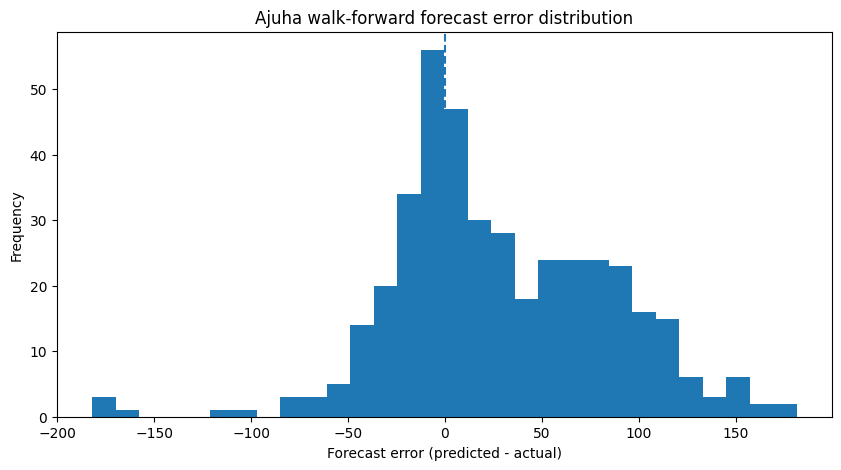


========== SAVED ==========
/content/ajuha_forecast_error_analysis.csv


In [31]:
# ============================================================
# PART 11: FORECAST ERROR DISTRIBUTION + PREDICTION INTERVALS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error


# ============================================================
# 1. LOAD WALK-FORWARD PREDICTIONS
# ============================================================

predictions_path = (
    "/content/global_walk_forward_predictions.csv"
)

wf_predictions = pd.read_csv(
    predictions_path
)

wf_predictions["date"] = pd.to_datetime(
    wf_predictions["date"]
)

print("========== WALK-FORWARD PREDICTIONS ==========")

print(
    "Total prediction rows:",
    len(wf_predictions)
)


# ============================================================
# 2. SELECT AJUHA
# ============================================================

ajuha_wf = wf_predictions[
    (wf_predictions["state"].str.lower() == "uttar pradesh") &
    (wf_predictions["district"].str.lower() == "prayagraj") &
    (wf_predictions["market"].str.lower() == "ajuha")
].copy()

ajuha_wf = (
    ajuha_wf
    .sort_values("date")
    .reset_index(drop=True)
)

print("\n========== AJUHA WALK-FORWARD PREDICTIONS ==========")

print(
    "Prediction rows:",
    len(ajuha_wf)
)

print(
    "Date range:",
    ajuha_wf["date"].min().date(),
    "→",
    ajuha_wf["date"].max().date()
)


# ============================================================
# 3. CALCULATE ERRORS
# ============================================================

ajuha_wf["error"] = (
    ajuha_wf["ridge_prediction"]
    - ajuha_wf["target_7day_avg"]
)

ajuha_wf["absolute_error"] = (
    ajuha_wf["error"].abs()
)

print("\n========== ERROR SUMMARY ==========")

print(
    "MAE:",
    round(
        ajuha_wf["absolute_error"].mean(),
        2
    )
)

print(
    "Mean error (bias):",
    round(
        ajuha_wf["error"].mean(),
        2
    )
)

print(
    "Median error:",
    round(
        ajuha_wf["error"].median(),
        2
    )
)

print(
    "Error standard deviation:",
    round(
        ajuha_wf["error"].std(),
        2
    )
)

print(
    "Minimum error:",
    round(
        ajuha_wf["error"].min(),
        2
    )
)

print(
    "Maximum error:",
    round(
        ajuha_wf["error"].max(),
        2
    )
)


# ============================================================
# 4. EMPIRICAL ERROR QUANTILES
# ============================================================
#
# Instead of assuming a normal distribution, use the observed
# out-of-sample errors directly.
# ============================================================

lower_10 = ajuha_wf["error"].quantile(0.10)
upper_90 = ajuha_wf["error"].quantile(0.90)

lower_05 = ajuha_wf["error"].quantile(0.05)
upper_95 = ajuha_wf["error"].quantile(0.95)

print("\n========== EMPIRICAL ERROR INTERVALS ==========")

print(
    "80% error interval:",
    round(lower_10, 2),
    "to",
    round(upper_90, 2)
)

print(
    "90% error interval:",
    round(lower_05, 2),
    "to",
    round(upper_95, 2)
)


# ============================================================
# 5. CHECK HISTORICAL COVERAGE
# ============================================================

# What percentage of historical out-of-sample actual values
# would have fallen inside each empirical interval?

ajuha_wf["inside_80"] = (
    (ajuha_wf["error"] >= lower_10) &
    (ajuha_wf["error"] <= upper_90)
)

ajuha_wf["inside_90"] = (
    (ajuha_wf["error"] >= lower_05) &
    (ajuha_wf["error"] <= upper_95)
)

coverage_80 = (
    ajuha_wf["inside_80"].mean()
    * 100
)

coverage_90 = (
    ajuha_wf["inside_90"].mean()
    * 100
)

print("\n========== HISTORICAL COVERAGE ==========")

print(
    "80% interval coverage:",
    round(coverage_80, 2),
    "%"
)

print(
    "90% interval coverage:",
    round(coverage_90, 2),
    "%"
)


# ============================================================
# 6. INTERVAL WIDTH
# ============================================================

width_80 = (
    upper_90 - lower_10
)

width_90 = (
    upper_95 - lower_05
)

print("\n========== INTERVAL WIDTH ==========")

print(
    "80% interval width:",
    round(width_80, 2)
)

print(
    "90% interval width:",
    round(width_90, 2)
)


# ============================================================
# 7. EXAMPLE FARMER-FACING INTERVALS
# ============================================================
#
# Apply historical error quantiles to every walk-forward
# prediction to see what the resulting ranges would look like.
# ============================================================

ajuha_wf["lower_80"] = (
    ajuha_wf["ridge_prediction"]
    + lower_10
)

ajuha_wf["upper_80"] = (
    ajuha_wf["ridge_prediction"]
    + upper_90
)

ajuha_wf["lower_90"] = (
    ajuha_wf["ridge_prediction"]
    + lower_05
)

ajuha_wf["upper_90"] = (
    ajuha_wf["ridge_prediction"]
    + upper_95
)

print("\n========== SAMPLE 80% FORECAST RANGES ==========")

display(
    ajuha_wf[
        [
            "date",
            "modal_price",
            "target_7day_avg",
            "ridge_prediction",
            "lower_80",
            "upper_80"
        ]
    ].head(15)
)


# ============================================================
# 8. ERROR DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    ajuha_wf["error"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Ajuha walk-forward forecast error distribution"
)

plt.xlabel(
    "Forecast error (predicted - actual)"
)

plt.ylabel(
    "Frequency"
)

plt.show()


# ============================================================
# 9. SAVE ERROR ANALYSIS
# ============================================================

error_output = (
    "/content/ajuha_forecast_error_analysis.csv"
)

ajuha_wf.to_csv(
    error_output,
    index=False
)

print(
    "\n========== SAVED =========="
)

print(
    error_output
)

In [32]:
# ============================================================
# SIH26033 AI/ML PROGRESS CHECKPOINT
# ============================================================

checkpoint_summary = """
# SIH26033 AI/ML — Forecasting Progress Checkpoint

## Dataset
Raw agricultural mandi dataset:
Agriculture_price_dataset.csv

Potato:
327,332 rows
971 markets

Selected Ajuha series:
Potato / Uttar Pradesh / Prayagraj / Ajuha / Desi / FAQ
728 observations
2023-06-06 to 2025-06-11

## Forecast Target Tested
Next 7-calendar-day average modal price.

## Experiments Completed

### Single-market
- Next-day price prediction
- Next-7-day average prediction
- Price-change prediction
- Trend/momentum features
- Walk-forward validation

### Multi-market
- Market overlap analysis
- Cross-market correlation
- Raw neighboring-market features
- Ridge with neighboring-market features
- Movement-only neighboring-market features

### Classification
- RISE / STABLE / FALL
- Significant movement detection

### Global panel
- 86 eligible market series
- 45 usable series after strict feature/target construction
- Proper date-based train/test split
- Global Ridge
- Global XGBoost
- Date-based walk-forward validation

### Uncertainty
- Ajuha walk-forward error distribution
- Empirical 80% and 90% prediction intervals

## Major Findings

1. Current-price baseline is extremely difficult to beat.
2. Single Ajuha models look better on some 80/20 splits but fail walk-forward validation.
3. Raw neighboring-market prices do not provide a useful robust improvement.
4. Neighboring-market movement features also do not beat the baseline robustly.
5. 3-class direction classification is weak.
6. Significant-movement detection has high recall but poor overall discrimination.
7. Global Ridge improves on one holdout:
   Global MAE = 30.83 vs baseline = 33.07
   Ajuha MAE = 23.43 vs baseline = 26.50
8. However, global Ridge fails date-based walk-forward validation:
   Global Ridge MAE = 55.51
   Global baseline MAE = 43.29
   Ajuha Ridge MAE = 46.80
   Ajuha baseline MAE = 36.66
9. Global XGBoost also fails:
   Global MAE = 50.71
   Global baseline MAE = 33.07
   Ajuha MAE = 42.60
   Ajuha baseline = 26.50
10. Ajuha Ridge errors show positive bias:
    Mean error = +28.47
11. Empirical intervals are well calibrated historically:
    80% coverage ≈ 79.95%
    90% coverage ≈ 89.73%
12. The main unresolved issue is changing price regimes / sudden movements.

## Current Direction

Do NOT continue blindly tuning regression models.

Next stage should focus on:
- calibrated decision support
- uncertainty/range forecasting
- potentially additional trusted external features
- final farmer-facing prediction design

## Current GitHub Branch
ai-ml-price-prediction
"""

with open(
    "/content/SIH26033_AI_ML_PROGRESS_CHECKPOINT.md",
    "w"
) as f:
    f.write(checkpoint_summary)

print(
    "Checkpoint saved:"
)
print(
    "/content/SIH26033_AI_ML_PROGRESS_CHECKPOINT.md"
)

Checkpoint saved:
/content/SIH26033_AI_ML_PROGRESS_CHECKPOINT.md
